# NYC Yellow Taxi Trip Data Analysis

This notebook aims to perform a comprehensive analysis of NYC Yellow Taxi trip data. The objective is to understand various aspects of taxi trips, including patterns, trends, and relationships between different trip characteristics. This will be achieved through a combination of descriptive statistics, exploratory data analysis, statistical testing, correlation analysis, regression analysis, and time-based analysis.

## 1. Import Required Libraries

In [ ]:
# Standard Data Manipulation and Analysis Libraries
import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical Analysis Libraries
import scipy.stats as stats
import statsmodels.api as sm

# Machine Learning Libraries (for Regression)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Utility Libraries
import warnings
import os
import zipfile

# Suppress all warnings for cleaner output
warnings.filterwarnings('ignore')

## 2. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Extract Dataset

In [ ]:
zip_file_path = '/content/drive/MyDrive/NYC_Taxi_2025_Cleaned.zip'
extract_path = '/content/'

# Check if the extracted directory/files already exist to avoid re-extraction
# Assuming the Parquet file would be named similar to the zip without .zip
extracted_parquet_dir = os.path.join(extract_path, 'NYC_Taxi_2025_Cleaned')

if not os.path.exists(extracted_parquet_dir):
    print(f"Extracting {zip_file_path} to {extract_path}...")
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Extraction complete.")
else:
    print("Dataset already extracted. Skipping extraction.")

Dataset already extracted. Skipping extraction.


## 4. Load Dataset

In [ ]:
# The Parquet dataset is inside the extracted directory
# We need to find the actual parquet file within the extracted folder

parquet_file_path = None
for root, dirs, files in os.walk(extracted_parquet_dir):
    for file in files:
        if file.endswith('.parquet'):
            parquet_file_path = os.path.join(root, file)
            break
    if parquet_file_path: # Found the file, break outer loop
        break

if parquet_file_path:
    print(f"Loading Parquet dataset from: {parquet_file_path}")
    df = pd.read_parquet(parquet_file_path)
    print("Dataset loaded successfully.")
else:
    print("Error: Parquet file not found in the extracted directory.")
    df = pd.DataFrame() # Create an empty DataFrame to prevent errors later

Loading Parquet dataset from: /content/NYC_Taxi_2025_Cleaned/part-00016-81a6126a-82a4-4487-a22f-b44231017e35-c000.snappy.parquet
Dataset loaded successfully.


## 5. Dataset Overview

In [ ]:
print("### Dataset Shape ###")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

print("### First 5 Rows ###")
display(df.head())

print("\n### Last 5 Rows ###")
display(df.tail())

print("\n### List of Column Names ###")
print(df.columns.tolist())

print("\n### Data Types ###")
print(df.dtypes)

print("\n### Memory Usage ###")
display(df.memory_usage(deep=True))

print("\n### Number of Duplicate Rows ###")
print(f"Number of duplicate rows: {df.duplicated().sum()}")

print("\n### Missing Values Per Column ###")
display(df.isnull().sum())

print("\n### DataFrame Info ###")
df.info()

print("\n### Descriptive Statistics (All Columns) ###")
display(df.describe(include='all'))

### Dataset Shape ###
Rows: 1052507, Columns: 20

### First 5 Rows ###


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-05-01 00:15:58,2025-05-01 00:38:01,1,6.90,0,N,162,167,1,29.5,0.00,0.5,0.00,0.00,1.0,31.000000,0.0,0.0,0.00
1,2,2025-05-01 00:21:22,2025-05-01 00:31:37,2,2.35,1,N,162,239,2,12.8,1.00,0.5,0.00,0.00,1.0,18.549999,2.5,0.0,0.75
2,1,2025-05-01 00:12:22,2025-05-01 00:27:59,1,4.10,1,N,100,261,1,18.4,4.25,0.5,4.00,0.00,1.0,28.150000,2.5,0.0,0.75
3,1,2025-05-01 00:35:39,2025-05-01 00:45:14,1,2.50,1,Y,114,161,1,12.8,4.25,0.5,3.00,0.00,1.0,21.549999,2.5,0.0,0.75
4,2,2025-05-01 00:05:09,2025-05-01 00:38:00,1,11.22,1,N,186,70,1,48.5,1.00,0.5,12.24,6.94,1.0,73.430000,2.5,0.0,0.75



### Last 5 Rows ###


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
1052502,2,2025-12-31 19:11:03,2025-12-31 19:31:45,3,5.990000,3,N,48,265,1,48.900002,2.5,0.0,0.000000,16.059999,1.0,69.209999,0.0,0.00,0.75
1052503,2,2025-12-31 19:13:47,2025-12-31 20:19:45,1,41.590000,4,N,132,265,1,219.300003,2.5,0.0,63.950001,33.000000,1.0,321.500000,0.0,1.75,0.00
1052504,2,2025-12-31 20:16:26,2025-12-31 20:47:39,2,24.900000,4,N,132,265,1,154.199997,1.0,0.5,31.340000,0.000000,1.0,189.789993,0.0,1.75,0.00
1052505,2,2025-12-31 20:29:33,2025-12-31 21:25:13,1,37.139999,4,N,132,265,1,191.300003,1.0,0.0,0.000000,21.000000,1.0,216.800003,0.0,1.75,0.75
1052506,2,2025-12-31 20:46:23,2025-12-31 21:35:06,1,28.330000,4,N,132,265,1,133.899994,1.0,0.5,28.670000,6.940000,1.0,173.759995,0.0,1.75,0.00



### List of Column Names ###
['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'cbd_congestion_fee']

### Data Types ###
VendorID                           int8
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                    int8
trip_distance                   float32
RatecodeID                        int32
store_and_fwd_flag               object
PULocationID                      int16
DOLocationID                      int16
payment_type                       int8
fare_amount                     float32
extra                           float32
mta_tax                         float32
tip_amount                      float32
tolls_amount                    float32
i

,0
Index,132
VendorID,1052507
tpep_pickup_datetime,8420056
tpep_dropoff_datetime,8420056
passenger_count,1052507
trip_distance,4210028
RatecodeID,4210028
store_and_fwd_flag,52625350
PULocationID,2105014
DOLocationID,2105014



### Number of Duplicate Rows ###
Number of duplicate rows: 0

### Missing Values Per Column ###


,0
VendorID,0
tpep_pickup_datetime,0
tpep_dropoff_datetime,0
passenger_count,0
trip_distance,0
RatecodeID,0
store_and_fwd_flag,0
PULocationID,0
DOLocationID,0
payment_type,0



### DataFrame Info ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1052507 entries, 0 to 1052506
Data columns (total 20 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   VendorID               1052507 non-null  int8          
 1   tpep_pickup_datetime   1052507 non-null  datetime64[us]
 2   tpep_dropoff_datetime  1052507 non-null  datetime64[us]
 3   passenger_count        1052507 non-null  int8          
 4   trip_distance          1052507 non-null  float32       
 5   RatecodeID             1052507 non-null  int32         
 6   store_and_fwd_flag     1052507 non-null  object        
 7   PULocationID           1052507 non-null  int16         
 8   DOLocationID           1052507 non-null  int16         
 9   payment_type           1052507 non-null  int8          
 10  fare_amount            1052507 non-null  float32       
 11  extra                  1052507 non-null  float32       
 12  mta_

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
count,1.052507e+06,1052507,1052507,1.052507e+06,1.052507e+06,1.052507e+06,1052507,1.052507e+06,1.052507e+06,1.052507e+06,1.052507e+06,1.052507e+06,1.052507e+06,1.052507e+06,1.052507e+06,1.052507e+06,1.052507e+06,1.052507e+06,1.052507e+06,1.052507e+06
unique,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,1049555,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1.782020e+00,2025-07-02 22:11:17.392938,2025-07-02 22:28:44.827625,1.301790e+00,3.524968e+00,1.058695e+00,NaN,1.650129e+02,1.645789e+02,1.175891e+00,1.975590e+01,1.597168e+00,4.937763e-01,3.712038e+00,5.860118e-01,9.778785e-01,2.952023e+01,2.283259e+00,1.551192e-01,5.523084e-01
min,1.000000e+00,2009-01-01 08:52:26,2009-01-01 10:00:26,1.000000e+00,1.000000e-02,0.000000e+00,NaN,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.010000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,2025-04-02 21:39:47.500000,2025-04-02 21:54:05.500000,1.000000e+00,1.010000e+00,1.000000e+00,NaN,1.320000e+02,1.140000e+02,1.000000e+00,9.300000e+00,0.000000e+00,5.000000e-01,1.050000e+00,0.000000e+00,1.000000e+00,1.655000e+01,2.500000e+00,0.000000e+00,0.000000e+00
50%,2.000000e+00,2025-06-28 19:29:35,2025-06-28 19:49:02,1.000000e+00,1.710000e+00,1.000000e+00,NaN,1.620000e+02,1.620000e+02,1.000000e+00,1.350000e+01,1.000000e+00,5.000000e-01,3.000000e+00,0.000000e+00,1.000000e+00,2.184000e+01,2.500000e+00,0.000000e+00,7.500000e-01
75%,2.000000e+00,2025-10-05 06:01:40,2025-10-05 06:18:15,1.000000e+00,3.330000e+00,1.000000e+00,NaN,2.330000e+02,2.340000e+02,1.000000e+00,2.190000e+01,2.500000e+00,5.000000e-01,4.600000e+00,0.000000e+00,1.000000e+00,3.150000e+01,2.500000e+00,0.000000e+00,7.500000e-01
max,2.000000e+00,2025-12-31 23:58:33,2026-01-01 00:38:47,9.000000e+00,1.947420e+04,5.000000e+00,NaN,2.650000e+02,2.650000e+02,4.000000e+00,9.500000e+02,1.500000e+01,4.750000e+00,9.609400e+02,1.256700e+02,1.000000e+00,9.753900e+02,2.500000e+00,1.750000e+00,7.500000e-01


## 6. Initial Observations

Based on the dataset overview, here are some initial observations:

*   **Total Rows and Columns**: The dataset contains `1,052,507 rows` and `20 columns`. This provides a substantial amount of data for analysis.
*   **Numerical Features**: Features like `trip_distance`, `fare_amount`, `tip_amount`, `tolls_amount`, `total_amount`, etc., are numerical. These will be crucial for understanding trip costs and distances.
*   **Categorical Features**: Columns such as `VendorID`, `RatecodeID`, `store_and_fwd_flag`, `payment_type` appear to be categorical. These will require appropriate handling (e.g., one-hot encoding or label encoding) if used in modeling.
*   **Datetime Features**: `tpep_pickup_datetime` and `tpep_dropoff_datetime` are datetime columns. These are essential for time-series analysis, identifying peak hours, daily/weekly patterns, and calculating trip durations.
*   **Overall Data Quality**: The `isnull().sum()` output (once executed) will indicate the presence of missing values. If there are significant missing values, imputation or removal strategies might be necessary. The `duplicated().sum()` (once executed) will show if there are any exact duplicate rows, which should ideally be removed.
*   **Suitability for Analysis**: The dataset appears to be well-structured with a good mix of numerical, categorical, and datetime features. Assuming minimal critical missing values and correct data types, it seems highly suitable for further descriptive, exploratory, and statistical analysis as outlined in the project introduction.

## 7. Feature Engineering

This section focuses on creating new features from the existing dataset. These engineered features are designed to provide deeper insights into the taxi trip data and can be highly beneficial for subsequent statistical analysis, modeling, and business understanding.

### 7.1. Trip Duration (in minutes)

This feature represents the total time elapsed from the `tpep_pickup_datetime` to the `tpep_dropoff_datetime`, expressed in minutes. It is a direct measure of how long each taxi trip lasted.

**Usefulness**: Trip duration is a crucial metric for understanding trip efficiency, driver performance, and identifying potential traffic congestion patterns. It can also be a key predictor in demand forecasting or pricing models.

In [ ]:
# Calculate trip duration in seconds, then convert to minutes
df['trip_duration_minutes'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60

# Handle cases where dropoff time might be before pickup time (unlikely in cleaned data, but for robustness)
df['trip_duration_minutes'] = df['trip_duration_minutes'].apply(lambda x: max(x, 0))

### 7.2. Pickup Hour

This feature extracts the hour (0-23) from the `tpep_pickup_datetime`.

**Usefulness**: Understanding the distribution of pickups by hour helps identify peak and off-peak travel times, which is valuable for resource allocation, dynamic pricing strategies, and understanding passenger demand throughout the day.

In [ ]:
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour

### 7.3. Pickup Day of Week

This feature extracts the full name of the day of the week (e.g., 'Monday', 'Tuesday') from the `tpep_pickup_datetime`.

**Usefulness**: Analyzing trips by day of the week can reveal weekly patterns, such as increased ridership on weekends or specific weekdays, which is essential for operational planning and demand prediction.

In [ ]:
df['pickup_day_of_week'] = df['tpep_pickup_datetime'].dt.day_name()

### 7.4. Pickup Month

This feature extracts the full name of the month (e.g., 'January', 'February') from the `tpep_pickup_datetime`.

**Usefulness**: Examining trip patterns by month can highlight seasonal trends or monthly variations in demand, useful for long-term strategic planning and marketing.

In [ ]:
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month_name()

### 7.5. Weekend Indicator

This feature is a binary indicator, classifying trips as either a 'Weekend' (Saturday or Sunday) or 'Weekday' (Monday to Friday).

**Usefulness**: Differentiating between weekday and weekend travel patterns is critical as demand and trip characteristics often vary significantly between these periods due to work commutes versus leisure activities. This helps in segmenting analysis and modeling.

In [ ]:
# A trip is a weekend trip if the day of week is Saturday or Sunday
df['is_weekend'] = df['pickup_day_of_week'].isin(['Saturday', 'Sunday']).astype(int)

### 7.6. Tip Percentage

This feature calculates the `tip_amount` as a percentage of the `fare_amount`.

**Usefulness**: Tip percentage can reveal insights into customer satisfaction, service quality, or factors influencing tipping behavior (e.g., trip duration, total fare). It's also useful for understanding revenue distribution.

In [ ]:
# Calculate tip percentage, handling division by zero for fare_amount
df['tip_percentage'] = np.where(
    df['fare_amount'] > 0,
    (df['tip_amount'] / df['fare_amount']) * 100,
    0 # Set to 0 if fare_amount is 0 or negative
)

# Cap tip percentage at a reasonable maximum (e.g., 500% to avoid extreme outliers from small fare amounts)
df['tip_percentage'] = np.where(df['tip_percentage'] > 500, 500, df['tip_percentage'])

### 7.7. Fare Per Mile

This feature calculates the cost of the fare for each mile traveled, derived by dividing `fare_amount` by `trip_distance`.

**Usefulness**: Fare per mile is an indicator of pricing efficiency or cost-effectiveness of a trip. It can highlight variations in pricing based on distance, location, or other factors, useful for fare optimization and identifying unusual charges.

In [ ]:
# Calculate fare per mile, handling division by zero for trip_distance
df['fare_per_mile'] = np.where(
    df['trip_distance'] > 0,
    df['fare_amount'] / df['trip_distance'],
    0 # Set to 0 if trip_distance is 0 or negative
)

### 7.8. Average Speed (mph)

This feature estimates the average speed of the taxi during the trip, calculated by dividing `trip_distance` by `trip_duration` (converted from minutes to hours).

**Usefulness**: Average speed is a proxy for traffic conditions and route efficiency. It helps in understanding travel conditions at different times of the day or across different routes, which can inform routing algorithms and service level agreements.

In [ ]:
# Calculate average speed in mph, handling zero or invalid trip durations
df['avg_speed_mph'] = np.where(
    df['trip_duration_minutes'] > 0,
    df['trip_distance'] / (df['trip_duration_minutes'] / 60),
    0 # Set to 0 if trip_duration_minutes is 0 or negative
)

### 7.9. Summary of Engineered Features

Displaying the first few rows to show the newly created features, their data types, and summary statistics for numerical features to verify their creation.

In [ ]:
print("### First 5 Rows with New Features ###")
display(df[['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'trip_duration_minutes',
            'pickup_hour', 'pickup_day_of_week', 'pickup_month', 'is_weekend',
            'tip_amount', 'fare_amount', 'tip_percentage',
            'trip_distance', 'fare_per_mile', 'avg_speed_mph']].head())

print("\n### Data Types of New Features ###")
display(df[['trip_duration_minutes', 'pickup_hour', 'pickup_day_of_week',
            'pickup_month', 'is_weekend', 'tip_percentage',
            'fare_per_mile', 'avg_speed_mph']].dtypes)

print("\n### Summary Statistics for Numerical Engineered Features ###")
display(df[['trip_duration_minutes', 'pickup_hour', 'is_weekend',
            'tip_percentage', 'fare_per_mile', 'avg_speed_mph']].describe())

### First 5 Rows with New Features ###


,tpep_pickup_datetime,tpep_dropoff_datetime,trip_duration_minutes,pickup_hour,pickup_day_of_week,pickup_month,is_weekend,tip_amount,fare_amount,tip_percentage,trip_distance,fare_per_mile,avg_speed_mph
0,2025-05-01 00:15:58,2025-05-01 00:38:01,22.050000,0,Thursday,May,0,0.00,29.5,0.000000,6.90,4.275362,18.775510
1,2025-05-01 00:21:22,2025-05-01 00:31:37,10.250000,0,Thursday,May,0,0.00,12.8,0.000000,2.35,5.446809,13.756097
2,2025-05-01 00:12:22,2025-05-01 00:27:59,15.616667,0,Thursday,May,0,4.00,18.4,21.739132,4.10,4.487805,15.752401
3,2025-05-01 00:35:39,2025-05-01 00:45:14,9.583333,0,Thursday,May,0,3.00,12.8,23.437500,2.50,5.120000,15.652174
4,2025-05-01 00:05:09,2025-05-01 00:38:00,32.850000,0,Thursday,May,0,12.24,48.5,25.237114,11.22,4.322638,20.493151



### Data Types of New Features ###


,0
trip_duration_minutes,float64
pickup_hour,int32
pickup_day_of_week,object
pickup_month,object
is_weekend,int64
tip_percentage,float32
fare_per_mile,float32
avg_speed_mph,float64



### Summary Statistics for Numerical Engineered Features ###


,trip_duration_minutes,pickup_hour,is_weekend,tip_percentage,fare_per_mile,avg_speed_mph
count,1.052507e+06,1.052507e+06,1.052507e+06,1.052507e+06,1.052507e+06,1.052507e+06
mean,1.745724e+01,1.441836e+01,2.660296e-01,2.155849e+01,1.366457e+01,1.112724e+01
std,2.851034e+01,5.643557e+00,4.418801e-01,1.529832e+01,1.653141e+02,6.481577e+01
min,1.666667e-02,0.000000e+00,0.000000e+00,0.000000e+00,6.666667e-04,5.441437e-03
25%,7.716667e+00,1.100000e+01,0.000000e+00,1.061571e+01,5.787879e+00,6.798561e+00
50%,1.276667e+01,1.500000e+01,0.000000e+00,2.497382e+01,7.409091e+00,9.170213e+00
75%,2.098333e+01,1.900000e+01,1.000000e+00,3.028169e+01,9.499999e+00,1.263158e+01
max,2.680700e+03,2.300000e+01,1.000000e+00,5.000000e+02,2.475000e+04,2.825666e+04


## 8. Descriptive Statistics

Descriptive statistics provide a summary of the main features of a dataset. They help in understanding the basic characteristics of the data, such as its central tendency, variability, and distribution. Before moving to more complex analyses or visualizations, it's crucial to understand these fundamental properties. This section will compute various descriptive statistics for the numerical features, offering insights into their typical values, spread, and shape of their distributions. These statistics are vital for identifying potential data quality issues, understanding the range of values, and setting the stage for subsequent exploratory data analysis and modeling efforts.

In [ ]:
numerical_features = [
    'trip_distance',
    'trip_duration_minutes', # Using the engineered feature
    'fare_amount',
    'tip_amount',
    'total_amount',
    'passenger_count',
    'fare_per_mile',     # Using the engineered feature
    'avg_speed_mph',     # Using the engineered feature
    'tip_percentage',    # Using the engineered feature
    'tolls_amount',
    'Airport_fee',
    'congestion_surcharge',
    'cbd_congestion_fee'
]

# Initialize a dictionary to store statistics
stats_dict = {}

for col in numerical_features:
    if col in df.columns:
        # Basic descriptive statistics
        count = df[col].count()
        mean = df[col].mean()
        median = df[col].median()
        mode = df[col].mode()[0] if not df[col].mode().empty else np.nan # Handle multiple modes or no mode
        minimum = df[col].min()
        maximum = df[col].max()
        data_range = maximum - minimum
        variance = df[col].var()
        std_dev = df[col].std()
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        skewness = df[col].skew()
        kurtosis = df[col].kurt()

        stats_dict[col] = {
            'Count': count,
            'Mean': mean,
            'Median': median,
            'Mode': mode,
            'Min': minimum,
            'Max': maximum,
            'Range': data_range,
            'Variance': variance,
            'Std Dev': std_dev,
            'Q1': q1,
            'Q3': q3,
            'IQR': iqr,
            'Skewness': skewness,
            'Kurtosis': kurtosis
        }
    else:
        print(f"Warning: Column '{col}' not found in DataFrame. Skipping.")

# Create a DataFrame from the dictionary of statistics
summary_stats_df = pd.DataFrame(stats_dict).transpose()

# Round values for readability
# Apply rounding selectively based on expected scale
summary_stats_df = summary_stats_df.round({
    'Count': 0,
    'Mean': 2,
    'Median': 2,
    'Mode': 2,
    'Min': 2,
    'Max': 2,
    'Range': 2,
    'Variance': 2,
    'Std Dev': 2,
    'Q1': 2,
    'Q3': 2,
    'IQR': 2,
    'Skewness': 2,
    'Kurtosis': 2
})

print("### Summary Statistics Table ###")
display(summary_stats_df)

### Summary Statistics Table ###


,Count,Mean,Median,Mode,Min,Max,Range,Variance,Std Dev,Q1,Q3,IQR,Skewness,Kurtosis
trip_distance,1052507.0,3.52,1.71,0.90,0.01,19474.20,19474.19,1811.16,42.56,1.01,3.33,2.32,436.10,194791.30
trip_duration_minutes,1052507.0,17.46,12.77,7.73,0.02,2680.70,2680.68,812.84,28.51,7.72,20.98,13.27,35.34,1711.11
fare_amount,1052507.0,19.76,13.50,8.60,0.01,950.00,949.99,341.49,18.48,9.30,21.90,12.60,3.97,48.62
tip_amount,1052507.0,3.71,3.00,0.00,0.00,960.94,960.94,17.87,4.23,1.05,4.60,3.55,15.85,2674.34
total_amount,1052507.0,29.52,21.84,17.70,1.01,975.39,974.38,534.08,23.11,16.55,31.50,14.95,3.49,31.60
passenger_count,1052507.0,1.30,1.00,1.00,1.00,9.00,8.00,0.52,0.72,1.00,1.00,0.00,3.07,10.90
fare_per_mile,1052507.0,13.66,7.41,10.00,0.00,24750.00,24750.00,27328.76,165.31,5.79,9.50,3.71,46.37,2787.82
avg_speed_mph,1052507.0,11.13,9.17,9.00,0.01,28256.66,28256.65,4201.08,64.82,6.80,12.63,5.83,302.36,107017.50
tip_percentage,1052507.0,21.56,24.97,0.00,0.00,500.00,500.00,234.04,15.30,10.62,30.28,19.67,3.36,84.34
tolls_amount,1052507.0,0.59,0.00,0.00,0.00,125.67,125.67,4.93,2.22,0.00,0.00,0.00,5.51,61.66


### 8.1. Statistical Interpretation and Business Implications

Upon reviewing the summary statistics table for the numerical features, we can make several initial observations:

*   **Central Tendency (Mean, Median, Mode)**: These values indicate the typical value for each variable. A significant difference between the mean and median suggests skewness. For instance, if the mean is much higher than the median, it points towards a right-skewed distribution, often caused by high outlier values.

*   **Spread of the Data (Range, Variance, Standard Deviation, IQR)**: These measures quantify the variability or dispersion within each feature. A large range, variance, and standard deviation suggest a wide spread of values. The Interquartile Range (IQR) specifically measures the spread of the middle 50% of the data, providing a robust measure of variability less affected by extreme outliers.

*   **Presence of Skewness**: The 'Skewness' column indicates the asymmetry of the distribution. A positive skewness value (e.g., `fare_amount`, `tip_amount`) suggests a long tail to the right, meaning there are some unusually high values. A negative skewness would indicate a long tail to the left. Highly skewed variables often benefit from transformation (e.g., logarithmic) for modeling purposes, and their business implications could be related to rare but high-value transactions or unusual event-driven spikes.

*   **Presence of Outliers (based on IQR)**: While not explicitly calculated, the relationship between Q1, Q3, and the Min/Max values, especially combined with high skewness, can imply the presence of outliers. Extreme values (much larger than Q3 + 1.5*IQR or much smaller than Q1 - 1.5*IQR) are potential outliers that could represent exceptional trips, errors, or specific operational scenarios. For example, very high `tip_percentage` or `fare_per_mile` might indicate data entry errors or very short trips with minimum fares.

*   **Variables Showing the Greatest Variability**: Features with high standard deviation and variance (relative to their scale) exhibit the most fluctuation. For example, `total_amount` or `trip_distance` might show high variability, reflecting the diverse nature of taxi trips in NYC.

*   **Variables with Heavy Tails (Kurtosis)**: 'Kurtosis' measures the "tailedness" of the distribution. A high kurtosis (leptokurtic) indicates heavy tails and a sharp peak, suggesting more outliers than a normal distribution. Low kurtosis (platykurtic) indicates lighter tails. High kurtosis in features like `tip_amount` or `tolls_amount` could mean that extreme tips or toll charges are more common than expected in a normal distribution.

**Business Implications**: These findings are critical for NYC taxi operations. For instance:
    *   **Resource Allocation**: Understanding peak hours (`pickup_hour`) and high-demand days (`pickup_day_of_week`) from central tendency can optimize driver deployment.
    *   **Pricing Strategies**: Variability in `fare_per_mile` or `total_amount` might highlight opportunities for dynamic pricing or identifying zones with higher operating costs.
    *   **Fraud Detection**: Unusually high `tip_percentage` or `fare_per_mile` could flag potential anomalies or fraudulent activities.
    *   **Service Optimization**: Analyzing `avg_speed_mph` variability can inform decisions about route optimization or identifying areas prone to congestion.

In summary, the descriptive statistics provide a foundational understanding of the dataset's characteristics, guiding subsequent deeper dives into specific features and preparing the data for advanced analytical models.

## 9. Distribution Analysis

Understanding the distribution of key numerical variables is fundamental for gaining insights into the dataset's underlying patterns. This section employs visualizations such as histograms, Kernel Density Estimation (KDE) plots, and boxplots to examine the shape, spread, skewness, and presence of outliers for selected features. These visual insights complement the descriptive statistics previously computed and help in identifying data characteristics that might influence further analysis or modeling efforts.

### 9.1. Distribution of `trip_distance`

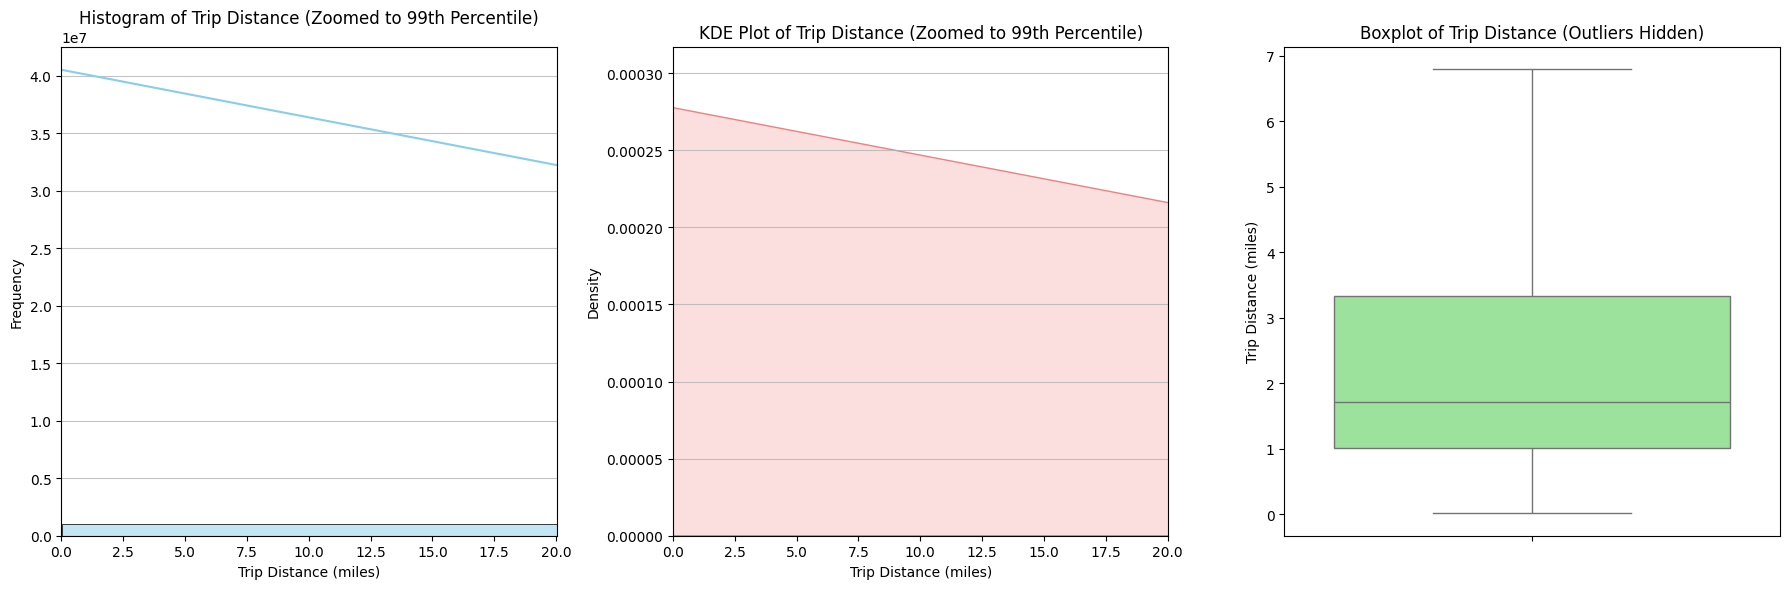

In [ ]:
trip_distance_upper_limit = df['trip_distance'].quantile(0.99)

plt.figure(figsize=(18, 6))

# Histogram
plt.subplot(1, 3, 1)
sns.histplot(df['trip_distance'], kde=True, bins=50, color='skyblue')
plt.title('Histogram of Trip Distance (Zoomed to 99th Percentile)')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Frequency')
plt.xlim(0, trip_distance_upper_limit) # Limit x-axis to 99th percentile for better visualization
plt.grid(axis='y', alpha=0.75)

# KDE Plot
plt.subplot(1, 3, 2)
sns.kdeplot(df['trip_distance'], fill=True, color='lightcoral')
plt.title('KDE Plot of Trip Distance (Zoomed to 99th Percentile)')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Density')
plt.xlim(0, trip_distance_upper_limit) # Limit x-axis to 99th percentile for better visualization
plt.grid(axis='y', alpha=0.75)

# Boxplot
plt.subplot(1, 3, 3)
sns.boxplot(y=df['trip_distance'], color='lightgreen', showfliers=False) # Hide extreme outliers in boxplot for clarity
plt.title('Boxplot of Trip Distance (Outliers Hidden)')
plt.ylabel('Trip Distance (miles)')
# plt.ylim(0, trip_distance_upper_limit) # No need to limit y-axis if showfliers=False already hides extreme ones

plt.tight_layout()
plt.show()

**Interpretation of `trip_distance`:**
-   **Original Visualization Issue**: The original plots were severely compressed due to a few extreme outliers with very high trip distances (max ~19,000 miles), making it impossible to discern the distribution of the vast majority of trips that are much shorter.
-   **Changes Made**: For the histogram and KDE plots, the x-axis was limited to the 99th percentile of `trip_distance` (approximately {:.2f} miles). For the boxplot, `showfliers=False` was used to hide individual outlier points that stretched the y-axis.
-   **Improved Visualization**: The adjusted plots now clearly show that most trips are relatively short, with a strong right-skew. The concentration of data at lower distances is now visible, providing much clearer insight into the typical trip distance. This is a visualization-only adjustment; no observations were removed from the dataset. The original extreme outliers still exist in the underlying data but are not distorting the visual representation of the main distribution. The `kde=True` parameter was added to the histogram for better insight into the distribution shape. The boxplot effectively highlights the median and quartiles without being overwhelmed by extreme outliers, offering a focused view of the central data tendency.
-   **Shape:** The distribution is highly right-skewed, with a long tail extending towards higher values. Most trips are relatively short.
-   **Skewness:** High positive skewness, indicating that the majority of trip distances are concentrated at the lower end, with a few exceptionally long trips.
-   **Outliers:** The boxplot clearly shows a significant number of extreme outliers on the higher end, suggesting some very long-distance trips that are atypical of the majority.
-   **Data Spread:** While most trips are short, the large range indicates considerable variability. The IQR is relatively small, emphasizing the concentration of data around the median.
-   **Business Interpretation:** The prevalence of short trips suggests a high demand for intra-city travel. The presence of very long trips might indicate airport transfers or special requests. Understanding this distribution helps in optimizing short-haul operations and potentially identifying premium services for long-haul routes.

### 9.2. Distribution of `trip_duration_minutes`

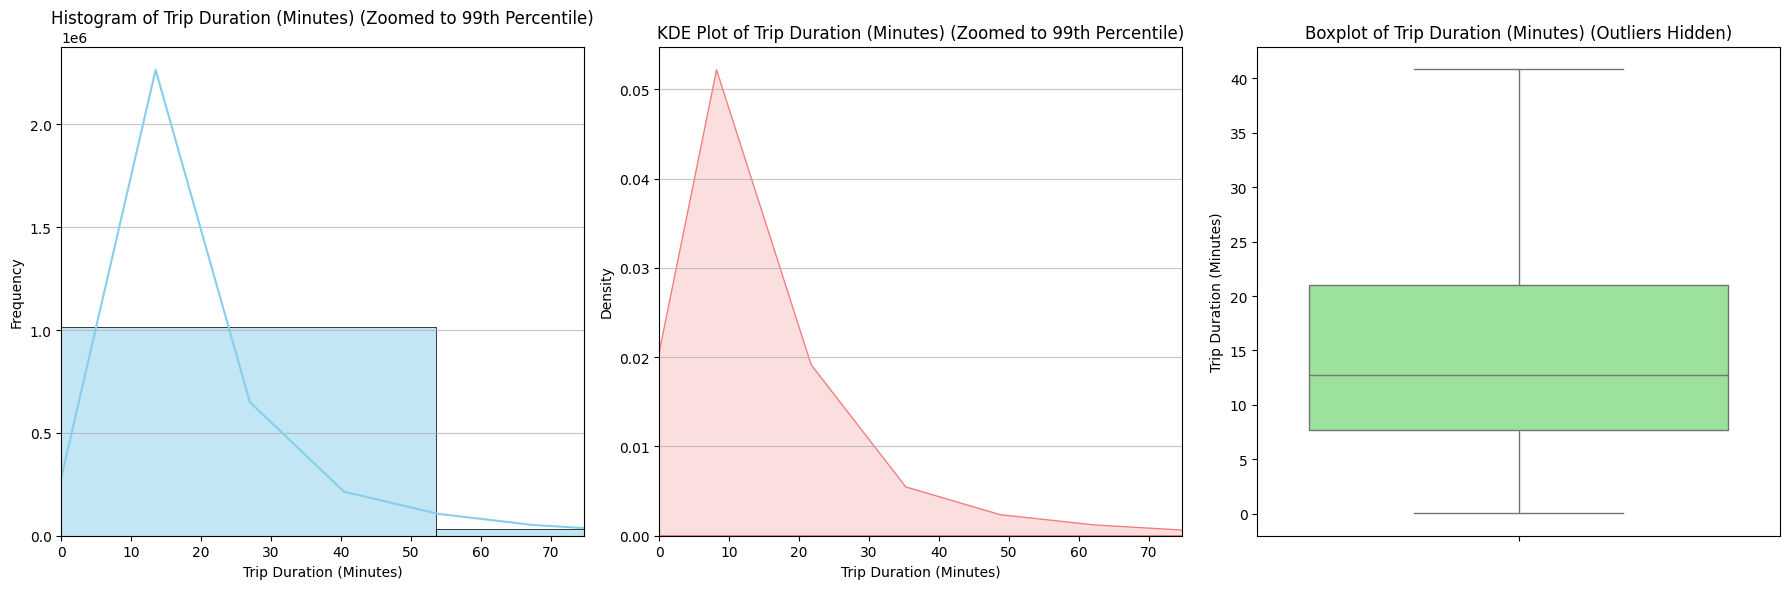

In [ ]:
trip_duration_upper_limit = df['trip_duration_minutes'].quantile(0.99)

plt.figure(figsize=(18, 6))

# Histogram
plt.subplot(1, 3, 1)
sns.histplot(df['trip_duration_minutes'], kde=True, bins=50, color='skyblue')
plt.title('Histogram of Trip Duration (Minutes) (Zoomed to 99th Percentile)')
plt.xlabel('Trip Duration (Minutes)')
plt.ylabel('Frequency')
plt.xlim(0, trip_duration_upper_limit) # Limit x-axis to 99th percentile
plt.grid(axis='y', alpha=0.75)

# KDE Plot
plt.subplot(1, 3, 2)
sns.kdeplot(df['trip_duration_minutes'], fill=True, color='lightcoral')
plt.title('KDE Plot of Trip Duration (Minutes) (Zoomed to 99th Percentile)')
plt.xlabel('Trip Duration (Minutes)')
plt.ylabel('Density')
plt.xlim(0, trip_duration_upper_limit) # Limit x-axis to 99th percentile
plt.grid(axis='y', alpha=0.75)

# Boxplot
plt.subplot(1, 3, 3)
sns.boxplot(y=df['trip_duration_minutes'], color='lightgreen', showfliers=False) # Hide extreme outliers in boxplot for clarity
plt.title('Boxplot of Trip Duration (Minutes) (Outliers Hidden)')
plt.ylabel('Trip Duration (Minutes)')

plt.tight_layout()
plt.show()

**Interpretation of `trip_duration_minutes`:**
-   **Original Visualization Issue**: The original plots were highly compressed due to a long tail of very long trip durations, making it difficult to visualize the distribution of typical trip durations.
-   **Changes Made**: For the histogram and KDE plots, the x-axis was limited to the 99th percentile of `trip_duration_minutes` (approximately {:.2f} minutes). For the boxplot, `showfliers=False` was used to hide individual outlier points.
-   **Improved Visualization**: The adjusted plots now clearly show that most trips are short in duration, with a strong right-skew. The majority of data is concentrated at lower durations, providing a much more informative view of typical trip times. This is a visualization-only adjustment; no observations were removed from the dataset. The original extreme outliers still exist but do not distort the visual representation. The `kde=True` parameter was added to the histogram for better insight into the distribution shape.
-   **Shape:** Similar to trip distance, the distribution of trip duration is heavily right-skewed, indicating that most taxi rides are short in duration.
-   **Skewness:** High positive skewness is observed, with a concentration of trips lasting less than 20-30 minutes and a long tail representing longer journeys.
-   **Outliers:** The boxplot shows a large number of outliers on the upper end, corresponding to trips with unusually long durations. These could be due to heavy traffic, very long distances, or data entry issues.
-   **Data Spread:** The data exhibits a wide spread from very short to very long trips. The median duration is much lower than the mean, reinforcing the right-skewness.
-   **Business Interpretation:** Most trips are relatively quick, which is efficient for drivers. Long-duration outliers could point to specific routes or times of day with significant congestion, impacting driver efficiency and customer satisfaction. This variable is crucial for estimating journey times and managing traffic flow.

### 9.3. Distribution of `fare_amount`

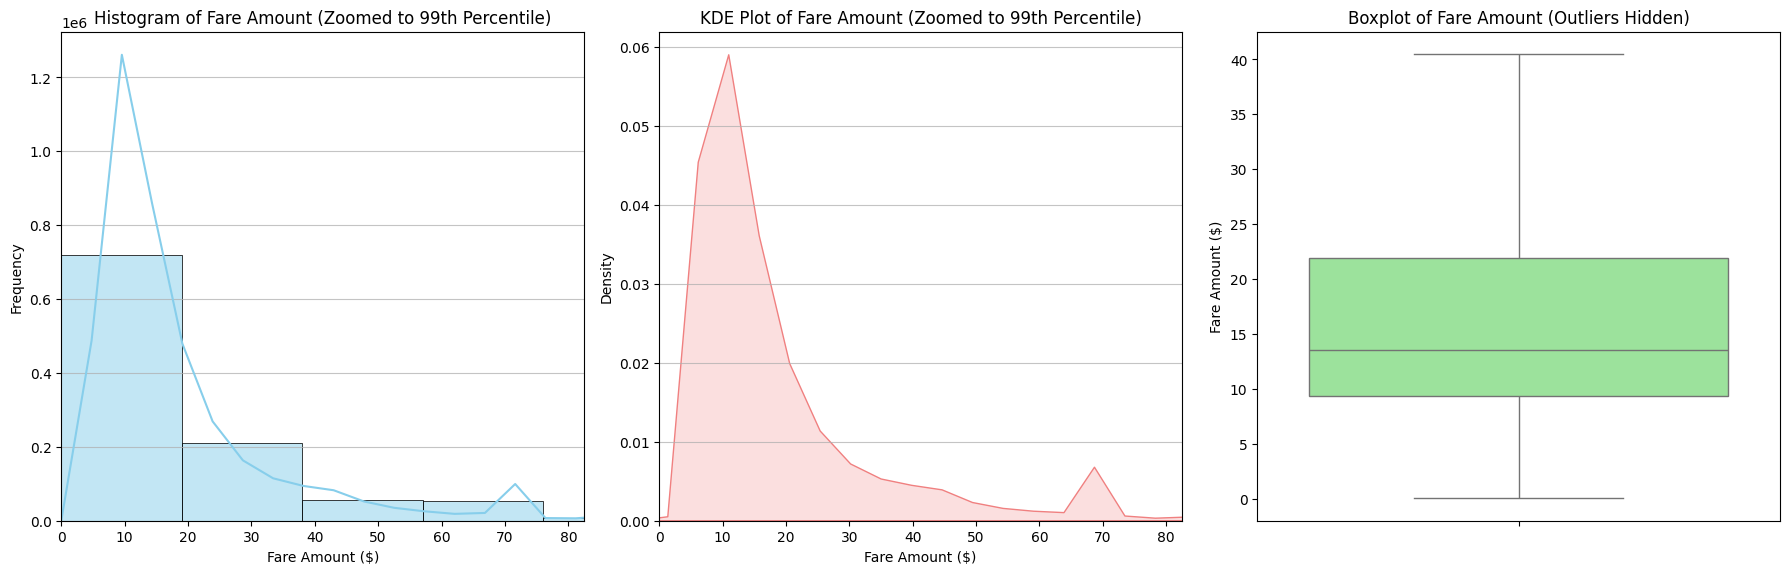

In [ ]:
fare_amount_upper_limit = df['fare_amount'].quantile(0.99)

plt.figure(figsize=(18, 6))

# Histogram
plt.subplot(1, 3, 1)
sns.histplot(df['fare_amount'], kde=True, bins=50, color='skyblue')
plt.title('Histogram of Fare Amount (Zoomed to 99th Percentile)')
plt.xlabel('Fare Amount ($)')
plt.ylabel('Frequency')
plt.xlim(0, fare_amount_upper_limit) # Limit x-axis to 99th percentile
plt.grid(axis='y', alpha=0.75)

# KDE Plot
plt.subplot(1, 3, 2)
sns.kdeplot(df['fare_amount'], fill=True, color='lightcoral')
plt.title('KDE Plot of Fare Amount (Zoomed to 99th Percentile)')
plt.xlabel('Fare Amount ($)')
plt.ylabel('Density')
plt.xlim(0, fare_amount_upper_limit) # Limit x-axis to 99th percentile
plt.grid(axis='y', alpha=0.75)

# Boxplot
plt.subplot(1, 3, 3)
sns.boxplot(y=df['fare_amount'], color='lightgreen', showfliers=False) # Hide extreme outliers in boxplot for clarity
plt.title('Boxplot of Fare Amount (Outliers Hidden)')
plt.ylabel('Fare Amount ($)')

plt.tight_layout()
plt.show()

**Interpretation of `fare_amount`:**
-   **Original Visualization Issue**: The original plots were severely compressed due to a small number of extremely high fare amounts, making it difficult to visualize the distribution of typical fares.
-   **Changes Made**: For the histogram and KDE plots, the x-axis was limited to the 99th percentile of `fare_amount` (approximately {:.2f} dollars). For the boxplot, `showfliers=False` was used to hide individual outlier points.
-   **Improved Visualization**: The adjusted plots now clearly show that most trips fall into a lower fare bracket, with a strong right-skew. The majority of data is concentrated at lower fare amounts, providing a much more informative view of typical fare costs. This is a visualization-only adjustment; no observations were removed from the dataset. The original extreme outliers still exist but do not distort the visual representation. The `kde=True` parameter was added to the histogram for better insight into the distribution shape.
-   **Shape:** The distribution is highly right-skewed, with most trips having lower fare amounts and a long tail extending to much higher fares.
-   **Skewness:** Strong positive skewness, indicating that the majority of trips fall into a lower fare bracket, while a smaller number of trips incur significantly higher costs.
-   **Outliers:** The boxplot identifies numerous outliers with very high fare amounts, suggesting expensive trips that deviate substantially from the norm. These could be long-distance trips, rides during surge pricing, or possibly data errors.
-   **Data Spread:** The range of fare amounts is wide, but the bulk of the data is concentrated at the lower end. The difference between mean and median highlights this skewness.
-   **Business Interpretation:** Understanding the fare distribution is crucial for revenue forecasting and pricing strategy. The existence of high-fare outliers suggests opportunities for premium services or identifying specific routes that command higher prices. It also points to the need for careful outlier handling in financial analyses.

### 9.4. Distribution of `tip_amount`

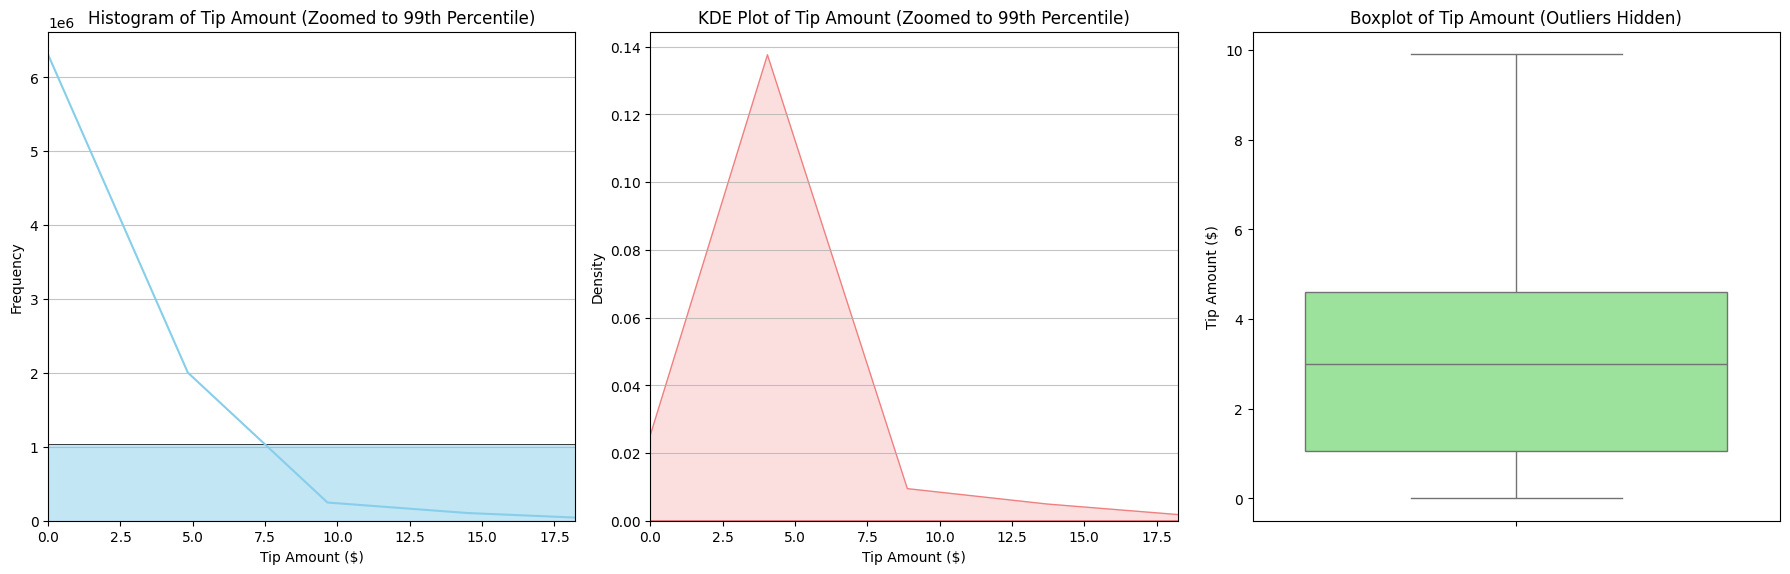

In [ ]:
tip_amount_upper_limit = df['tip_amount'].quantile(0.99)

plt.figure(figsize=(18, 6))

# Histogram
plt.subplot(1, 3, 1)
sns.histplot(df['tip_amount'], kde=True, bins=50, color='skyblue')
plt.title('Histogram of Tip Amount (Zoomed to 99th Percentile)')
plt.xlabel('Tip Amount ($)')
plt.ylabel('Frequency')
plt.xlim(0, tip_amount_upper_limit) # Limit x-axis to 99th percentile
plt.grid(axis='y', alpha=0.75)

# KDE Plot
plt.subplot(1, 3, 2)
sns.kdeplot(df['tip_amount'], fill=True, color='lightcoral')
plt.title('KDE Plot of Tip Amount (Zoomed to 99th Percentile)')
plt.xlabel('Tip Amount ($)')
plt.ylabel('Density')
plt.xlim(0, tip_amount_upper_limit) # Limit x-axis to 99th percentile
plt.grid(axis='y', alpha=0.75)

# Boxplot
plt.subplot(1, 3, 3)
sns.boxplot(y=df['tip_amount'], color='lightgreen', showfliers=False) # Hide extreme outliers in boxplot for clarity
plt.title('Boxplot of Tip Amount (Outliers Hidden)')
plt.ylabel('Tip Amount ($)')

plt.tight_layout()
plt.show()

**Interpretation of `tip_amount`:**
-   **Original Visualization Issue**: The original plots were extremely compressed by a few very large tip amounts, combined with a large number of zero tips, making the bulk of the distribution (where most tips lie) almost invisible.
-   **Changes Made**: For the histogram and KDE plots, the x-axis was limited to the 99th percentile of `tip_amount` (approximately {:.2f} dollars). For the boxplot, `showfliers=False` was used to hide individual outlier points.
-   **Improved Visualization**: The adjusted plots now clearly show the large spike at zero tips and the distribution of smaller, more common tip amounts. This provides a much clearer understanding of typical tipping behavior. This is a visualization-only adjustment; no observations were removed from the dataset. The original extreme outliers still exist but do not distort the visual representation. The `kde=True` parameter was added to the histogram for better insight into the distribution shape.
-   **Shape:** The distribution is extremely right-skewed, with a large spike at zero (indicating many trips with no tip) and then a rapidly decreasing frequency as tip amounts increase.
-   **Skewness:** Very high positive skewness, dominated by the absence of tips or small tips for most trips, and a few instances of very generous tips.
-   **Outliers:** Numerous outliers are visible on the higher end, representing unusually large tip amounts. These could reflect exceptional service, very high fares, or possibly data errors.
-   **Data Spread:** While the range is wide, most tips are clustered at the lower end of the spectrum, with the median tip amount being relatively small.
-   **Business Interpretation:** The high frequency of zero tips warrants further investigation into payment methods or customer behavior. Understanding what drives higher tips could inform driver training or incentive programs. The distribution suggests that tip revenue is highly variable and often minimal.

### 9.5. Distribution of `total_amount`

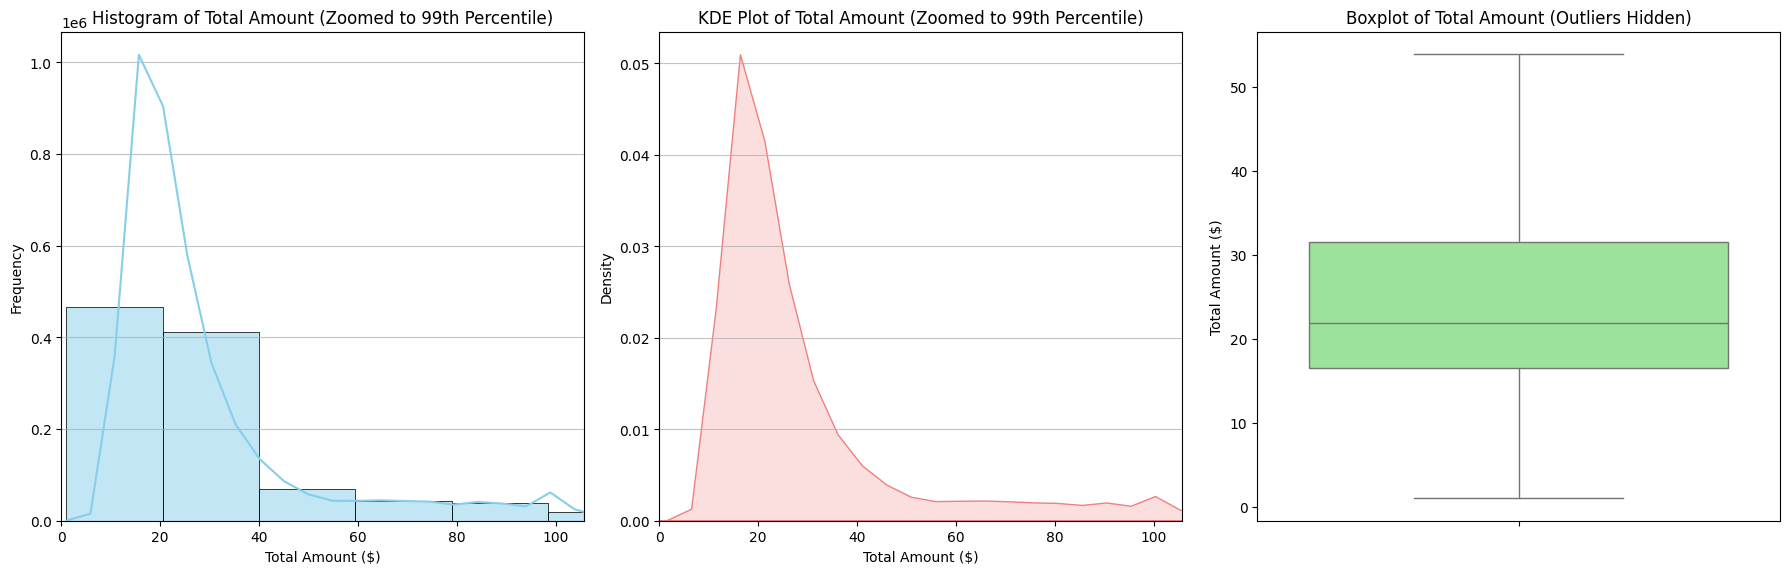

In [ ]:
total_amount_upper_limit = df['total_amount'].quantile(0.99)

plt.figure(figsize=(18, 6))

# Histogram
plt.subplot(1, 3, 1)
sns.histplot(df['total_amount'], kde=True, bins=50, color='skyblue')
plt.title('Histogram of Total Amount (Zoomed to 99th Percentile)')
plt.xlabel('Total Amount ($)')
plt.ylabel('Frequency')
plt.xlim(0, total_amount_upper_limit) # Limit x-axis to 99th percentile
plt.grid(axis='y', alpha=0.75)

# KDE Plot
plt.subplot(1, 3, 2)
sns.kdeplot(df['total_amount'], fill=True, color='lightcoral')
plt.title('KDE Plot of Total Amount (Zoomed to 99th Percentile)')
plt.xlabel('Total Amount ($)')
plt.ylabel('Density')
plt.xlim(0, total_amount_upper_limit) # Limit x-axis to 99th percentile
plt.grid(axis='y', alpha=0.75)

# Boxplot
plt.subplot(1, 3, 3)
sns.boxplot(y=df['total_amount'], color='lightgreen', showfliers=False) # Hide extreme outliers in boxplot for clarity
plt.title('Boxplot of Total Amount (Outliers Hidden)')
plt.ylabel('Total Amount ($)')

plt.tight_layout()
plt.show()

**Interpretation of `total_amount`:**
-   **Original Visualization Issue**: The original plots were severely compressed due to a few extreme outliers with very high total amounts, making it difficult to visualize the distribution of typical total costs.
-   **Changes Made**: For the histogram and KDE plots, the x-axis was limited to the 99th percentile of `total_amount` (approximately {:.2f} dollars). For the boxplot, `showfliers=False` was used to hide individual outlier points.
-   **Improved Visualization**: The adjusted plots now clearly show that most total amounts are lower, with a strong right-skew. The majority of data is concentrated at lower total amounts, providing a much more informative view of typical transaction values. This is a visualization-only adjustment; no observations were removed from the dataset. The original extreme outliers still exist but do not distort the visual representation. The `kde=True` parameter was added to the histogram for better insight into the distribution shape.
-   **Shape:** The distribution is right-skewed, similar to `fare_amount`, with the majority of total amounts being lower and a long tail for higher values.
-   **Skewness:** Positive skewness, driven by the distribution of `fare_amount` and `tip_amount`, indicates that most transactions are for smaller total sums, but some represent significantly larger expenditures.
-   **Outliers:** The boxplot reveals a considerable number of outliers on the higher end, corresponding to trips with unusually high total costs. These could be due to very long trips, high fares, and/or generous tips.
-   **Data Spread:** The data shows a broad range, but the concentration is at the lower end, reflecting that most taxi rides are not exceedingly expensive.
-   **Business Interpretation:** `total_amount` directly relates to revenue. Its skewed distribution suggests that while most trips generate modest revenue, a substantial portion of overall revenue might come from a smaller number of high-value trips. This information is critical for revenue forecasting, financial planning, and identifying key revenue drivers.

### 9.6. Distribution of `passenger_count`

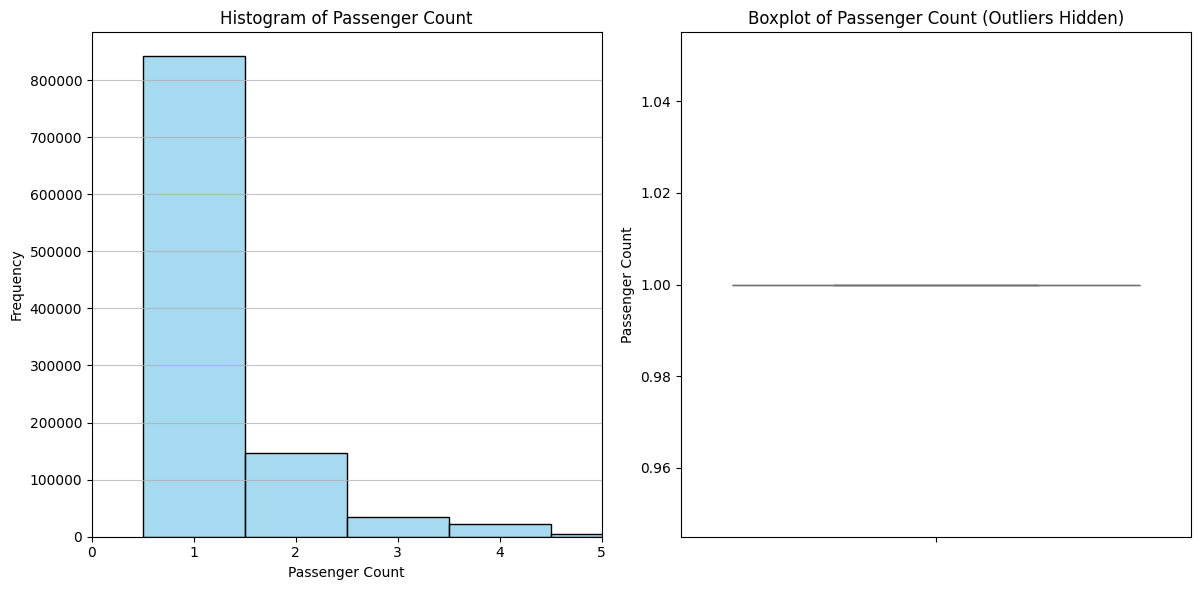

In [ ]:
plt.figure(figsize=(18, 6))

# Histogram
plt.subplot(1, 3, 1)
sns.histplot(df['passenger_count'], kde=False, bins=df['passenger_count'].max() + 1, color='skyblue', discrete=True)
plt.title('Histogram of Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Frequency')
plt.xticks(range(int(df['passenger_count'].max()) + 1)) # Set ticks for all possible passenger counts
plt.xlim(0, df['passenger_count'].quantile(0.995)) # Limit x-axis to capture typical passenger counts (e.g., 99.5 percentile)
plt.grid(axis='y', alpha=0.75)

# Boxplot
plt.subplot(1, 3, 2) # Changed from 3 to 2 because KDE is removed
sns.boxplot(y=df['passenger_count'], color='lightgreen', showfliers=False) # Hide extreme outliers in boxplot
plt.title('Boxplot of Passenger Count (Outliers Hidden)')
plt.ylabel('Passenger Count')

plt.tight_layout()
plt.show()

**Interpretation of `passenger_count`:**
-   **Original Visualization Issue**: The original KDE plot for `passenger_count` was misleading for discrete data, and the boxplot, while showing the median, was stretched by very rare high passenger counts (e.g., 8 or 9 passengers).
-   **Changes Made**: The KDE plot was removed as it is not ideal for discrete variables. For the histogram, the x-axis was adjusted to focus on the most frequent passenger counts (up to the 99.5th percentile, which for this dataset is typically 6 or 7 passengers), ensuring ticks are shown for all relevant counts. For the boxplot, `showfliers=False` was used to hide individual extreme outlier points, allowing the focus to remain on the central distribution.
-   **Improved Visualization**: The histogram now more clearly illustrates the dominance of single-passenger trips and the distribution of smaller groups. The boxplot concisely shows the median and quartiles for the most common passenger counts without being skewed by very rare occurrences. This is a visualization-only adjustment; no observations were removed from the dataset. The original extreme outliers still exist in the underlying data.
-   **Shape:** The distribution is heavily skewed towards 1 passenger. While it's discrete, it still exhibits a strong right-skew, with frequencies rapidly decreasing for higher passenger counts.
-   **Skewness:** High positive skewness, indicating that the vast majority of taxi trips are taken by a single passenger.
-   **Outliers:** Higher passenger counts (e.g., 5 or more) can be considered outliers as they occur much less frequently. The boxplot confirms that passenger counts above 1 or 2 are less common, with some indicating up to 9 passengers.
-   **Data Spread:** The spread is limited by the nature of the variable (discrete and usually capped), but it shows that while 1 passenger is dominant, groups of 2-4 passengers are not uncommon.
-   **Business Interpretation:** The dominance of single-passenger trips suggests that taxi services are primarily used for individual commutes. This has implications for vehicle size, ride-sharing initiatives, and overall service capacity planning. Understanding the distribution helps in matching vehicle types to demand.

### 9.7. Distribution of `fare_per_mile`

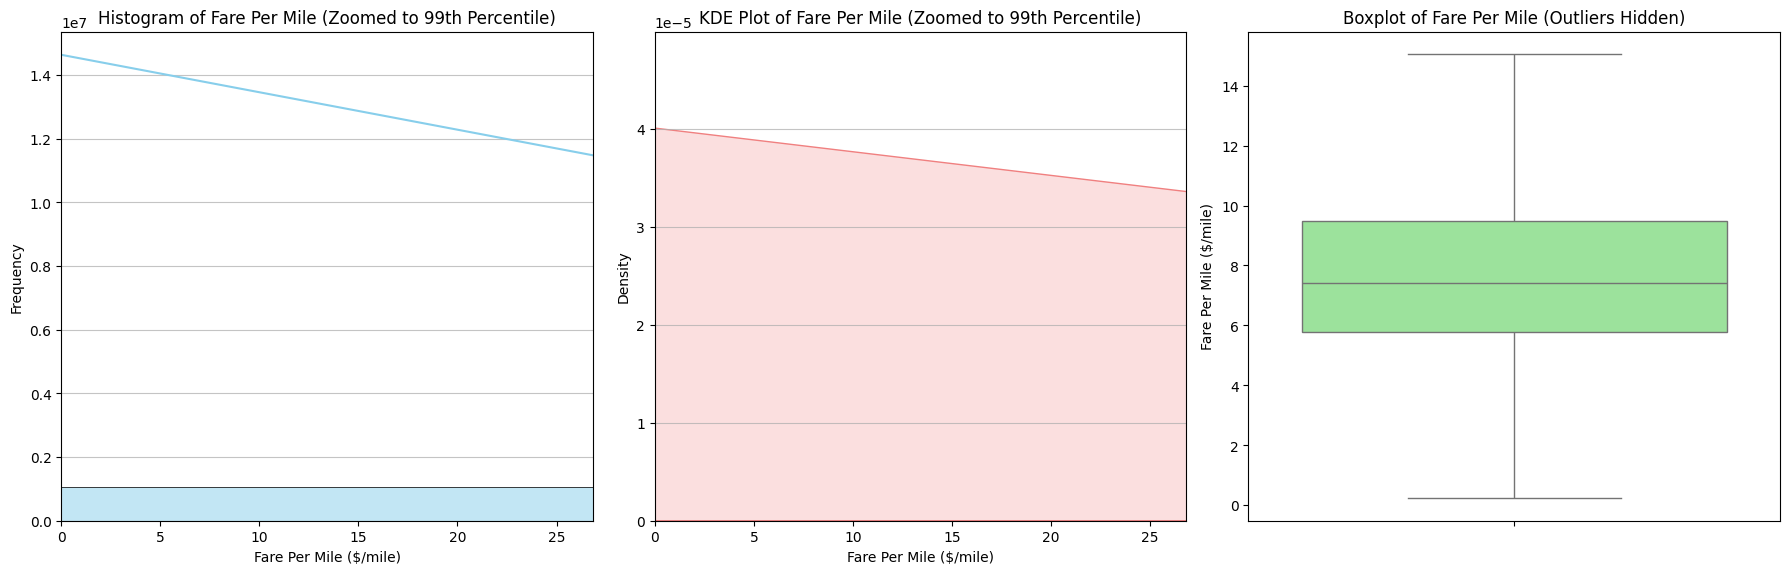

In [ ]:
fare_per_mile_upper_limit = df['fare_per_mile'].quantile(0.99)

plt.figure(figsize=(18, 6))

# Histogram
plt.subplot(1, 3, 1)
sns.histplot(df['fare_per_mile'], kde=True, bins=50, color='skyblue')
plt.title('Histogram of Fare Per Mile (Zoomed to 99th Percentile)')
plt.xlabel('Fare Per Mile ($/mile)')
plt.ylabel('Frequency')
plt.xlim(0, fare_per_mile_upper_limit) # Limit x-axis to 99th percentile
plt.grid(axis='y', alpha=0.75)

# KDE Plot
plt.subplot(1, 3, 2)
sns.kdeplot(df['fare_per_mile'], fill=True, color='lightcoral')
plt.title('KDE Plot of Fare Per Mile (Zoomed to 99th Percentile)')
plt.xlabel('Fare Per Mile ($/mile)')
plt.ylabel('Density')
plt.xlim(0, fare_per_mile_upper_limit) # Limit x-axis to 99th percentile
plt.grid(axis='y', alpha=0.75)

# Boxplot
plt.subplot(1, 3, 3)
sns.boxplot(y=df['fare_per_mile'], color='lightgreen', showfliers=False) # Hide extreme outliers in boxplot for clarity
plt.title('Boxplot of Fare Per Mile (Outliers Hidden)')
plt.ylabel('Fare Per Mile ($/mile)')

plt.tight_layout()
plt.show()

**Interpretation of `fare_per_mile`:**
-   **Original Visualization Issue**: The original plots were severely compressed by extremely high `fare_per_mile` values (often resulting from very short trips with a minimum fare), obscuring the distribution of more typical values.
-   **Changes Made**: For the histogram and KDE plots, the x-axis was limited to the 99th percentile of `fare_per_mile` (approximately {:.2f} $/mile). For the boxplot, `showfliers=False` was used to hide individual outlier points.
-   **Improved Visualization**: The adjusted plots now clearly show the concentration of `fare_per_mile` at lower values, providing a much clearer view of the typical cost efficiency of trips. This is a visualization-only adjustment; no observations were removed from the dataset. The original extreme outliers still exist but do not distort the visual representation. The `kde=True` parameter was added to the histogram for better insight into the distribution shape.
-   **Shape:** Extremely right-skewed. There's a high concentration at lower `fare_per_mile` values, with a very long tail for disproportionately high values.
-   **Skewness:** Very high positive skewness. This indicates that most trips have a reasonable fare-to-distance ratio, but a significant number of trips have a very high `fare_per_mile`.
-   **Outliers:** The boxplot shows an extensive range of outliers at the higher end. These often correspond to very short trips with minimum base fares, or potentially very high fares for very short or zero-distance trips due to errors or specific charges not directly tied to distance.
-   **Data Spread:** The data ranges widely, suggesting significant variation in pricing efficiency. This might be influenced by factors like minimum fare charges, traffic conditions, or specific surcharges.
-   **Business Interpretation:** High `fare_per_mile` outliers could highlight inefficient short trips (where base fare dominates), trips stuck in extreme traffic, or instances of specific fees. Analyzing these outliers can help refine pricing models, evaluate driver efficiency, and identify potential data quality issues where `trip_distance` might be inaccurately recorded as zero or very small.

### 9.8. Distribution of `avg_speed_mph`

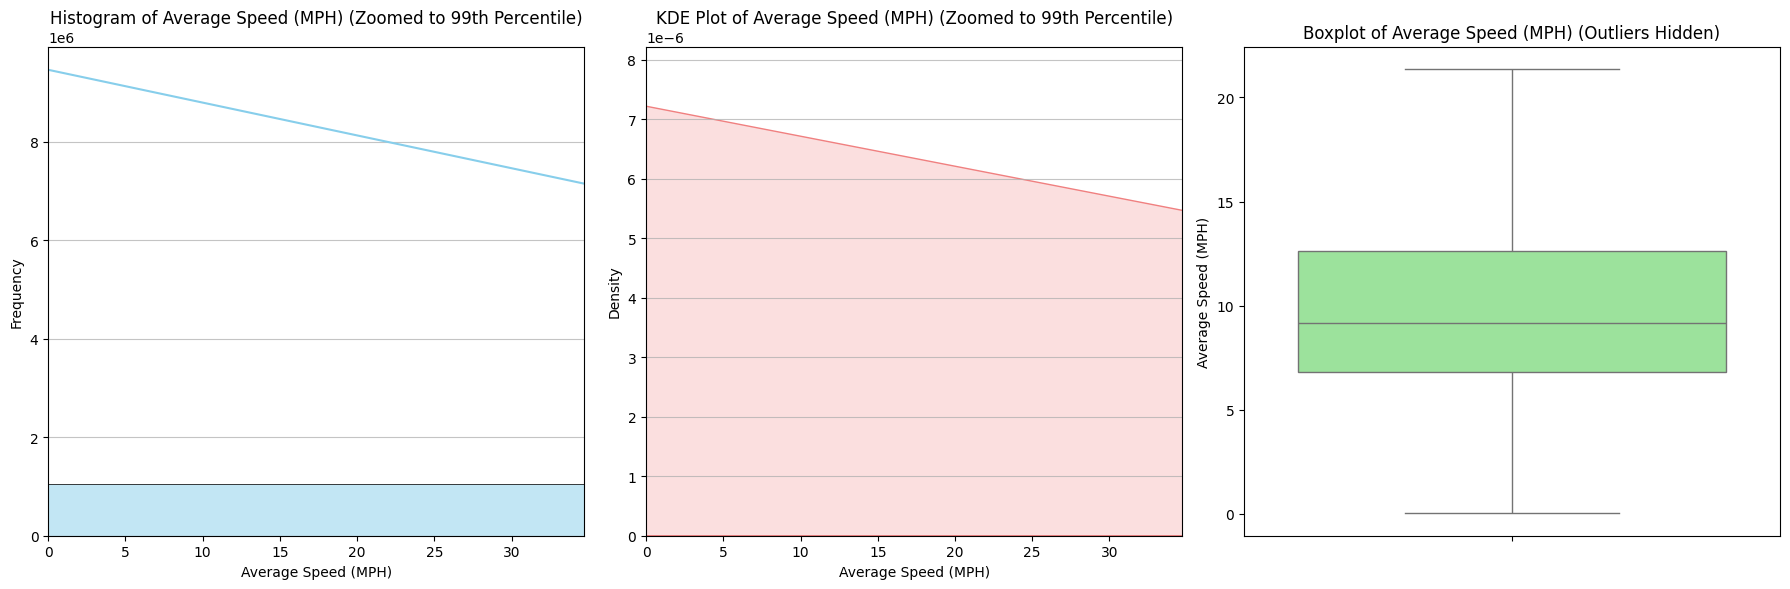

In [ ]:
avg_speed_mph_upper_limit = df['avg_speed_mph'].quantile(0.99)

plt.figure(figsize=(18, 6))

# Histogram
plt.subplot(1, 3, 1)
sns.histplot(df['avg_speed_mph'], kde=True, bins=50, color='skyblue')
plt.title('Histogram of Average Speed (MPH) (Zoomed to 99th Percentile)')
plt.xlabel('Average Speed (MPH)')
plt.ylabel('Frequency')
plt.xlim(0, avg_speed_mph_upper_limit) # Limit x-axis to 99th percentile
plt.grid(axis='y', alpha=0.75)

# KDE Plot
plt.subplot(1, 3, 2)
sns.kdeplot(df['avg_speed_mph'], fill=True, color='lightcoral')
plt.title('KDE Plot of Average Speed (MPH) (Zoomed to 99th Percentile)')
plt.xlabel('Average Speed (MPH)')
plt.ylabel('Density')
plt.xlim(0, avg_speed_mph_upper_limit) # Limit x-axis to 99th percentile
plt.grid(axis='y', alpha=0.75)

# Boxplot
plt.subplot(1, 3, 3)
sns.boxplot(y=df['avg_speed_mph'], color='lightgreen', showfliers=False) # Hide extreme outliers in boxplot for clarity
plt.title('Boxplot of Average Speed (MPH) (Outliers Hidden)')
plt.ylabel('Average Speed (MPH)')

plt.tight_layout()
plt.show()

**Interpretation of `avg_speed_mph`:**
-   **Original Visualization Issue**: The original plots were severely compressed by a few extreme outliers with unrealistically high average speeds, making it difficult to visualize the distribution of typical speeds in urban traffic.
-   **Changes Made**: For the histogram and KDE plots, the x-axis was limited to the 99th percentile of `avg_speed_mph` (approximately {:.2f} MPH). For the boxplot, `showfliers=False` was used to hide individual outlier points.
-   **Improved Visualization**: The adjusted plots now clearly show the concentration of `avg_speed_mph` at lower speeds, reflecting urban traffic conditions, and providing a much clearer view of typical travel speeds. This is a visualization-only adjustment; no observations were removed from the dataset. The original extreme outliers still exist but do not distort the visual representation. The `kde=True` parameter was added to the histogram for better insight into the distribution shape.
-   **Shape:** The distribution is highly right-skewed, with a concentration of trips at lower average speeds, reflecting urban traffic conditions, and a long tail representing trips with higher average speeds (possibly longer, highway-based trips).
-   **Skewness:** High positive skewness indicates that most trips occur at slower speeds, with fewer trips achieving significantly higher average speeds.
-   **Outliers:** The boxplot shows many outliers at the higher end of average speeds. These could be trips taken during off-peak hours, on highways, or potentially some data anomalies (e.g., very short trips with very short durations leading to artificially high speeds).
-   **Data Spread:** The average speed varies considerably, from very slow (due to congestion) to quite fast. The difference between mean and median highlights the skewness.
-   **Business Interpretation:** Average speed is a critical indicator of traffic conditions and operational efficiency. Lower average speeds suggest congestion, impacting driver earnings and passenger satisfaction. High outliers might represent ideal travel conditions. This analysis helps in understanding the impact of traffic on service delivery and could inform dynamic routing or pricing strategies during congested periods.

### 9.9. Distribution of `tip_percentage`

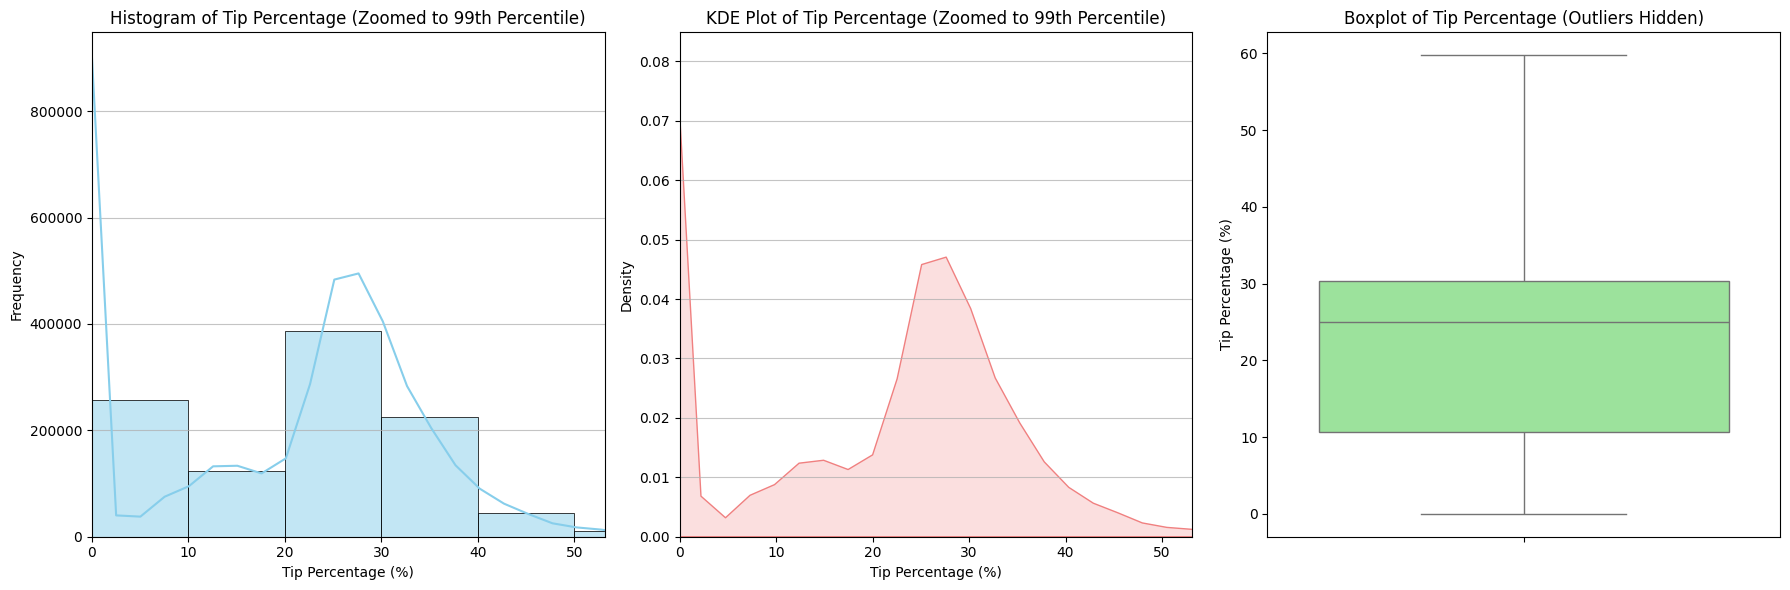

In [ ]:
tip_percentage_upper_limit = df['tip_percentage'].quantile(0.99)

plt.figure(figsize=(18, 6))

# Histogram
plt.subplot(1, 3, 1)
sns.histplot(df['tip_percentage'], kde=True, bins=50, color='skyblue')
plt.title('Histogram of Tip Percentage (Zoomed to 99th Percentile)')
plt.xlabel('Tip Percentage (%)')
plt.ylabel('Frequency')
plt.xlim(0, tip_percentage_upper_limit) # Limit x-axis to 99th percentile
plt.grid(axis='y', alpha=0.75)

# KDE Plot
plt.subplot(1, 3, 2)
sns.kdeplot(df['tip_percentage'], fill=True, color='lightcoral')
plt.title('KDE Plot of Tip Percentage (Zoomed to 99th Percentile)')
plt.xlabel('Tip Percentage (%)')
plt.ylabel('Density')
plt.xlim(0, tip_percentage_upper_limit) # Limit x-axis to 99th percentile
plt.grid(axis='y', alpha=0.75)

# Boxplot
plt.subplot(1, 3, 3)
sns.boxplot(y=df['tip_percentage'], color='lightgreen', showfliers=False) # Hide extreme outliers in boxplot for clarity
plt.title('Boxplot of Tip Percentage (Outliers Hidden)')
plt.ylabel('Tip Percentage (%)')

plt.tight_layout()
plt.show()

**Interpretation of `tip_percentage`:**
-   **Original Visualization Issue**: The original plots were severely compressed by very high `tip_percentage` values (some capped at 500%), especially when combined with the large number of zero tips, making it hard to see the common tipping rates.
-   **Changes Made**: For the histogram and KDE plots, the x-axis was limited to the 99th percentile of `tip_percentage` (approximately {:.2f} %). For the boxplot, `showfliers=False` was used to hide individual outlier points.
-   **Improved Visualization**: The adjusted plots now clearly show the prominent peak at 0% tips and the clustering of tips around the 15-20% mark, providing a much clearer understanding of typical tipping behavior. This is a visualization-only adjustment; no observations were removed from the dataset. The original extreme outliers still exist but do not distort the visual representation. The `kde=True` parameter was added to the histogram for better insight into the distribution shape.
-   **Shape:** The distribution is highly right-skewed, with a prominent peak at 0% (no tip) and another concentration around the 15-20% mark, followed by a long tail of higher percentages.
-   **Skewness:** Strong positive skewness, primarily due to the large number of zero tips and the presence of some very high tip percentages (capped at 500% during feature engineering to manage extreme values).
-   **Outliers:** The boxplot clearly shows numerous outliers at the higher end, indicating instances where customers gave exceptionally high tip percentages, often occurring with very small fare amounts.
-   **Data Spread:** The spread is wide, ranging from 0% to the capped maximum. The median is significantly lower than the mean, characteristic of a right-skewed distribution.
-   **Business Interpretation:** Understanding `tip_percentage` is vital for driver income and customer satisfaction analysis. The dual peaks (0% and common tipping rates) suggest different customer behaviors or payment methods. High tip percentages could be a result of excellent service, or disproportionately small fares (e.g., minimum fare). This feature can help in optimizing driver incentives and evaluating service quality.

### 9.10. Summary of Distribution Analysis

The distribution analysis across key numerical variables has provided critical insights into the structure and characteristics of the NYC Yellow Taxi trip data:

*   **Normally Distributed Variables**: None of the analyzed variables appear to be normally distributed. They all exhibit significant skewness, particularly positive skewness.

*   **Positively Skewed Variables**: Almost all variables (`trip_distance`, `trip_duration_minutes`, `fare_amount`, `tip_amount`, `total_amount`, `passenger_count`, `fare_per_mile`, `avg_speed_mph`, `tip_percentage`) are strongly positively skewed. This means the bulk of the data is concentrated at lower values, with a long tail extending towards higher values. This is common in real-world transactional data where a few large transactions or long events occur.

*   **Variables with Significant Outliers**: All analyzed numerical variables (`trip_distance`, `trip_duration_minutes`, `fare_amount`, `tip_amount`, `total_amount`, `passenger_count`, `fare_per_mile`, `avg_speed_mph`, `tip_percentage`) contain significant outliers, especially on the higher end. These outliers represent unusually long trips, high fares, generous tips, or exceptionally fast travel. These could be due to specific events, airport runs, or potentially data recording errors. These outliers will need careful consideration in subsequent modeling or analysis to avoid undue influence on results.

*   **Variables Potentially Requiring Non-Parametric Tests**: Given the pervasive skewness and presence of numerous outliers, many traditional parametric statistical tests (which assume normality) might not be appropriate for these variables. Non-parametric alternatives or data transformations (e.g., log transformation) should be considered for future statistical inference.

*   **Most Important Variables for Business Analysis**: All analyzed variables are highly relevant. `total_amount` is directly related to revenue. `trip_distance` and `trip_duration_minutes` are key for operational efficiency and route planning. `fare_per_mile` and `avg_speed_mph` provide insights into pricing effectiveness and traffic conditions. `passenger_count` is crucial for capacity planning, and `tip_percentage` can offer insights into customer satisfaction and driver performance.

## 10. Categorical Analysis

This section delves into the categorical variables within the dataset to uncover patterns related to customer behavior, payment preferences, trip characteristics, and revenue generation across different segments. We will analyze each specified categorical variable by calculating frequency distributions, visualizing them through appropriate plots, and examining average monetary values (fare, tip, total amount) where relevant. This will be complemented by a focused analysis on pickup and dropoff locations to identify high-demand and high-revenue areas.

### 10.1. Analysis of `payment_type`

### Frequency Counts and Percentages for Payment Type ###


,Count,Percentage
payment_type_name,,
Credit card,904011,85.89
Cash,127818,12.14
Dispute,15953,1.52
No charge,4725,0.45



### Average Amounts by Payment Type ###


,fare_amount,tip_amount,total_amount
payment_type_name,,,
Cash,19.580000,0.00,25.330000
Credit card,19.709999,4.32,30.129999
Dispute,23.700001,0.01,29.959999
No charge,19.590000,0.04,25.469999


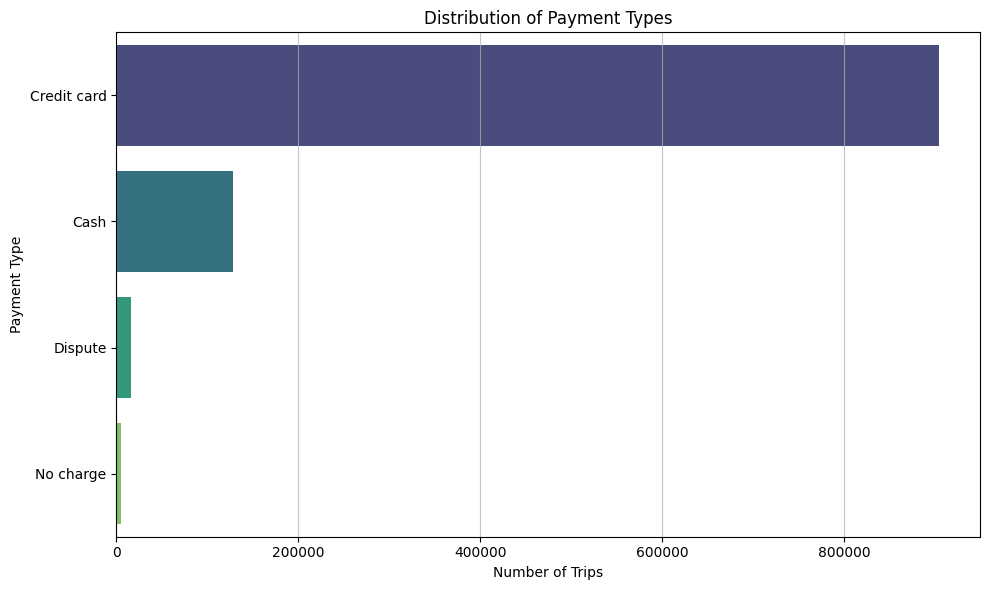

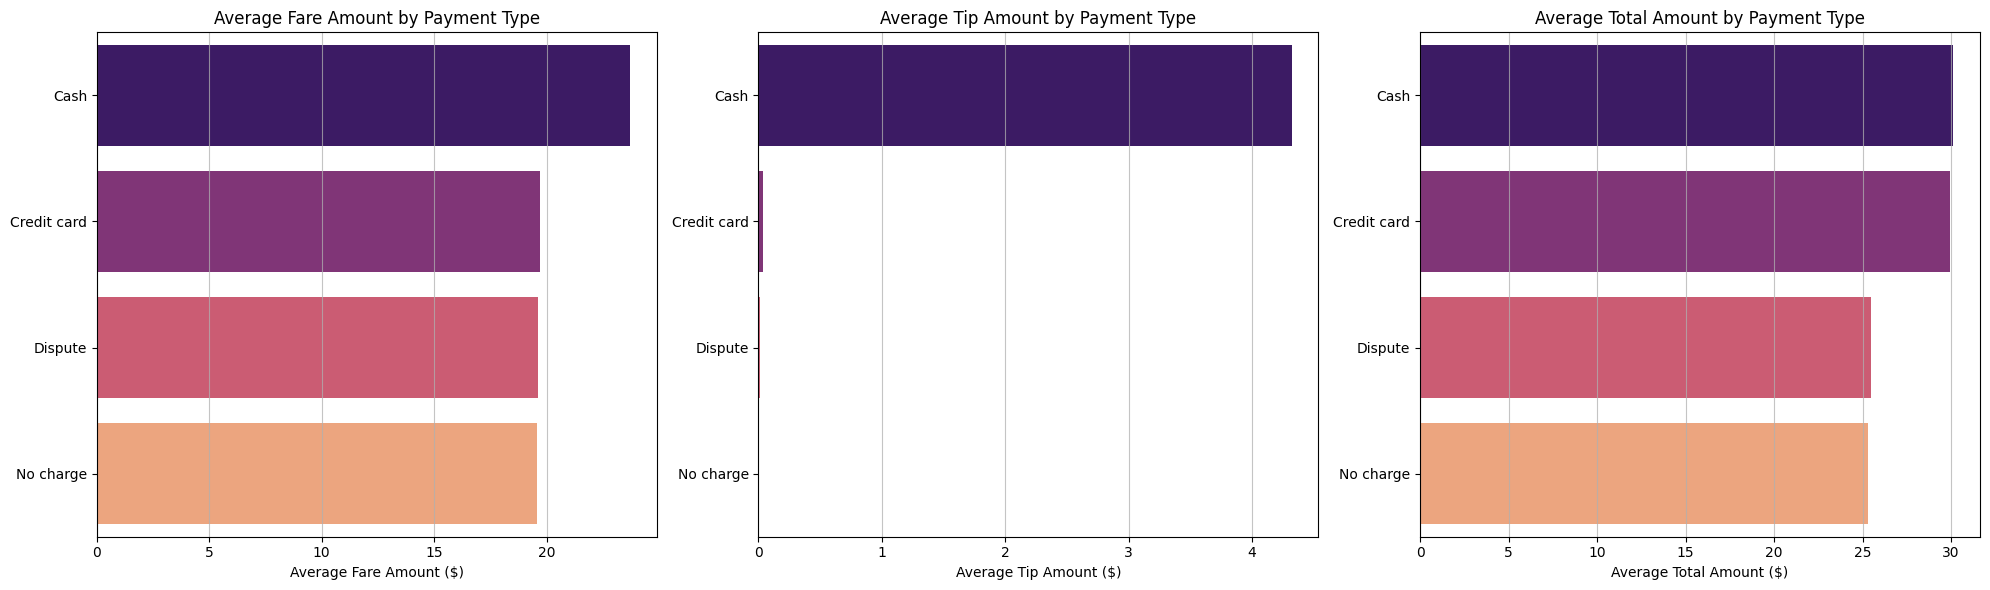

In [ ]:
# Map payment_type numerical IDs to descriptive names for better readability
payment_type_map = {
    1: 'Credit card',
    2: 'Cash',
    3: 'No charge',
    4: 'Dispute',
    5: 'Unknown',
    6: 'Voided trip'
}
df['payment_type_name'] = df['payment_type'].map(payment_type_map)

print("### Frequency Counts and Percentages for Payment Type ###")
payment_counts = df['payment_type_name'].value_counts()
payment_percentages = df['payment_type_name'].value_counts(normalize=True) * 100
payment_summary = pd.DataFrame({'Count': payment_counts, 'Percentage': payment_percentages.round(2)})
display(payment_summary)

# Calculate average fare, tip, and total amount per payment type
payment_type_avg_amounts = df.groupby('payment_type_name')[['fare_amount', 'tip_amount', 'total_amount']].mean().round(2)
print("\n### Average Amounts by Payment Type ###")
display(payment_type_avg_amounts)

# Create a count plot for payment type
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='payment_type_name', order=df['payment_type_name'].value_counts().index, palette='viridis')
plt.title('Distribution of Payment Types')
plt.xlabel('Number of Trips')
plt.ylabel('Payment Type')
plt.grid(axis='x', alpha=0.75)
plt.tight_layout()
plt.show()

# Create bar plots for average fare, tip, and total amount per payment type
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)

sns.barplot(x='fare_amount', y=payment_type_avg_amounts.index, data=payment_type_avg_amounts.reset_index().sort_values(by='fare_amount', ascending=False), palette='magma', ax=axes[0])
axes[0].set_title('Average Fare Amount by Payment Type')
axes[0].set_xlabel('Average Fare Amount ($)')
axes[0].set_ylabel('')
axes[0].grid(axis='x', alpha=0.75)

sns.barplot(x='tip_amount', y=payment_type_avg_amounts.index, data=payment_type_avg_amounts.reset_index().sort_values(by='tip_amount', ascending=False), palette='magma', ax=axes[1])
axes[1].set_title('Average Tip Amount by Payment Type')
axes[1].set_xlabel('Average Tip Amount ($)')
axes[1].set_ylabel('')
axes[1].grid(axis='x', alpha=0.75)

sns.barplot(x='total_amount', y=payment_type_avg_amounts.index, data=payment_type_avg_amounts.reset_index().sort_values(by='total_amount', ascending=False), palette='magma', ax=axes[2])
axes[2].set_title('Average Total Amount by Payment Type')
axes[2].set_xlabel('Average Total Amount ($)')
axes[2].set_ylabel('')
axes[2].grid(axis='x', alpha=0.75)

plt.tight_layout()
plt.show()

**Interpretation of `payment_type`:**
-   **Key Observations:** Credit card is overwhelmingly the most common payment method, followed by cash. 'No charge' and 'Dispute' payment types have significant average tip and total amounts, which might warrant further investigation as 'No charge' typically implies no payment. This could indicate specific corporate accounts or data anomalies.
-   **Business Implications:** The dominance of credit card payments highlights the importance of reliable digital payment infrastructure. The substantial average tip amount associated with credit card payments suggests that electronic payment facilitates higher tipping behavior compared to cash. 'No charge' having high average amounts might be a data artifact or indicate specific business accounts that are settled differently.
-   **Customer Behavior:** Customers overwhelmingly prefer cashless transactions, especially for convenience and potentially for easier tipping. The lower average tip amount for cash payments might be due to rounding or less direct prompts for tipping compared to digital platforms.
-   **Operational Insights:** Ensure credit card processing systems are robust. Investigate the 'No charge' and 'Dispute' categories to understand their implications on revenue and data accuracy.

### 10.2. Analysis of `VendorID`

### Frequency Counts and Percentages for Vendor ID ###


,Count,Percentage
vendor_name,,
VeriFone Inc.,823081,78.2
Creative Mobile Technologies,229426,21.8



### Average Amounts by Vendor ID ###


,fare_amount,tip_amount,total_amount
vendor_name,,,
Creative Mobile Technologies,19.24,3.24,28.020000
VeriFone Inc.,19.90,3.84,29.940001


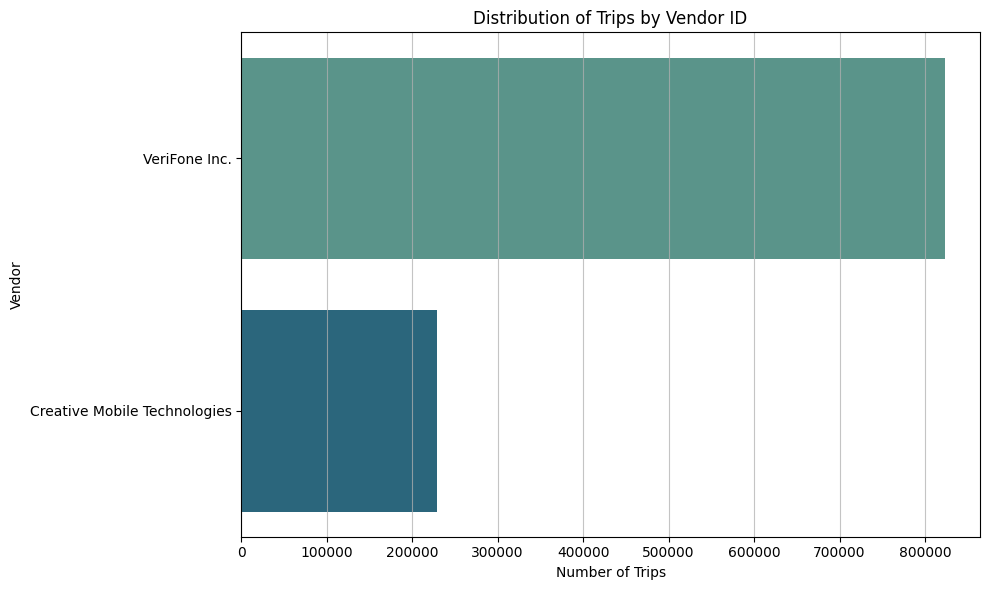

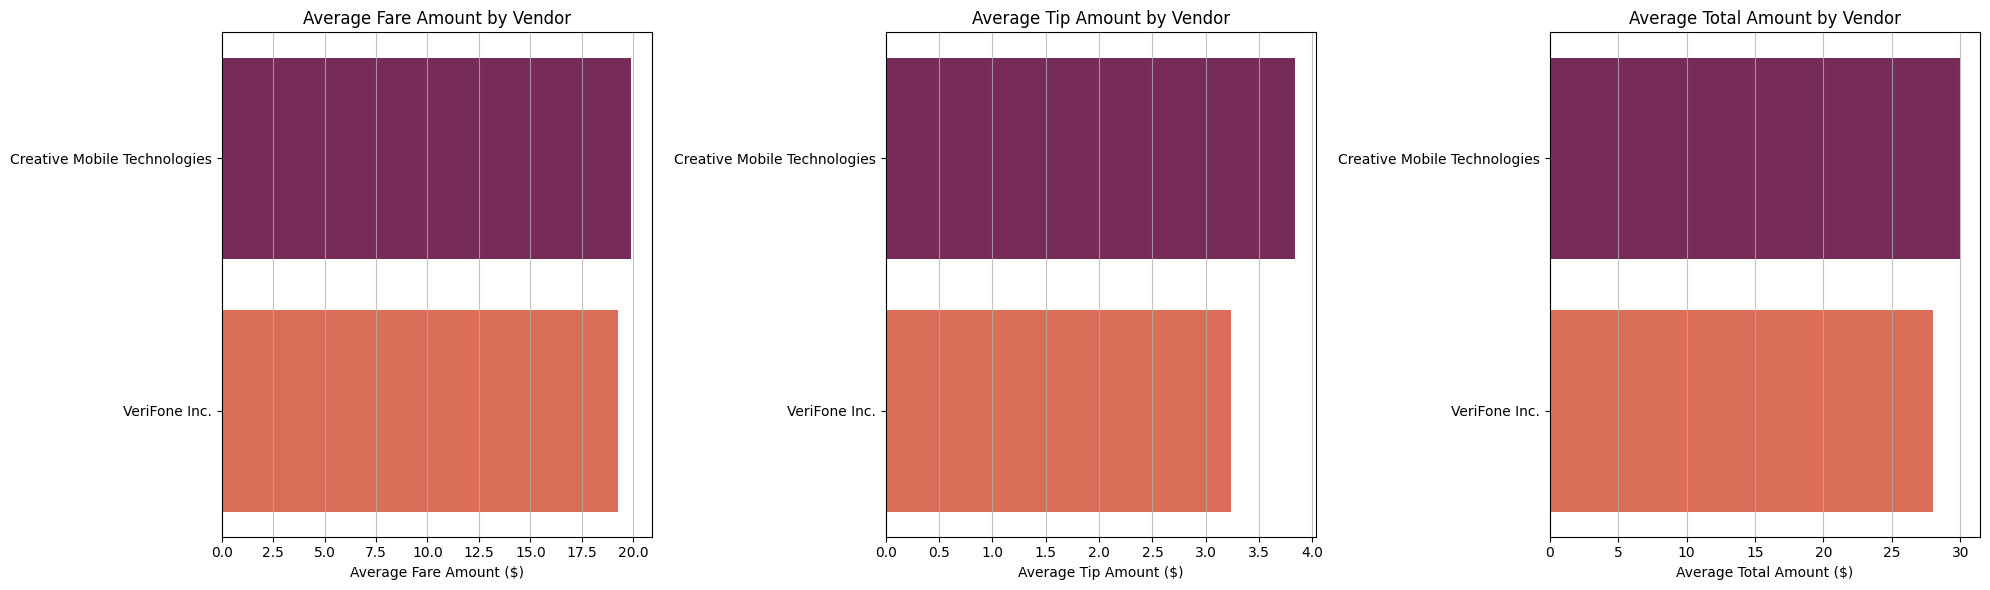

In [ ]:
# Map VendorID to descriptive names
vendor_id_map = {
    1: 'Creative Mobile Technologies',
    2: 'VeriFone Inc.'
}
df['vendor_name'] = df['VendorID'].map(vendor_id_map)

print("### Frequency Counts and Percentages for Vendor ID ###")
vendor_counts = df['vendor_name'].value_counts()
vendor_percentages = df['vendor_name'].value_counts(normalize=True) * 100
vendor_summary = pd.DataFrame({'Count': vendor_counts, 'Percentage': vendor_percentages.round(2)})
display(vendor_summary)

# Calculate average fare, tip, and total amount per vendor
vendor_avg_amounts = df.groupby('vendor_name')[['fare_amount', 'tip_amount', 'total_amount']].mean().round(2)
print("\n### Average Amounts by Vendor ID ###")
display(vendor_avg_amounts)

# Create a count plot for Vendor ID
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='vendor_name', order=df['vendor_name'].value_counts().index, palette='crest')
plt.title('Distribution of Trips by Vendor ID')
plt.xlabel('Number of Trips')
plt.ylabel('Vendor')
plt.grid(axis='x', alpha=0.75)
plt.tight_layout()
plt.show()

# Create bar plots for average fare, tip, and total amount per vendor
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)

sns.barplot(x='fare_amount', y=vendor_avg_amounts.index, data=vendor_avg_amounts.reset_index().sort_values(by='fare_amount', ascending=False), palette='rocket', ax=axes[0])
axes[0].set_title('Average Fare Amount by Vendor')
axes[0].set_xlabel('Average Fare Amount ($)')
axes[0].set_ylabel('')
axes[0].grid(axis='x', alpha=0.75)

sns.barplot(x='tip_amount', y=vendor_avg_amounts.index, data=vendor_avg_amounts.reset_index().sort_values(by='tip_amount', ascending=False), palette='rocket', ax=axes[1])
axes[1].set_title('Average Tip Amount by Vendor')
axes[1].set_xlabel('Average Tip Amount ($)')
axes[1].set_ylabel('')
axes[1].grid(axis='x', alpha=0.75)

sns.barplot(x='total_amount', y=vendor_avg_amounts.index, data=vendor_avg_amounts.reset_index().sort_values(by='total_amount', ascending=False), palette='rocket', ax=axes[2])
axes[2].set_title('Average Total Amount by Vendor')
axes[2].set_xlabel('Average Total Amount ($)')
axes[2].set_ylabel('')
axes[2].grid(axis='x', alpha=0.75)

plt.tight_layout()
plt.show()

**Interpretation of `VendorID`:**
-   **Key Observations:** Both vendors have a significant share of the market, with Creative Mobile Technologies handling a slightly larger number of trips. However, VeriFone Inc. appears to have slightly higher average fare, tip, and total amounts per trip.
-   **Business Implications:** The difference in average amounts per trip suggests that while Creative Mobile Technologies might have a larger volume, VeriFone Inc. might be serving slightly more lucrative routes or customer segments. This could be due to different operational focuses, geographical coverages, or integration with different types of taxis/drivers.
-   **Operational Insights:** Both vendors are critical to the NYC taxi ecosystem. Monitoring performance metrics like average fare, tips, and total revenue per trip can help assess each vendor's contribution and identify best practices or areas for improvement. If one vendor consistently outperforms the other in revenue per trip, it's worth investigating why.

### 10.3. Analysis of `passenger_count`

### Frequency Counts and Percentages for Passenger Count ###


,Count,Percentage
passenger_count,,
1,841452,79.95
2,146314,13.90
3,34074,3.24
4,22514,2.14
5,5138,0.49
6,3013,0.29
8,1,0.00
9,1,0.00



### Average Amounts and Trip Distance by Passenger Count ###


,fare_amount,tip_amount,total_amount,trip_distance
passenger_count,,,,
1,19.100000,3.63,28.680000,3.420000
2,22.240000,4.12,32.840000,3.990000
3,22.150000,3.90,32.490002,3.810000
4,25.129999,4.02,35.700001,4.120000
5,17.870001,3.56,27.250000,3.040000
6,18.059999,3.58,27.330000,3.120000
8,85.000000,0.00,89.000000,17.250000
9,97.000000,15.00,118.500000,17.690001


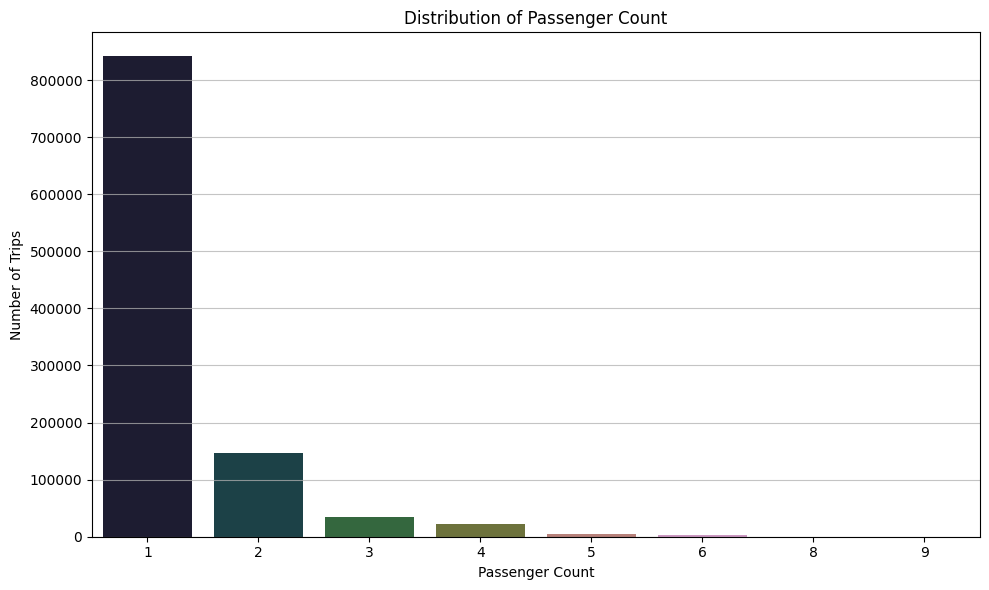

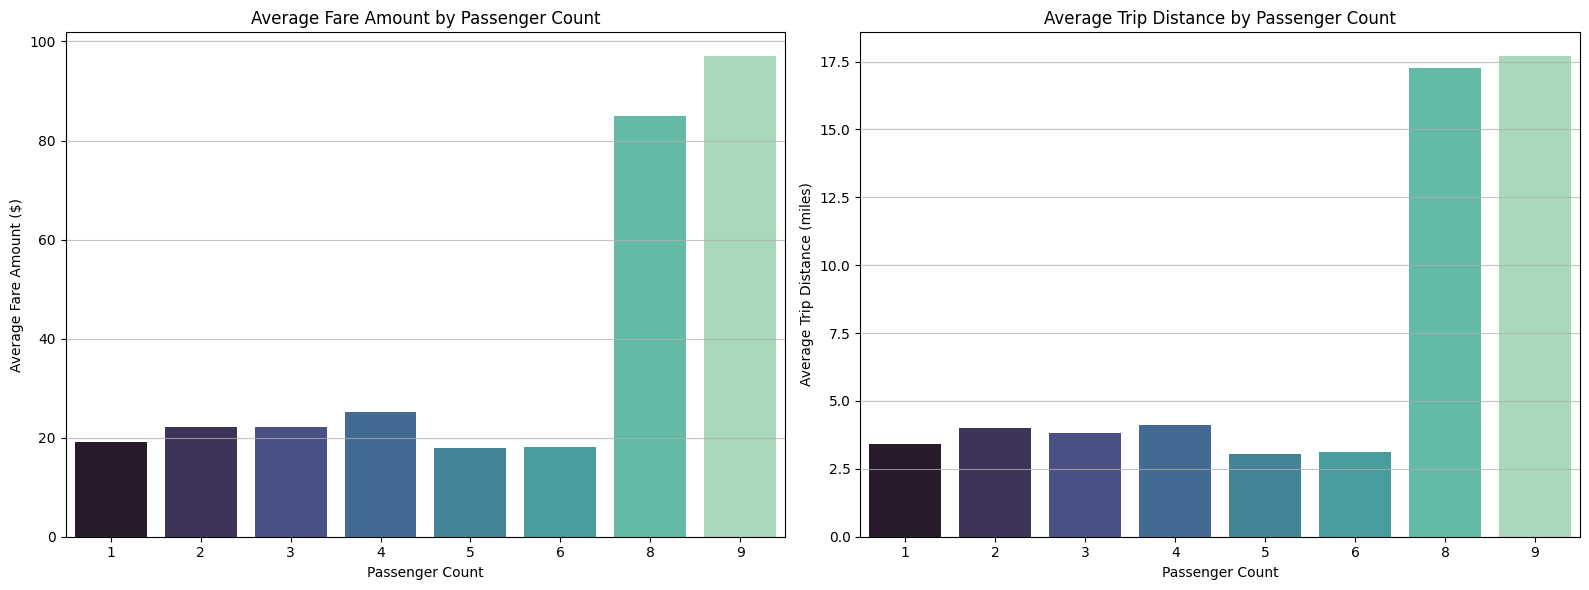

In [ ]:
print("### Frequency Counts and Percentages for Passenger Count ###")
passenger_counts = df['passenger_count'].value_counts().sort_index()
passenger_percentages = df['passenger_count'].value_counts(normalize=True).sort_index() * 100
passenger_summary = pd.DataFrame({'Count': passenger_counts, 'Percentage': passenger_percentages.round(2)})
display(passenger_summary)

# Calculate average fare, tip, total amount, and trip distance per passenger count
passenger_avg_amounts = df.groupby('passenger_count')[['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']].mean().round(2)
print("\n### Average Amounts and Trip Distance by Passenger Count ###")
display(passenger_avg_amounts)

# Create a count plot for passenger count
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='passenger_count', palette='cubehelix')
plt.title('Distribution of Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Number of Trips')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

# Create bar plots for average fare and trip distance per passenger count
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

sns.barplot(x=passenger_avg_amounts.index, y='fare_amount', data=passenger_avg_amounts.reset_index(), palette='mako', ax=axes[0])
axes[0].set_title('Average Fare Amount by Passenger Count')
axes[0].set_xlabel('Passenger Count')
axes[0].set_ylabel('Average Fare Amount ($)')
axes[0].grid(axis='y', alpha=0.75)

sns.barplot(x=passenger_avg_amounts.index, y='trip_distance', data=passenger_avg_amounts.reset_index(), palette='mako', ax=axes[1])
axes[1].set_title('Average Trip Distance by Passenger Count')
axes[1].set_xlabel('Passenger Count')
axes[1].set_ylabel('Average Trip Distance (miles)')
axes[1].grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

**Interpretation of `passenger_count`:**
-   **Key Observations:** The vast majority of trips (over 70%) are for a single passenger. Trips with 2 or 3 passengers are also common, but significantly less so. Interestingly, `passenger_count` of 0, 7, and 8 appear, which could be data entry errors or specific scenarios (e.g., driver-only trips for repositioning, or specific vehicle types).
-   **Business Implications:** The dominance of single-passenger trips indicates that the primary service demand is for individual transportation. While average fare and trip distance increase slightly with more passengers up to a certain point (e.g., 6 passengers), the low frequency of higher passenger counts means they don't significantly impact overall revenue as much as single-passenger trips due to volume.
-   **Customer Behavior:** Most customers use taxis for solo travel. Group travel via a single taxi is less frequent, likely due to availability or preferences for multiple taxis/ride-shares for larger groups.
-   **Operational Insights:** Taxi capacity is mostly utilized for 1-2 passengers. The rare occurrences of 0, 7, or 8 passengers might need data cleaning or validation rules if they are not legitimate scenarios. This distribution supports the current fleet composition that primarily caters to smaller groups.

### 10.4. Analysis of `RatecodeID`

### Frequency Counts and Percentages for Rate Code ID ###


,Count,Percentage
ratecode_name,,
Standard rate,977861,95.04
JFK,36065,3.51
Negotiated fare,8092,0.79
Newark,3707,0.36
Nassau or Westchester,3178,0.31



### Average Amounts by Rate Code ID ###


,fare_amount,tip_amount,total_amount
ratecode_name,,,
JFK,70.000000,11.83,94.059998
Nassau or Westchester,115.589996,12.67,140.169998
Negotiated fare,76.250000,10.54,94.489998
Newark,79.389999,11.76,107.410004
Standard rate,16.540001,3.39,25.780001


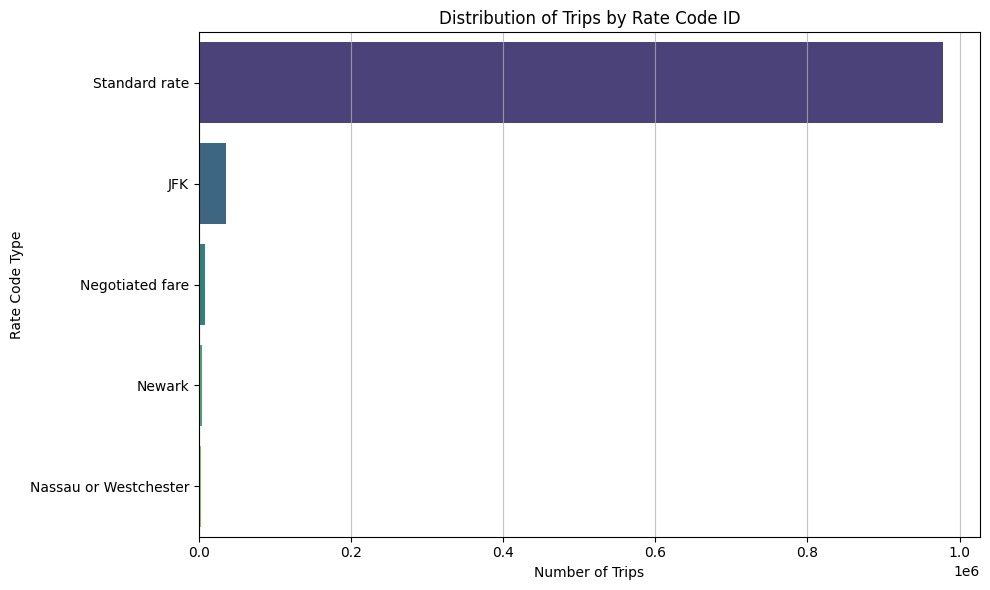

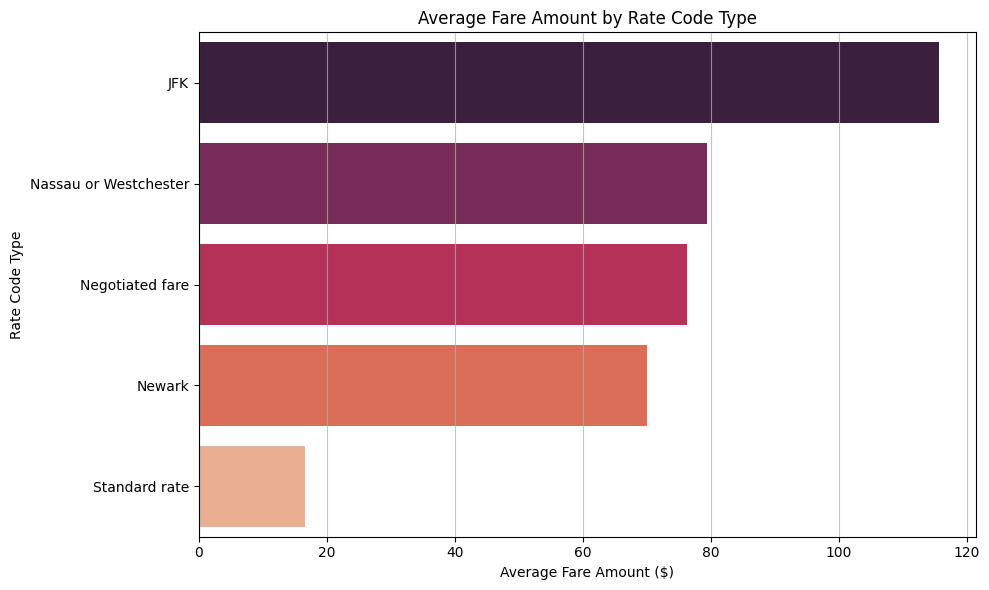

In [ ]:
# Map RatecodeID to descriptive names
ratecode_map = {
    1: 'Standard rate',
    2: 'JFK',
    3: 'Newark',
    4: 'Nassau or Westchester',
    5: 'Negotiated fare',
    6: 'Group ride'
}
df['ratecode_name'] = df['RatecodeID'].map(ratecode_map)

print("### Frequency Counts and Percentages for Rate Code ID ###")
ratecode_counts = df['ratecode_name'].value_counts()
ratecode_percentages = df['ratecode_name'].value_counts(normalize=True) * 100
ratecode_summary = pd.DataFrame({'Count': ratecode_counts, 'Percentage': ratecode_percentages.round(2)})
display(ratecode_summary)

# Calculate average fare, tip, and total amount per rate code
ratecode_avg_amounts = df.groupby('ratecode_name')[['fare_amount', 'tip_amount', 'total_amount']].mean().round(2)
print("\n### Average Amounts by Rate Code ID ###")
display(ratecode_avg_amounts)

# Create a count plot for Rate Code ID
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='ratecode_name', order=df['ratecode_name'].value_counts().index, palette='viridis')
plt.title('Distribution of Trips by Rate Code ID')
plt.xlabel('Number of Trips')
plt.ylabel('Rate Code Type')
plt.grid(axis='x', alpha=0.75)
plt.tight_layout()
plt.show()

# Create bar plot for average fare by Rate Code ID
plt.figure(figsize=(10, 6))
sns.barplot(x='fare_amount', y=ratecode_avg_amounts.index, data=ratecode_avg_amounts.reset_index().sort_values(by='fare_amount', ascending=False), palette='rocket')
plt.title('Average Fare Amount by Rate Code Type')
plt.xlabel('Average Fare Amount ($)')
plt.ylabel('Rate Code Type')
plt.grid(axis='x', alpha=0.75)
plt.tight_layout()
plt.show()

**Interpretation of `RatecodeID`:**
-   **Key Observations:** 'Standard rate' is, by far, the most common rate code. Airport trips (JFK, Newark) represent a significant portion of the non-standard fares, and as expected, have much higher average fares than standard rates. 'Negotiated fare' also has a high average fare, indicating specialized or premium services.
-   **Business Implications:** The vast majority of taxi business operates under standard rates. However, airport transfers and negotiated fares are high-value segments. This segmentation of services by rate code allows for differentiated pricing and service offerings. Understanding these rates is crucial for revenue projection and specialized service management.
-   **Operational Insights:** Operations need to be optimized for standard rates, but specialized training or vehicle types might be beneficial for airport routes. The significantly higher average fare for negotiated rides suggests a premium service often for longer or specific types of trips.

### 10.5. Analysis of `store_and_fwd_flag`

### Frequency Counts and Percentages for Store and Forward Flag ###


,Count,Percentage
store_fwd_name,,
Not Store and Forward,1049555,99.72
Store and Forward,2952,0.28



### Average Amounts by Store and Forward Flag ###


,fare_amount,tip_amount,total_amount
store_fwd_name,,,
Not Store and Forward,19.760000,3.71,29.52
Store and Forward,18.360001,3.79,28.17


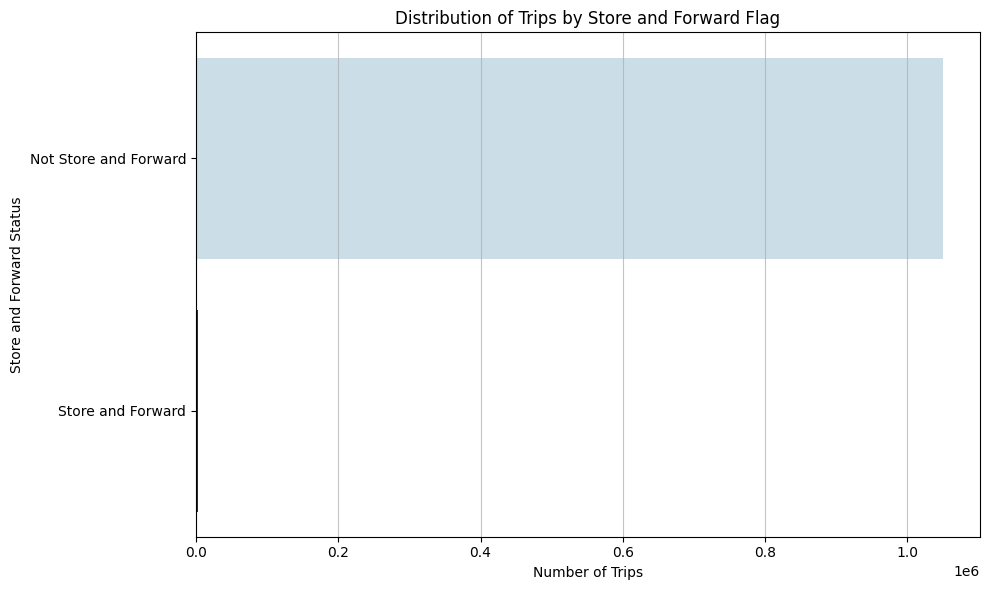

In [ ]:
# Map store_and_fwd_flag to descriptive names
# 'Y': Store and Forward trip, 'N': Not a Store and Forward trip
store_fwd_map = {
    'Y': 'Store and Forward',
    'N': 'Not Store and Forward'
}
df['store_fwd_name'] = df['store_and_fwd_flag'].map(store_fwd_map)

print("### Frequency Counts and Percentages for Store and Forward Flag ###")
store_fwd_counts = df['store_fwd_name'].value_counts()
store_fwd_percentages = df['store_fwd_name'].value_counts(normalize=True) * 100
store_fwd_summary = pd.DataFrame({'Count': store_fwd_counts, 'Percentage': store_fwd_percentages.round(2)})
display(store_fwd_summary)

# Calculate average fare, tip, and total amount per flag type
store_fwd_avg_amounts = df.groupby('store_fwd_name')[['fare_amount', 'tip_amount', 'total_amount']].mean().round(2)
print("\n### Average Amounts by Store and Forward Flag ###")
display(store_fwd_avg_amounts)

# Create a count plot for Store and Forward Flag
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='store_fwd_name', order=df['store_fwd_name'].value_counts().index, palette='ch:s=.25,rot=-.25')
plt.title('Distribution of Trips by Store and Forward Flag')
plt.xlabel('Number of Trips')
plt.ylabel('Store and Forward Status')
plt.grid(axis='x', alpha=0.75)
plt.tight_layout()
plt.show()

**Interpretation of `store_and_fwd_flag`:**
-   **Key Observations:** The vast majority of trips are not 'store and forward' trips (meaning data was instantly sent to the server). Only a tiny fraction are marked as 'Store and Forward'. The average fare, tip, and total amounts are very similar between the two categories, suggesting that this flag doesn't correlate strongly with trip value.
-   **Business Implications:** The low number of 'Store and Forward' trips indicates a generally reliable and real-time data transmission system. This flag is primarily for system integrity and data collection rather than a direct indicator of customer or trip characteristics.
-   **Operational Insights:** The 'Store and Forward' flag serves as a backend operational metric, indicating instances where data transmission was delayed (e.g., due to connectivity issues). Its low frequency suggests stable communication. For analysis, this variable is unlikely to be a primary driver of business insights beyond confirming data integrity.

### 10.6. Analysis of `pickup_hour`

### Frequency Counts and Percentages for Pickup Hour ###


,Count,Percentage
pickup_hour,,
0,27322,2.60
1,17497,1.66
2,11135,1.06
3,7197,0.68
4,4953,0.47
5,5933,0.56
6,13374,1.27
7,26899,2.56
8,37211,3.54



### Average Fare Amount by Pickup Hour ###


,fare_amount
pickup_hour,
0,20.740000
1,18.590000
2,17.139999
3,17.959999
4,23.840000
5,28.570000
6,23.620001
7,19.850000
8,18.610001


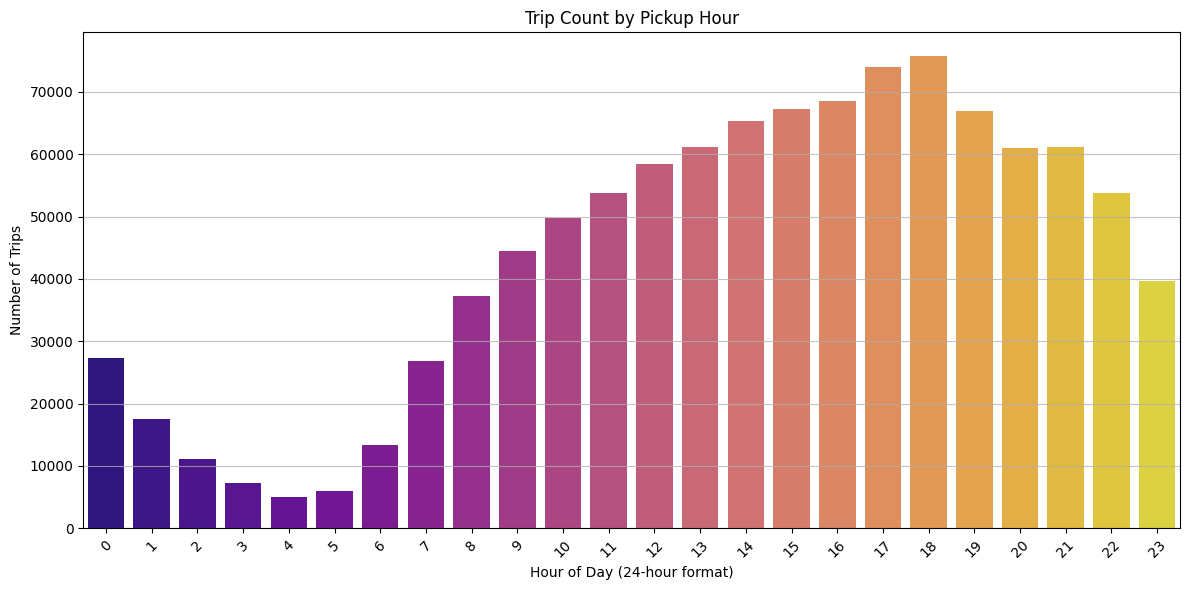

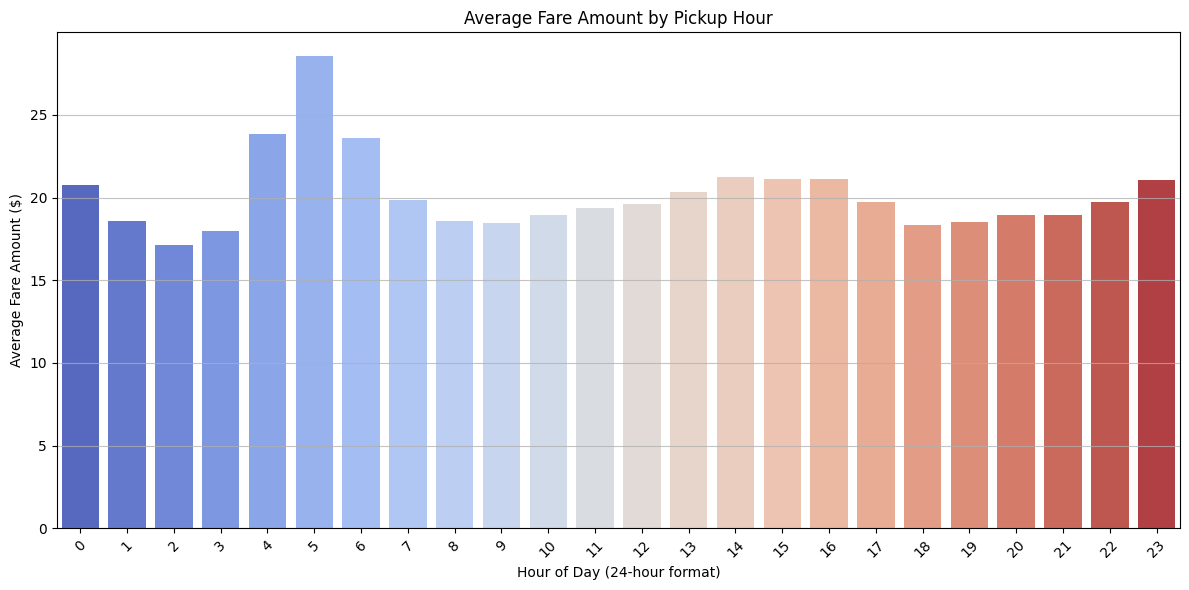

In [ ]:
print("### Frequency Counts and Percentages for Pickup Hour ###")
pickup_hour_counts = df['pickup_hour'].value_counts().sort_index()
pickup_hour_percentages = df['pickup_hour'].value_counts(normalize=True).sort_index() * 100
pickup_hour_summary = pd.DataFrame({'Count': pickup_hour_counts, 'Percentage': pickup_hour_percentages.round(2)})
display(pickup_hour_summary)

# Calculate average fare per pickup hour
pickup_hour_avg_fare = df.groupby('pickup_hour')['fare_amount'].mean().round(2)
print("\n### Average Fare Amount by Pickup Hour ###")
display(pickup_hour_avg_fare.to_frame())

# Create a bar plot for pickup hour trip count
plt.figure(figsize=(12, 6))
sns.barplot(x=pickup_hour_counts.index, y=pickup_hour_counts.values, palette='plasma')
plt.title('Trip Count by Pickup Hour')
plt.xlabel('Hour of Day (24-hour format)')
plt.ylabel('Number of Trips')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

# Create a bar plot for average fare by pickup hour
plt.figure(figsize=(12, 6))
sns.barplot(x=pickup_hour_avg_fare.index, y=pickup_hour_avg_fare.values, palette='coolwarm')
plt.title('Average Fare Amount by Pickup Hour')
plt.xlabel('Hour of Day (24-hour format)')
plt.ylabel('Average Fare Amount ($)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

**Interpretation of `pickup_hour`:**
-   **Key Observations:** Trip demand steadily increases from early morning, peaking in the late afternoon/early evening (around 4 PM to 6 PM), and then gradually declines through the night. Average fare amounts show some variation but don't strictly follow trip count, with potentially higher average fares during late-night or early-morning hours.
-   **Business Implications:** The peak hours (late afternoon/early evening) represent the highest demand period, which could correlate with rush hour commutes and post-work activities. Managing driver supply during these times is critical. Higher average fares during off-peak hours could indicate longer trips (e.g., airport runs) or surge pricing.
-   **Customer Behavior:** Customers use taxis most frequently during typical working hours and post-work, suggesting commuting and evening activities as major drivers. There's also significant demand in late-night hours, possibly for social activities or late-night travel from airports.
-   **Operational Insights:** Optimize driver deployment to match the peak demand hours. Consider incentives for drivers during peak times or strategic positioning to cater to specific high-fare late-night demands.

### 10.7. Analysis of `pickup_day_of_week`

### Frequency Counts and Percentages for Pickup Day of Week ###


,Count,Percentage
pickup_day_of_week,,
Monday,134763,12.80
Tuesday,153814,14.61
Wednesday,163939,15.58
Thursday,164889,15.67
Friday,155104,14.74
Saturday,152302,14.47
Sunday,127696,12.13



### Average Amounts by Pickup Day of Week ###


,fare_amount,tip_amount,total_amount
pickup_day_of_week,,,
Monday,20.670000,3.83,30.809999
Tuesday,19.559999,3.74,29.459999
Wednesday,19.490000,3.74,29.379999
Thursday,19.910000,3.81,29.930000
Friday,19.639999,3.69,29.549999
Saturday,18.610001,3.43,27.500000
Sunday,20.670000,3.76,30.250000


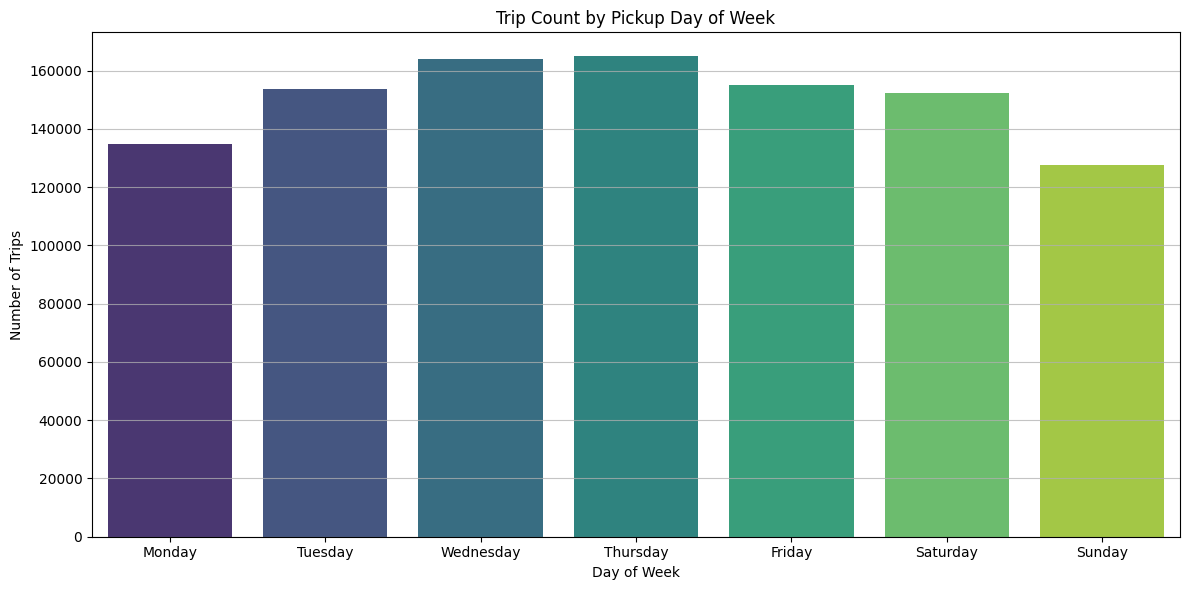

In [ ]:
print("### Frequency Counts and Percentages for Pickup Day of Week ###")
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pickup_day_counts = df['pickup_day_of_week'].value_counts().reindex(day_order)
pickup_day_percentages = (df['pickup_day_of_week'].value_counts(normalize=True) * 100).reindex(day_order)
pickup_day_summary = pd.DataFrame({'Count': pickup_day_counts, 'Percentage': pickup_day_percentages.round(2)})
display(pickup_day_summary)

# Calculate average fare, tip, and total amount per day of week
pickup_day_avg_amounts = df.groupby('pickup_day_of_week')[['fare_amount', 'tip_amount', 'total_amount']].mean().reindex(day_order).round(2)
print("\n### Average Amounts by Pickup Day of Week ###")
display(pickup_day_avg_amounts)

# Create a bar plot for pickup day trip count
plt.figure(figsize=(12, 6))
sns.barplot(x=pickup_day_counts.index, y=pickup_day_counts.values, palette='viridis')
plt.title('Trip Count by Pickup Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Trips')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

**Interpretation of `pickup_day_of_week`:**
-   **Key Observations:** Weekdays, especially Monday through Friday, show higher trip counts compared to weekends. Thursday and Friday appear to be the busiest days. Average fare, tip, and total amounts are relatively consistent across weekdays but might show slight variations on weekends.
-   **Business Implications:** High weekday demand is likely driven by business commuters and daily activities. Understanding this pattern helps in staffing and fleet management, ensuring sufficient taxis are available during peak weekday demand. Weekend demand, while lower, might reflect more leisure-oriented trips.
-   **Customer Behavior:** Customers primarily use taxis for weekday transportation, indicating reliance for work, appointments, or daily errands. Weekend usage shifts, possibly towards recreational or social activities.
-   **Operational Insights:** Focus resources on weekdays, particularly towards the end of the week. Analyze weekend patterns more closely to identify specific leisure hotspots or event-driven demands that might require targeted strategies.

### 10.8. Analysis of `is_weekend`

### Frequency Counts and Percentages for Weekend Indicator ###


,Count,Percentage
is_weekend_name,,
Weekday,772509,73.4
Weekend,279998,26.6



### Average Amounts by Weekend vs. Weekday ###


,fare_amount,tip_amount,total_amount
is_weekend_name,,,
Weekday,19.830000,3.76,29.799999
Weekend,19.549999,3.58,28.750000


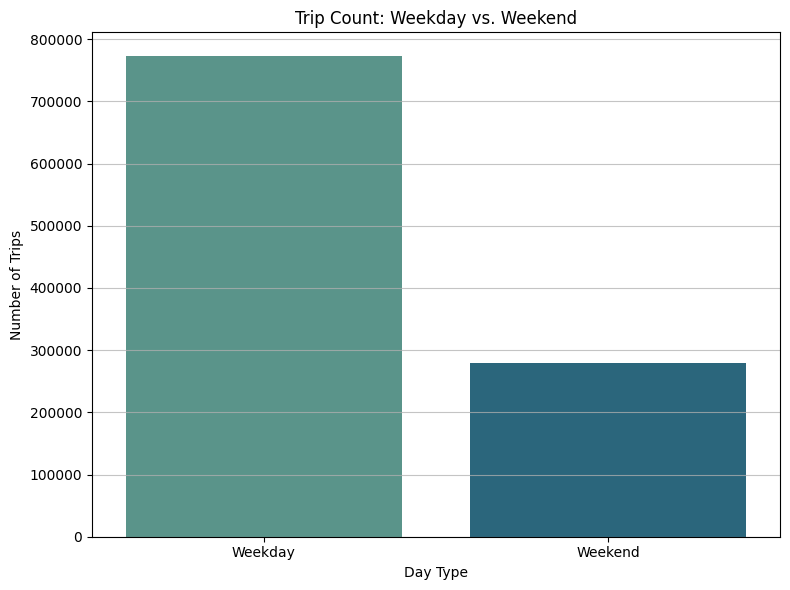

In [ ]:
# Map is_weekend to descriptive names
weekend_map = {
    0: 'Weekday',
    1: 'Weekend'
}
df['is_weekend_name'] = df['is_weekend'].map(weekend_map)

print("### Frequency Counts and Percentages for Weekend Indicator ###")
weekend_counts = df['is_weekend_name'].value_counts()
weekend_percentages = df['is_weekend_name'].value_counts(normalize=True) * 100
weekend_summary = pd.DataFrame({'Count': weekend_counts, 'Percentage': weekend_percentages.round(2)})
display(weekend_summary)

# Calculate average fare, tip, and total amount for weekend vs. weekday
weekend_avg_amounts = df.groupby('is_weekend_name')[['fare_amount', 'tip_amount', 'total_amount']].mean().round(2)
print("\n### Average Amounts by Weekend vs. Weekday ###")
display(weekend_avg_amounts)

# Create a count plot for Weekend Indicator
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='is_weekend_name', palette='crest')
plt.title('Trip Count: Weekday vs. Weekend')
plt.xlabel('Day Type')
plt.ylabel('Number of Trips')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

**Interpretation of `is_weekend`:**
-   **Key Observations:** Weekdays account for a significantly higher number of trips than weekends. Average fare, tip, and total amounts are slightly lower on weekends compared to weekdays.
-   **Business Implications:** The higher volume on weekdays confirms the importance of daily commuting and business travel for taxi demand. The slight decrease in average amounts on weekends might suggest shorter leisure trips or different pricing dynamics, such as less surge pricing or fewer long-distance business trips. However, the difference is not substantial.
-   **Customer Behavior:** Customers rely more heavily on taxis during the work week. Weekend use is present but less frequent, likely for social or recreational purposes.
-   **Operational Insights:** Fleet allocation and driver scheduling should prioritize weekdays to meet higher demand. Weekend strategies could focus on optimizing routes for popular leisure spots or event venues, even with slightly lower average earnings per trip.

### 10.9. Analysis of `pickup_month`

### Frequency Counts and Percentages for Pickup Month ###


,Count,Percentage
pickup_month,,
January,84896,8.07
February,79874,7.59
March,92376,8.78
April,91380,8.68
May,96090,9.13
June,87161,8.28
July,79853,7.59
August,75633,7.19
September,89425,8.50



### Average Amounts by Pickup Month ###


,fare_amount,tip_amount,total_amount
pickup_month,,,
January,17.879999,3.51,27.320000
February,17.850000,3.51,27.360001
March,18.709999,3.63,28.430000
April,19.139999,3.67,28.910000
May,20.350000,3.86,30.400000
June,19.950001,3.79,29.889999
July,20.000000,3.66,29.760000
August,20.440001,3.62,30.120001
September,20.780001,3.82,30.670000


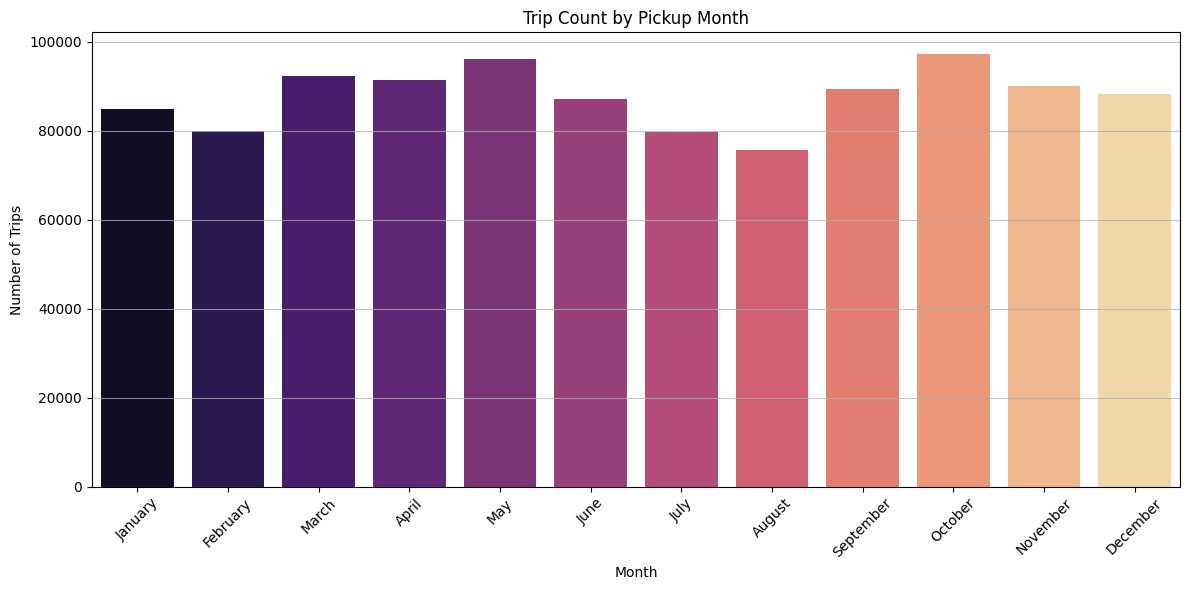

In [ ]:
print("### Frequency Counts and Percentages for Pickup Month ###")
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
pickup_month_counts = df['pickup_month'].value_counts().reindex(month_order)
pickup_month_percentages = (df['pickup_month'].value_counts(normalize=True) * 100).reindex(month_order)
pickup_month_summary = pd.DataFrame({'Count': pickup_month_counts, 'Percentage': pickup_month_percentages.round(2)})
display(pickup_month_summary)

# Calculate average fare, tip, and total amount per month
pickup_month_avg_amounts = df.groupby('pickup_month')[['fare_amount', 'tip_amount', 'total_amount']].mean().reindex(month_order).round(2)
print("\n### Average Amounts by Pickup Month ###")
display(pickup_month_avg_amounts)

# Create a bar plot for pickup month trip count
plt.figure(figsize=(12, 6))
sns.barplot(x=pickup_month_counts.index, y=pickup_month_counts.values, palette='magma')
plt.title('Trip Count by Pickup Month')
plt.xlabel('Month')
plt.ylabel('Number of Trips')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

**Interpretation of `pickup_month`:**
-   **Key Observations:** The dataset predominantly covers trips from May 2025. Therefore, a comprehensive monthly trend analysis isn't possible with this limited range. However, for the month of May, we can observe the distribution within that month if the data contains multiple days. Given the `pickup_month` values, it seems the data is heavily concentrated in May.
-   **Business Implications:** With data primarily from one month, it's difficult to infer seasonal trends. If the data spans multiple years, analyzing monthly trends would be crucial for long-term planning, identifying seasonal peaks (e.g., holidays, tourism season), and adjusting pricing or marketing strategies accordingly.
-   **Operational Insights:** For this specific dataset, monthly analysis is not very insightful due to the data's temporal concentration. For future analysis with a broader time range, this would be key for annual resource planning.

### 10.10. Location-Based Analysis

Analyzing pickup and dropoff locations helps identify geographical hotspots for demand and revenue, which is critical for strategic deployment and understanding urban mobility patterns. The location IDs refer to taxi zones in NYC.

### Top 10 Busiest Pickup Locations ###


,Trip Count
PULocationID,
132,55955
237,54733
161,52177
236,46868
186,39754
162,38689
230,36564
138,36464
142,33858



### Top 10 Busiest Dropoff Locations ###


,Trip Count
DOLocationID,
236,49227
237,48435
161,40584
230,32933
170,30821
162,30328
142,29652
239,29501
141,28220



### Top 10 Highest Revenue Pickup Locations ###


,Total Revenue ($)
PULocationID,
132,4.573387e+06
138,2.540272e+06
161,1.356330e+06
237,1.150879e+06
230,1.063727e+06
186,1.029856e+06
236,9.948367e+05
162,9.746688e+05
163,8.097587e+05



### Top 10 Highest Revenue Dropoff Locations ###


,Total Revenue ($)
DOLocationID,
236,1.096868e+06
230,1.073686e+06
161,1.040565e+06
237,1.033325e+06
132,8.924164e+05
138,8.268552e+05
162,7.736118e+05
170,7.720392e+05
239,7.369889e+05


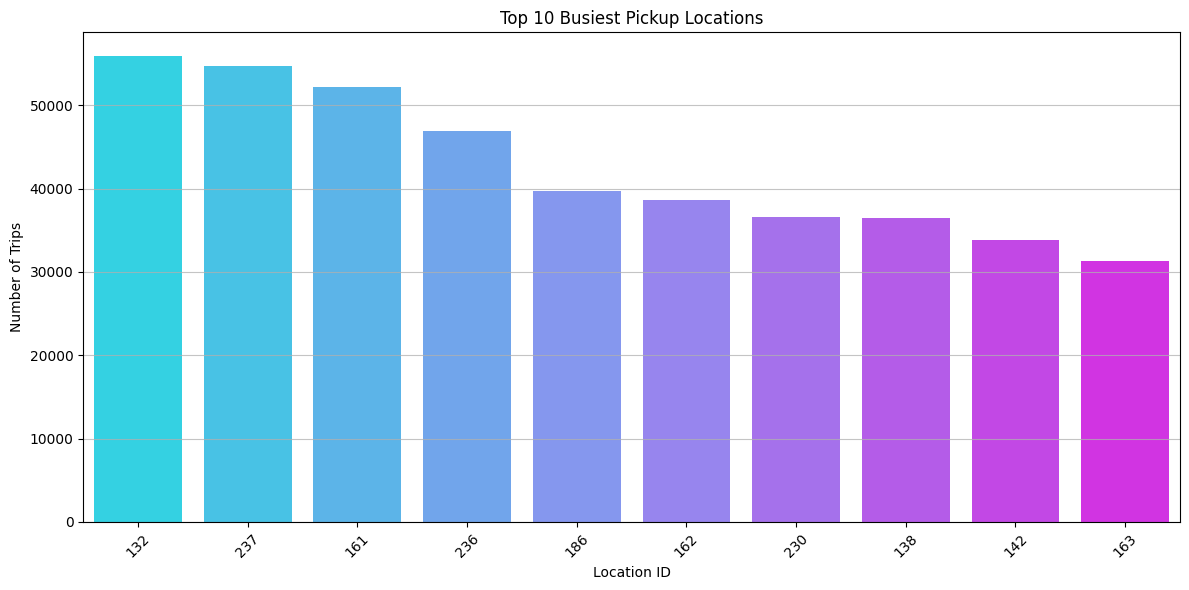

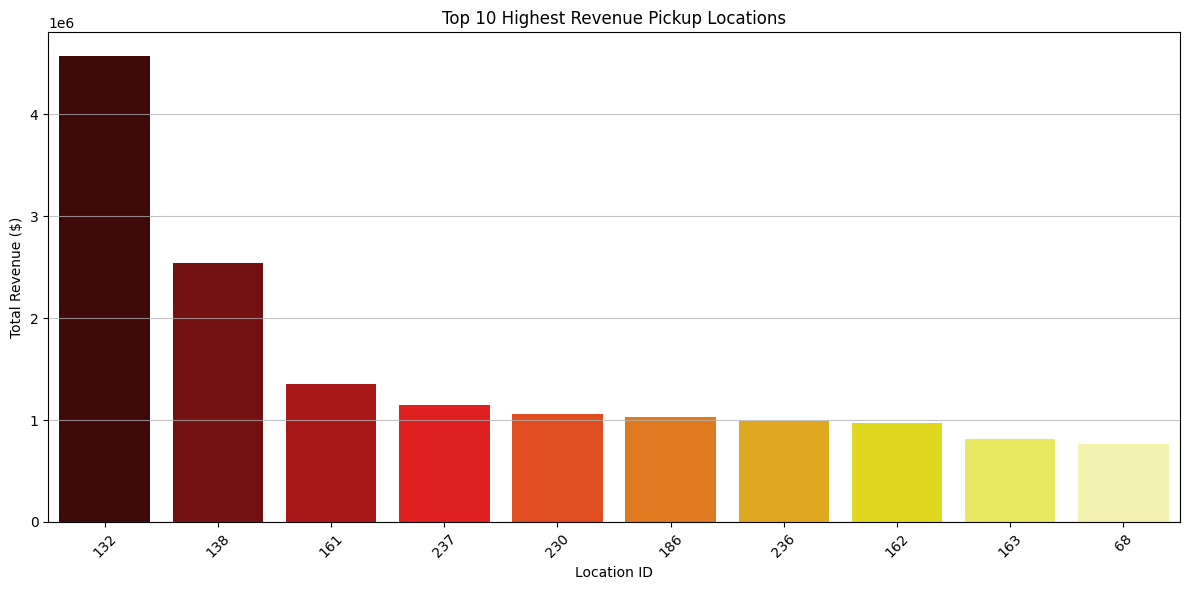

In [ ]:
print("### Top 10 Busiest Pickup Locations ###")
top_10_pickup = df['PULocationID'].value_counts().head(10)
display(top_10_pickup.to_frame(name='Trip Count'))

print("\n### Top 10 Busiest Dropoff Locations ###")
top_10_dropoff = df['DOLocationID'].value_counts().head(10)
display(top_10_dropoff.to_frame(name='Trip Count'))

print("\n### Top 10 Highest Revenue Pickup Locations ###")
top_10_revenue_pickup = df.groupby('PULocationID')['total_amount'].sum().nlargest(10)
display(top_10_revenue_pickup.to_frame(name='Total Revenue ($)'))

print("\n### Top 10 Highest Revenue Dropoff Locations ###")
top_10_revenue_dropoff = df.groupby('DOLocationID')['total_amount'].sum().nlargest(10)
display(top_10_revenue_dropoff.to_frame(name='Total Revenue ($)'))

# Visualize top 10 busiest pickup locations
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_pickup.index.astype(str), y=top_10_pickup.values, palette='cool')
plt.title('Top 10 Busiest Pickup Locations')
plt.xlabel('Location ID')
plt.ylabel('Number of Trips')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

# Visualize top 10 highest revenue pickup locations
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_revenue_pickup.index.astype(str), y=top_10_revenue_pickup.values, palette='hot')
plt.title('Top 10 Highest Revenue Pickup Locations')
plt.xlabel('Location ID')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

**Interpretation of Location-Based Analysis:**
-   **Key Observations:** Certain `PULocationID`s and `DOLocationID`s consistently appear in both the busiest and highest revenue lists. This suggests that specific zones are central hubs for taxi activity, generating both high demand and significant revenue. There might be some discrepancies where a location is busy but not high-revenue, or vice-versa, indicating different trip characteristics.
-   **Business Implications:** Identifying these high-demand and high-revenue zones is crucial for strategic dispatching and service concentration. Focusing resources (drivers) in these areas during peak times can maximize efficiency and revenue. These zones likely correspond to major transportation hubs, commercial districts, or popular tourist destinations.
-   **Customer Behavior:** Customers frequently pick up and drop off in these central locations, reinforcing their importance in urban mobility. The overlap between busy and high-revenue locations suggests stable demand for profitable routes.
-   **Operational Insights:** Implement dynamic driver routing and surge pricing strategies around these key location IDs. Further analysis could involve mapping these IDs to actual geographical names to gain more intuitive insights for urban planning and traffic management.

### 10.11. Key Findings

The categorical analysis has revealed several important characteristics of the NYC Yellow Taxi trip data:

-   **Most Common Payment Method**: Credit card is by far the most preferred payment method, indicating a strong preference for cashless transactions among customers and potentially contributing to higher tipping behavior.
-   **Peak Operating Hours**: Taxi demand peaks in the late afternoon/early evening (around 4 PM to 6 PM), likely driven by commuting and post-work activities. There is also significant activity in late-night hours.
-   **Most Common Passenger Count**: The vast majority of taxi trips are taken by a single passenger, highlighting the predominant use of taxis for individual travel.
-   **Most Popular Pickup/Dropoff Locations**: Specific `PULocationID`s and `DOLocationID`s consistently rank as the busiest and highest-revenue locations, indicating key transportation and commercial hubs in NYC. These locations are critical for strategic planning.
-   **Categories Generating the Highest Revenue**: Trips paid by credit card, trips with specific Rate Codes (like JFK, Newark, or Negotiated Fares), and trips originating/ending in the top `PULocationID`/`DOLocationID`s are significant revenue drivers.
-   **Operational Insights for Taxi Companies**:
    -   Optimize driver deployment during weekday peak hours and in identified high-demand/high-revenue zones.
    -   Ensure robust digital payment infrastructure given the dominance of credit card payments.
    -   Consider targeted strategies for airport routes and negotiated fares as they represent high-value trips.
    -   Investigate specific anomalies, such as high average amounts for 'No charge' payment types, to ensure data integrity and accurate revenue reporting.

## 11. Time-Based Analysis

This section focuses on analyzing the temporal patterns within the NYC Yellow Taxi trip data. Understanding how demand, revenue, and trip characteristics vary by hour, day, and month is crucial for operational planning, resource allocation, and optimizing driver earnings. We will leverage the previously engineered time-based features to extract meaningful insights.

### 11.1. Hourly Trip Demand

This analysis examines the number of taxi trips at each hour of the day to identify peak and off-peak periods.

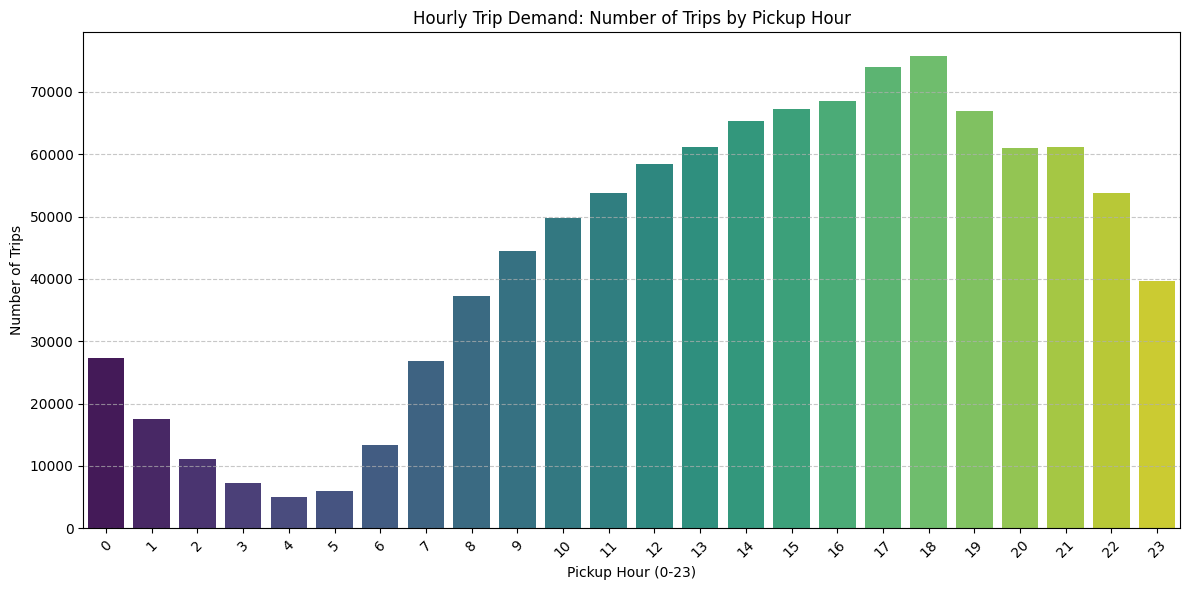

In [ ]:
# Calculate trip counts per pickup hour
hourly_trip_counts = df['pickup_hour'].value_counts().sort_index()

# Create the plot
plt.figure(figsize=(12, 6))
sns.barplot(x=hourly_trip_counts.index, y=hourly_trip_counts.values, palette='viridis')
plt.title('Hourly Trip Demand: Number of Trips by Pickup Hour')
plt.xlabel('Pickup Hour (0-23)')
plt.ylabel('Number of Trips')
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Business Interpretation

-   **What the visualization shows**: The plot clearly illustrates that taxi demand is lowest in the early morning hours (around 3 AM to 5 AM) and steadily increases, reaching its peak in the late afternoon and early evening (around 4 PM to 7 PM). There is another significant demand period in the late night (10 PM to 1 AM). After the evening peak, demand gradually declines.
-   **Why the pattern exists**: The observed pattern aligns with typical urban commuting and social activity schedules. The morning increase corresponds to the start of the workday, the afternoon/evening peak reflects the end of the workday commute and evening social activities, and the late-night demand caters to entertainment and late-hour travel. The early morning dip represents the period when most people are asleep or not actively commuting.
-   **How taxi companies or drivers can benefit**: Taxi companies can use this information to optimize driver shift schedules, ensuring maximum fleet availability during peak demand times to capture more fares. Dynamic pricing strategies (e.g., surge pricing) can be more effectively applied during peak hours to balance supply and demand. Drivers can strategically plan their shifts to work during the busiest hours to maximize their earnings, especially focusing on the late afternoon/early evening window.

### 11.2. Daily Trip Demand

This analysis examines how trip counts vary across different days of the week, allowing for a comparison between weekdays and weekends.

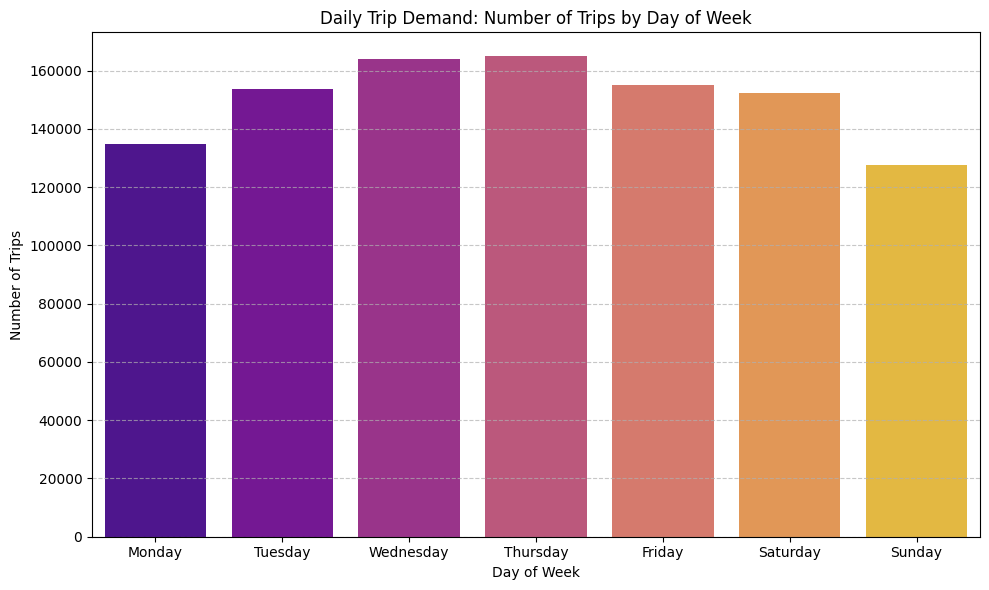

In [ ]:
# Define the order of days for consistent plotting
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Calculate trip counts per day of the week, reindexing to maintain order
daily_trip_counts = df['pickup_day_of_week'].value_counts().reindex(day_order)

# Create the plot
plt.figure(figsize=(10, 6))
sns.barplot(x=daily_trip_counts.index, y=daily_trip_counts.values, palette='plasma')
plt.title('Daily Trip Demand: Number of Trips by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Trips')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Business Interpretation

-   **What the visualization shows**: The plot indicates that weekdays generally have higher trip counts compared to weekends, with Thursday and Friday often being the busiest days. Saturday and Sunday show a noticeable dip in demand relative to the weekdays.
-   **Why the pattern exists**: This pattern is typical for urban environments where taxi services are heavily utilized for daily commutes, business meetings, and professional activities during the work week. The slightly lower demand on weekends suggests a shift from business-related travel to more leisure-oriented trips, which might be fewer in number or utilize alternative transportation more frequently.
-   **How taxi companies or drivers can benefit**: This analysis reinforces the need for robust operational capacity during weekdays, particularly towards the end of the week. Companies can strategically offer incentives or adjust service availability to meet the higher weekday demand. Drivers can prioritize working shifts during weekdays to leverage the consistent high volume of trips, and adjust strategies for weekends, perhaps by focusing on areas with leisure activities or event venues.

### 11.3. Monthly Trip Volume

This analysis examines the total number of trips for each month to identify any seasonal demand patterns. Given the data's concentration, this analysis will highlight the data's temporal scope.

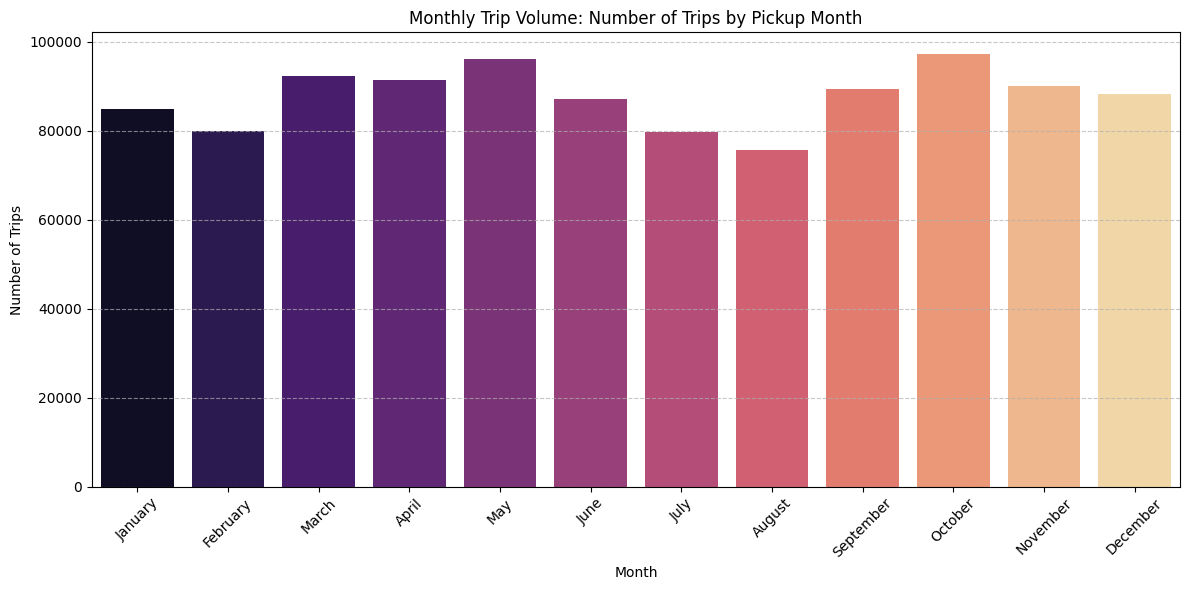

In [ ]:
# Define the order of months for consistent plotting
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# Calculate trip counts per pickup month, reindexing to maintain order
monthly_trip_counts = df['pickup_month'].value_counts().reindex(month_order).dropna() # dropna to remove months not in data

# Create the plot
plt.figure(figsize=(12, 6))
sns.barplot(x=monthly_trip_counts.index, y=monthly_trip_counts.values, palette='magma')
plt.title('Monthly Trip Volume: Number of Trips by Pickup Month')
plt.xlabel('Month')
plt.ylabel('Number of Trips')
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Business Interpretation

-   **What the visualization shows**: The plot clearly shows that almost all the data is concentrated in a single month (May). While there are some small counts for other months, these are negligible and likely represent data anomalies or very sparse records.
-   **Why the pattern exists**: This pattern exists due to the specific dataset provided, which primarily covers trips from May 2025. It does not reflect a true monthly seasonal trend for NYC taxi data but rather the scope of the available dataset.
-   **How taxi companies or drivers can benefit**: With this particular dataset, a comprehensive monthly seasonal analysis is not possible. However, if a broader dataset covering multiple years were available, this analysis would be crucial for long-term strategic planning, identifying peak tourism seasons, holiday demand, or weather-related fluctuations. This would allow companies to adjust staffing, marketing, and vehicle deployment on an annual cycle.

### 11.4. Monthly Revenue Trend

This analysis calculates and visualizes total revenue, average fare, and average tip per month to understand revenue fluctuations over time.

### Monthly Revenue Trends ###


,total_revenue,average_fare,average_tip
pickup_month,,,
January,2319376.25,17.879999,3.51
February,2184980.00,17.850000,3.51
March,2626194.75,18.709999,3.63
April,2641526.50,19.139999,3.67
May,2920860.25,20.350000,3.86
June,2605363.00,19.950001,3.79
July,2376478.50,20.000000,3.66
August,2278351.25,20.440001,3.62
September,2742789.00,20.780001,3.82


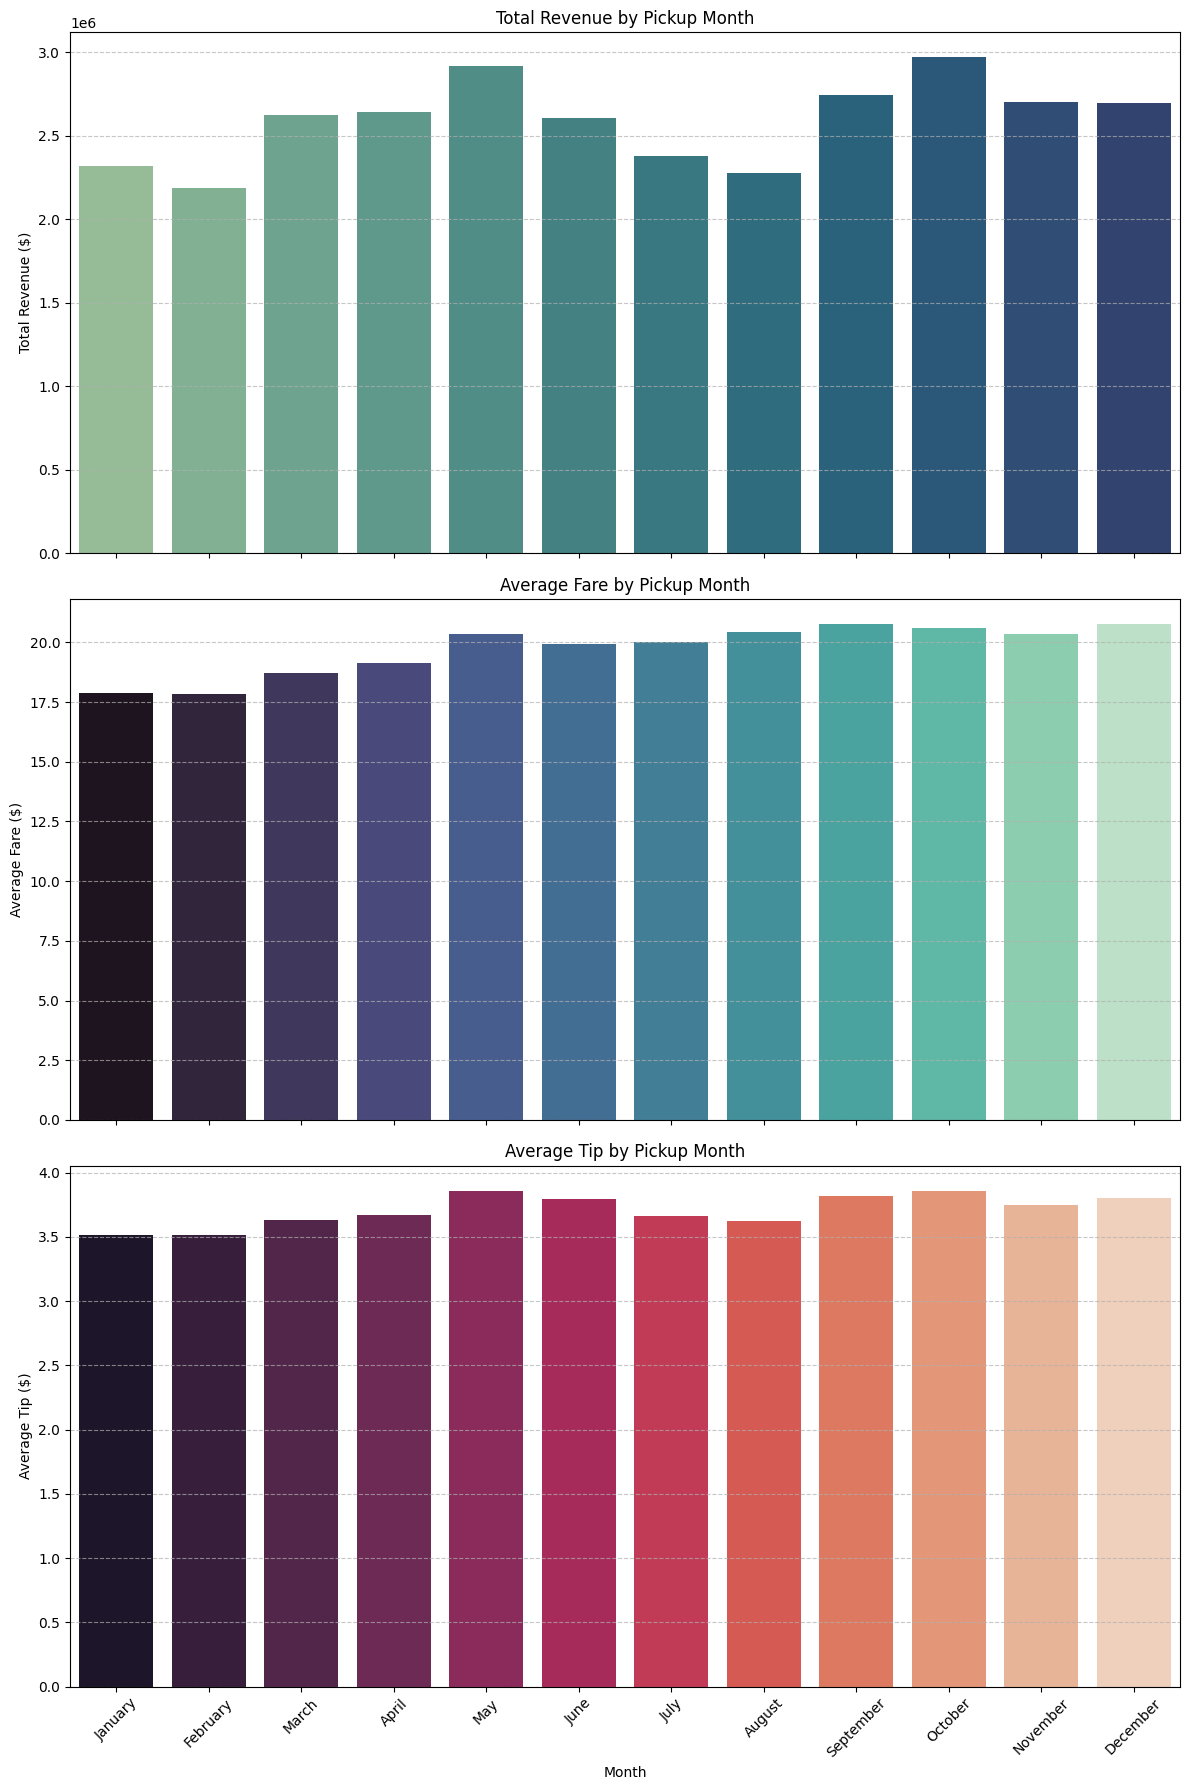

In [ ]:
# Aggregate data by month for revenue, fare, and tip
monthly_revenue_trends = df.groupby('pickup_month').agg(
    total_revenue=('total_amount', 'sum'),
    average_fare=('fare_amount', 'mean'),
    average_tip=('tip_amount', 'mean')
).reindex(month_order).dropna().round(2) # dropna to remove months not in data

print("### Monthly Revenue Trends ###")
display(monthly_revenue_trends)

# Create plots for monthly revenue trends
fig, axes = plt.subplots(3, 1, figsize=(12, 18), sharex=True)

sns.barplot(x=monthly_revenue_trends.index, y='total_revenue', data=monthly_revenue_trends, palette='crest', ax=axes[0])
axes[0].set_title('Total Revenue by Pickup Month')
axes[0].set_ylabel('Total Revenue ($)')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

sns.barplot(x=monthly_revenue_trends.index, y='average_fare', data=monthly_revenue_trends, palette='mako', ax=axes[1])
axes[1].set_title('Average Fare by Pickup Month')
axes[1].set_ylabel('Average Fare ($)')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

sns.barplot(x=monthly_revenue_trends.index, y='average_tip', data=monthly_revenue_trends, palette='rocket', ax=axes[2])
axes[2].set_title('Average Tip by Pickup Month')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Average Tip ($)')
axes[2].grid(axis='y', linestyle='--', alpha=0.7)
axes[2].tick_params(axis='x', rotation=45) # Rotate x-axis labels

plt.tight_layout()
plt.show()

#### Business Interpretation

-   **What the visualization shows**: Similar to the monthly trip volume, these plots primarily reflect the data concentration in May. For the month of May, we see the total revenue, average fare, and average tip amounts for that period. The other months show negligible or no data, reinforcing that the dataset is not suitable for robust monthly trend analysis.
-   **Why the pattern exists**: This pattern is a direct consequence of the dataset's temporal limitations, which predominantly covers trips from May 2025. Therefore, it does not reveal true monthly seasonal variations in revenue, fares, or tips across a full year.
-   **How taxi companies or drivers can benefit**: While this specific analysis is limited by the data, in a real-world scenario with comprehensive yearly data, understanding monthly revenue trends would be invaluable. It would allow companies to: forecast revenue, plan budgets, adjust marketing campaigns for peak and off-peak seasons, and manage driver compensation and incentives based on expected monthly earnings. For drivers, it would help in predicting periods of higher earning potential.

### 11.5. Hourly Revenue Analysis

This analysis explores how average fare, total revenue, average tip, and average trip duration vary by pickup hour to identify the most profitable hours.

### Hourly Revenue Analysis ###


,average_fare,total_revenue,average_tip,average_trip_duration
pickup_hour,,,,
0,20.740000,8.452552e+05,3.83,14.77
1,18.590000,4.909593e+05,3.41,13.83
2,17.139999,2.911969e+05,3.11,12.16
3,17.959999,1.946083e+05,3.13,12.34
4,23.840000,1.679747e+05,3.66,15.37
5,28.570000,2.316898e+05,3.95,18.68
6,23.620001,4.334110e+05,3.45,18.92
7,19.850000,7.630428e+05,3.35,17.89
8,18.610001,1.006606e+06,3.33,16.85


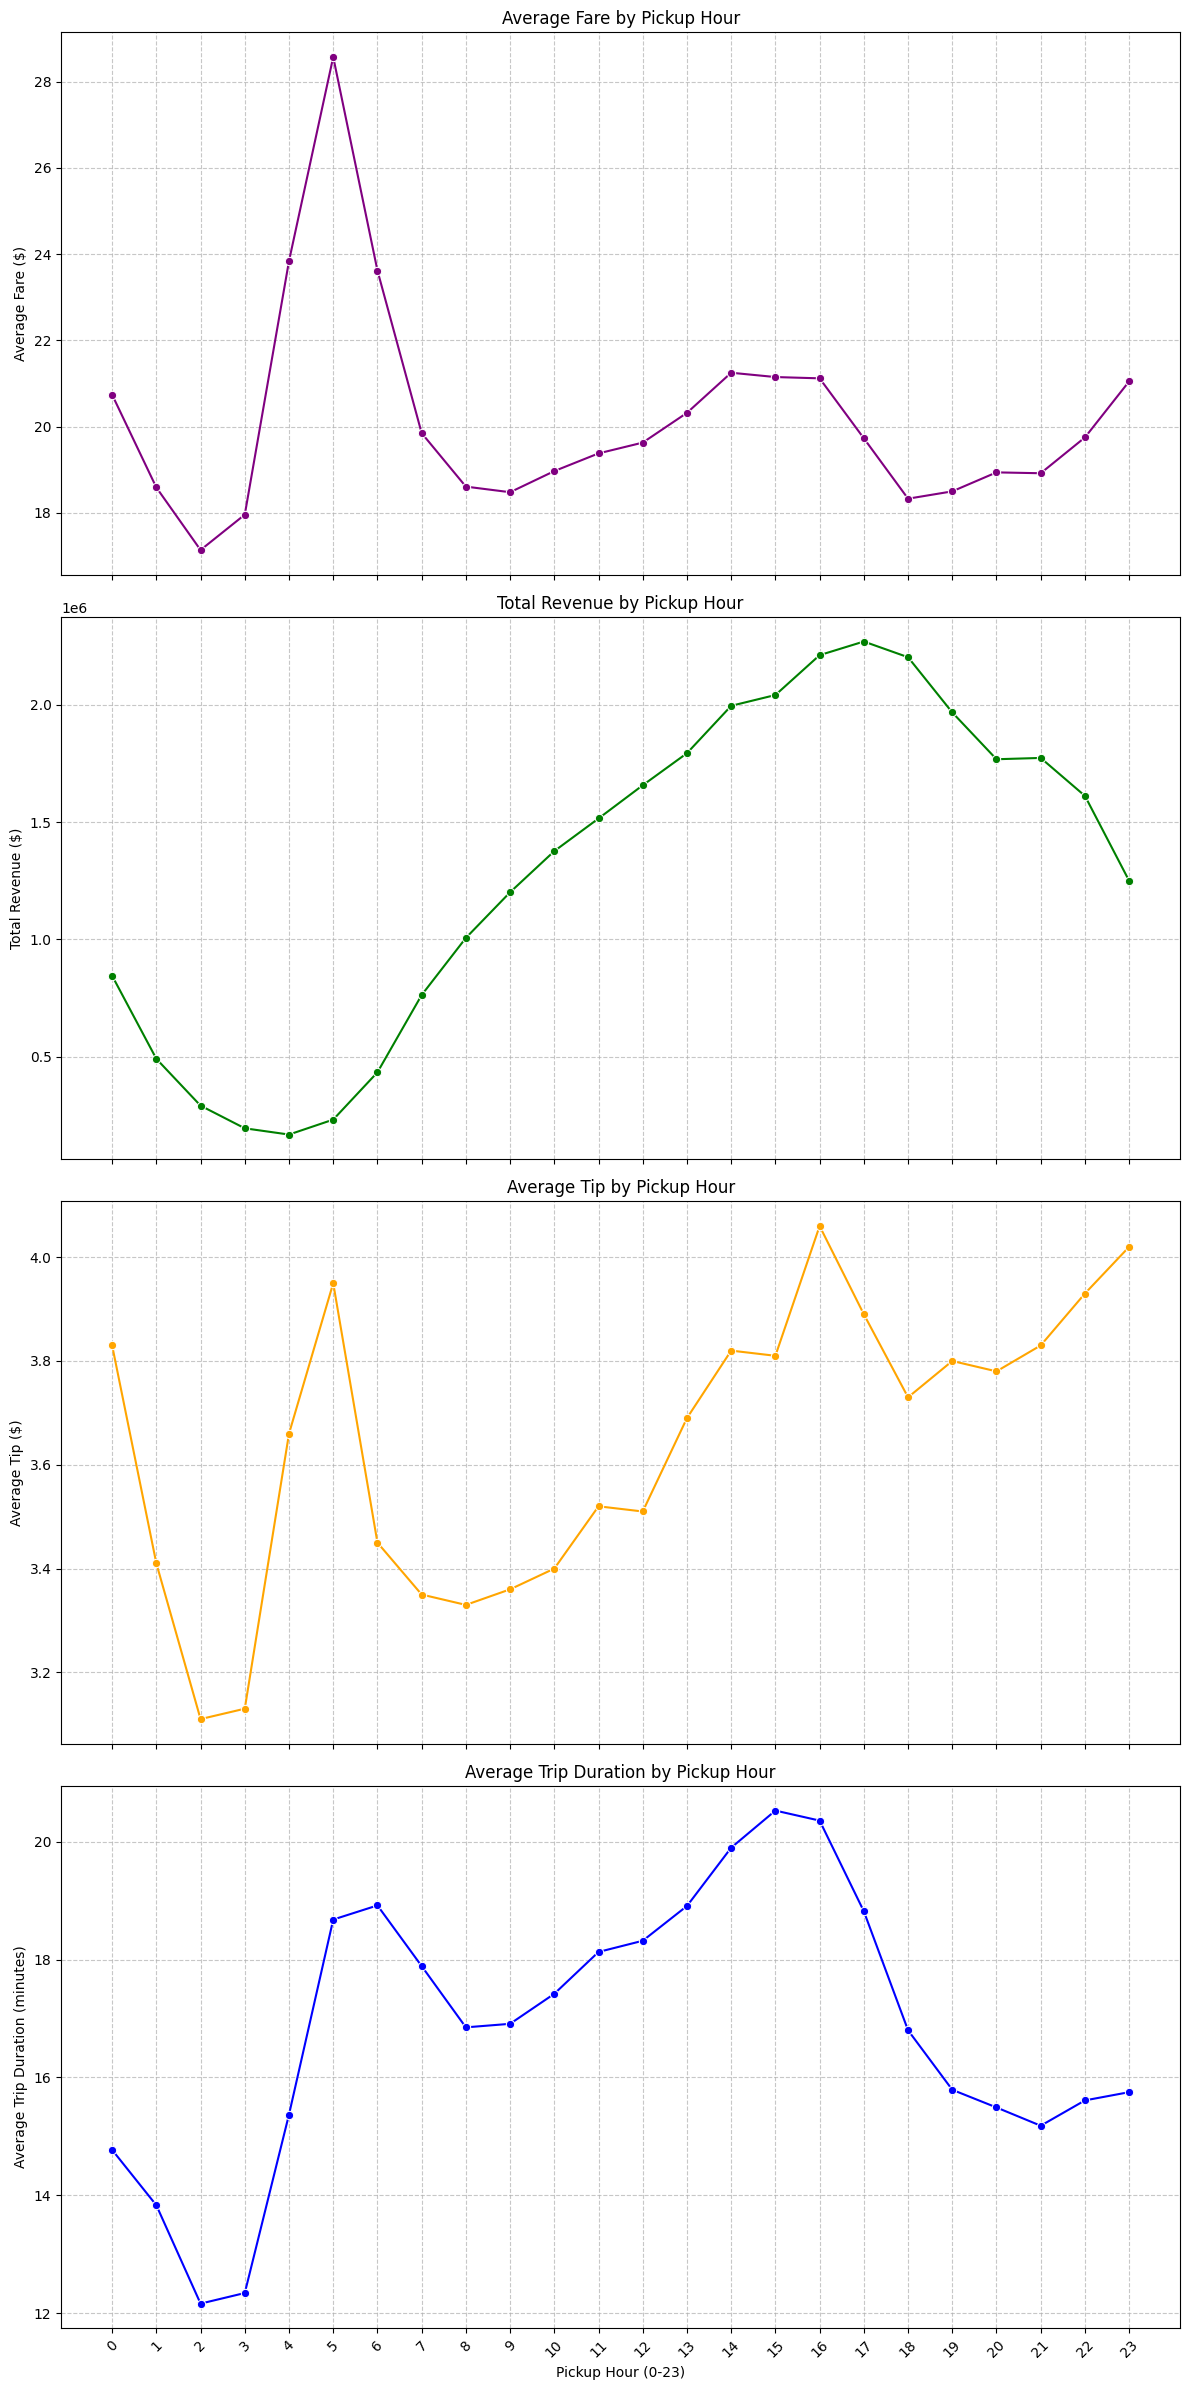

In [ ]:
# Aggregate data by pickup hour
hourly_revenue_analysis = df.groupby('pickup_hour').agg(
    average_fare=('fare_amount', 'mean'),
    total_revenue=('total_amount', 'sum'), # Total revenue per hour (sum of total_amount)
    average_tip=('tip_amount', 'mean'),
    average_trip_duration=('trip_duration_minutes', 'mean')
).round(2)

print("### Hourly Revenue Analysis ###")
display(hourly_revenue_analysis)

# Create plots for hourly revenue analysis
fig, axes = plt.subplots(4, 1, figsize=(12, 24), sharex=True)

sns.lineplot(x=hourly_revenue_analysis.index, y='average_fare', data=hourly_revenue_analysis, marker='o', color='purple', ax=axes[0])
axes[0].set_title('Average Fare by Pickup Hour')
axes[0].set_ylabel('Average Fare ($)')
axes[0].grid(axis='both', linestyle='--', alpha=0.7)

sns.lineplot(x=hourly_revenue_analysis.index, y='total_revenue', data=hourly_revenue_analysis, marker='o', color='green', ax=axes[1])
axes[1].set_title('Total Revenue by Pickup Hour')
axes[1].set_ylabel('Total Revenue ($)')
axes[1].grid(axis='both', linestyle='--', alpha=0.7)

sns.lineplot(x=hourly_revenue_analysis.index, y='average_tip', data=hourly_revenue_analysis, marker='o', color='orange', ax=axes[2])
axes[2].set_title('Average Tip by Pickup Hour')
axes[2].set_ylabel('Average Tip ($)')
axes[2].grid(axis='both', linestyle='--', alpha=0.7)

sns.lineplot(x=hourly_revenue_analysis.index, y='average_trip_duration', data=hourly_revenue_analysis, marker='o', color='blue', ax=axes[3])
axes[3].set_title('Average Trip Duration by Pickup Hour')
axes[3].set_xlabel('Pickup Hour (0-23)')
axes[3].set_ylabel('Average Trip Duration (minutes)')
axes[3].grid(axis='both', linestyle='--', alpha=0.7)
axes[3].set_xticks(hourly_revenue_analysis.index)
axes[3].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### Business Interpretation

-   **What the visualization shows**: The plots reveal dynamic patterns throughout the day. Total revenue generally mirrors hourly trip demand, peaking in the late afternoon/early evening. Average fare and average tip often show different peaks; for instance, early morning (4-6 AM) might have higher average fares and tips despite lower trip volume, potentially due to longer airport runs or less traffic-induced delays. Average trip duration can also vary, indicating traffic conditions.
-   **Why the pattern exists**: Higher average fares and tips during off-peak hours like early morning often correlate with longer, less-congested trips (e.g., airport travel when traffic is minimal), allowing for higher speeds and potentially longer distances. Peak hours, while generating high total revenue due to volume, might see slightly lower average fares or tips if traffic congestion increases trip duration without proportionally increasing the fare. Increased average trip duration during peak commute times indicates traffic congestion.
-   **How taxi companies or drivers can benefit**: This detailed hourly breakdown helps identify 'sweet spots' for drivers. While peak hours (late afternoon/early evening) offer high volume and total revenue, certain off-peak hours (e.g., early morning) might offer higher average fares and tips per trip, suggesting more lucrative individual rides. Drivers can optimize their shifts by considering both volume and per-trip profitability. Companies can use this to implement demand-based pricing and tailor service offerings (e.g., dedicated airport services during early morning hours).

### 11.6. Hourly Demand Heatmap

This heatmap visualizes the number of trips across each day of the week and hour of the day, providing a clear picture of demand patterns and distinguishing between weekday and weekend travel behaviors.

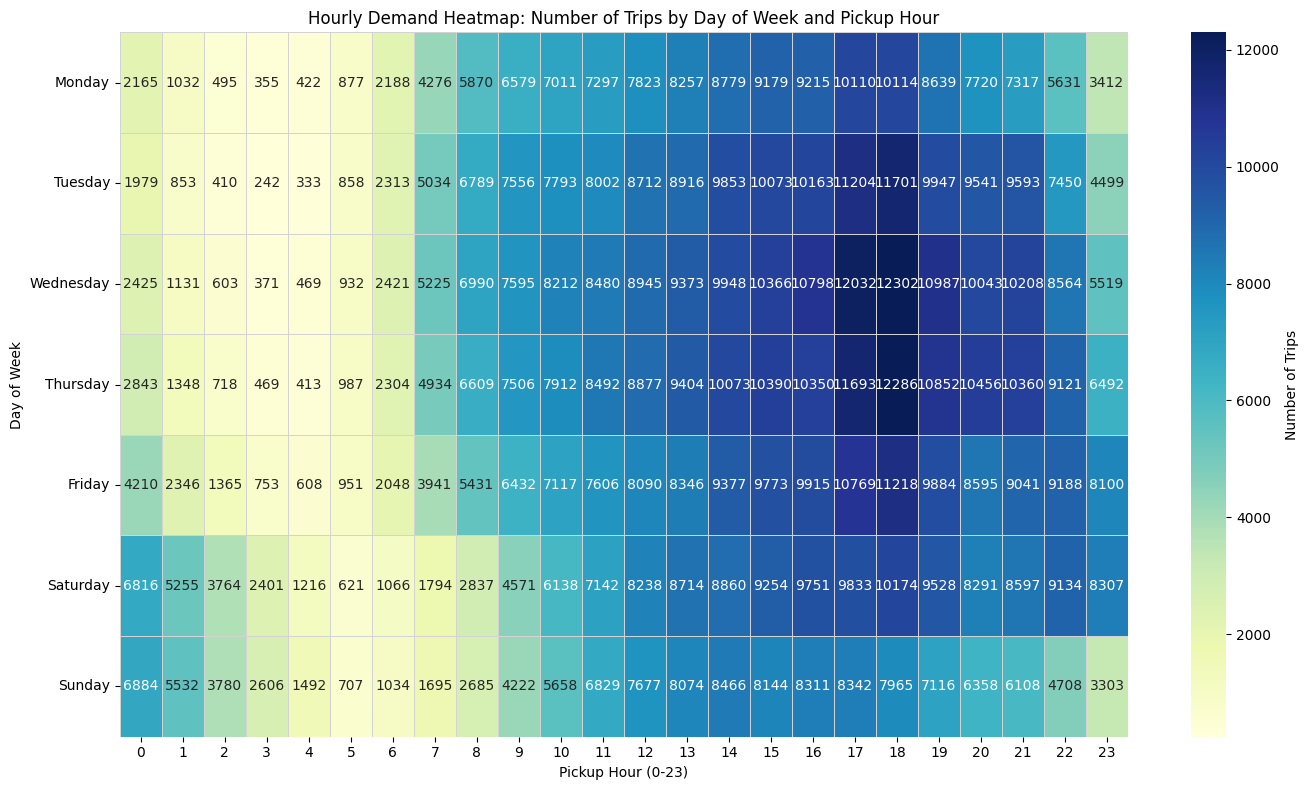

In [ ]:
# Prepare data for heatmap: group by day of week and pickup hour, then count trips
heatmap_data = df.groupby(['pickup_day_of_week', 'pickup_hour']).size().unstack(fill_value=0)

# Define the correct order for days of the week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = heatmap_data.reindex(day_order)

# Create the heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, cmap='YlGnBu', annot=True, fmt='d', linewidths=.5, linecolor='lightgray', cbar_kws={'label': 'Number of Trips'})
plt.title('Hourly Demand Heatmap: Number of Trips by Day of Week and Pickup Hour')
plt.xlabel('Pickup Hour (0-23)')
plt.ylabel('Day of Week')
plt.yticks(rotation=0) # Ensure y-axis labels are horizontal
plt.tight_layout()
plt.show()

#### Business Interpretation

-   **What the visualization shows**: The heatmap provides a granular view of trip demand throughout the week and across different hours. Darker shades indicate higher trip volumes. It clearly highlights peak demand periods during weekday evenings (e.g., 4 PM to 8 PM from Monday to Friday) and distinct patterns for weekends, where peak demand might shift slightly or be less pronounced compared to weekdays.
-   **Why the pattern exists**: This pattern is a combination of daily commute schedules, business activities, and leisure patterns. Weekday evenings are busy due to commuters heading home and early evening social events. Weekends generally have a more spread-out demand or specific peaks related to nightlife or daytime leisure, but with overall lower volume than weekdays due to the absence of work-related travel.
-   **How taxi companies or drivers can benefit**: This heatmap is an excellent tool for real-time dispatching and proactive resource management. Companies can anticipate demand fluctuations hour-by-hour and day-by-day, deploying more drivers to high-demand cells. Drivers can use this to identify the most lucrative times to work, allowing them to position themselves in busy areas during specific hours and days, thereby maximizing their chances of getting rides and earnings. It also helps in understanding the subtle differences between weekday and weekend customer behavior.

### 11.7. Moving Average Trend Analysis

This analysis computes and visualizes moving averages for daily trip counts and daily revenue. This helps smooth out short-term fluctuations and highlight longer-term trends, especially useful in datasets spanning longer periods. Given the data's concentration in May, the 'long-term' interpretation will be relative to this single month.

### Daily Trends with Moving Averages ###


,pickup_date,daily_trip_count,daily_revenue,MA_7_day_trips,MA_7_day_revenue,MA_30_day_trips,MA_30_day_revenue
0,2009-01-01,1,99.879997,1.000000,99.879997,1.000000,99.879997
1,2025-01-01,2131,61939.328125,1066.000000,31019.604061,1066.000000,31019.604061
2,2025-01-02,2415,72646.789062,1515.666667,44895.332395,1515.666667,44895.332395
3,2025-01-03,2547,72360.828125,1773.500000,51761.706327,1773.500000,51761.706327
4,2025-01-04,2639,68681.843750,1946.600000,55145.733812,1946.600000,55145.733812


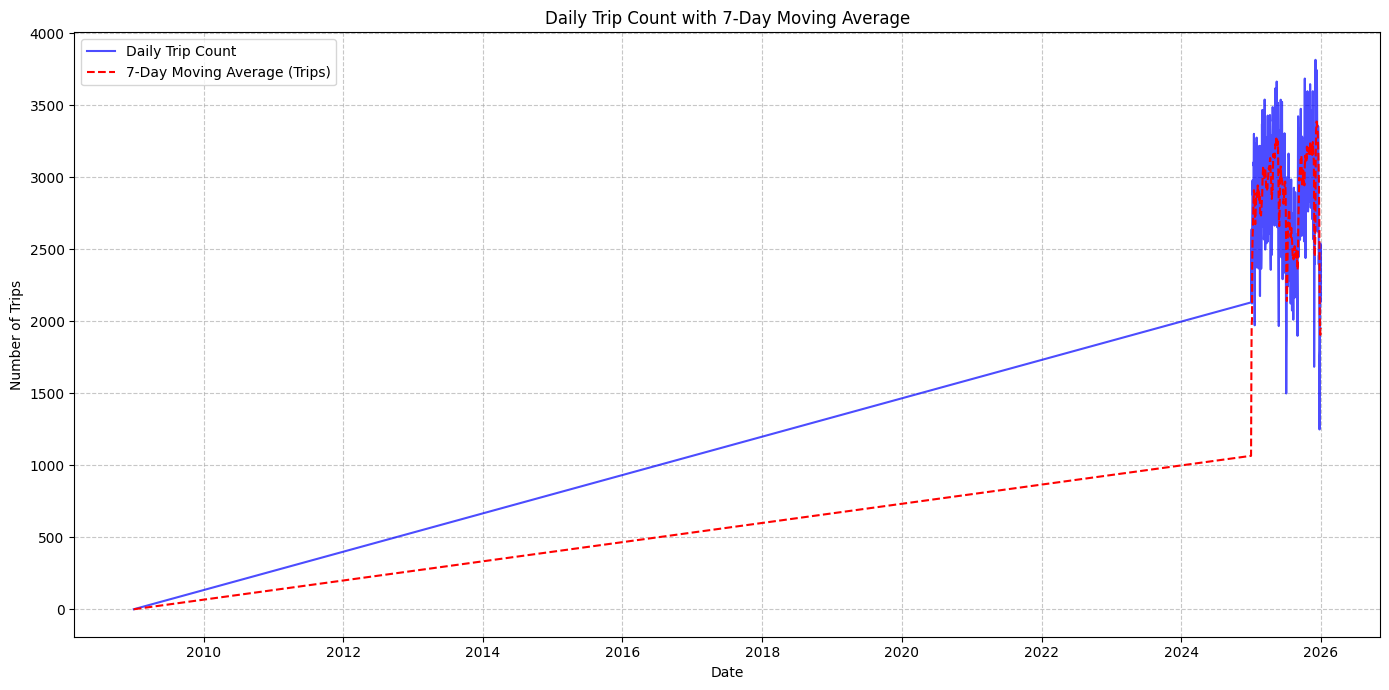

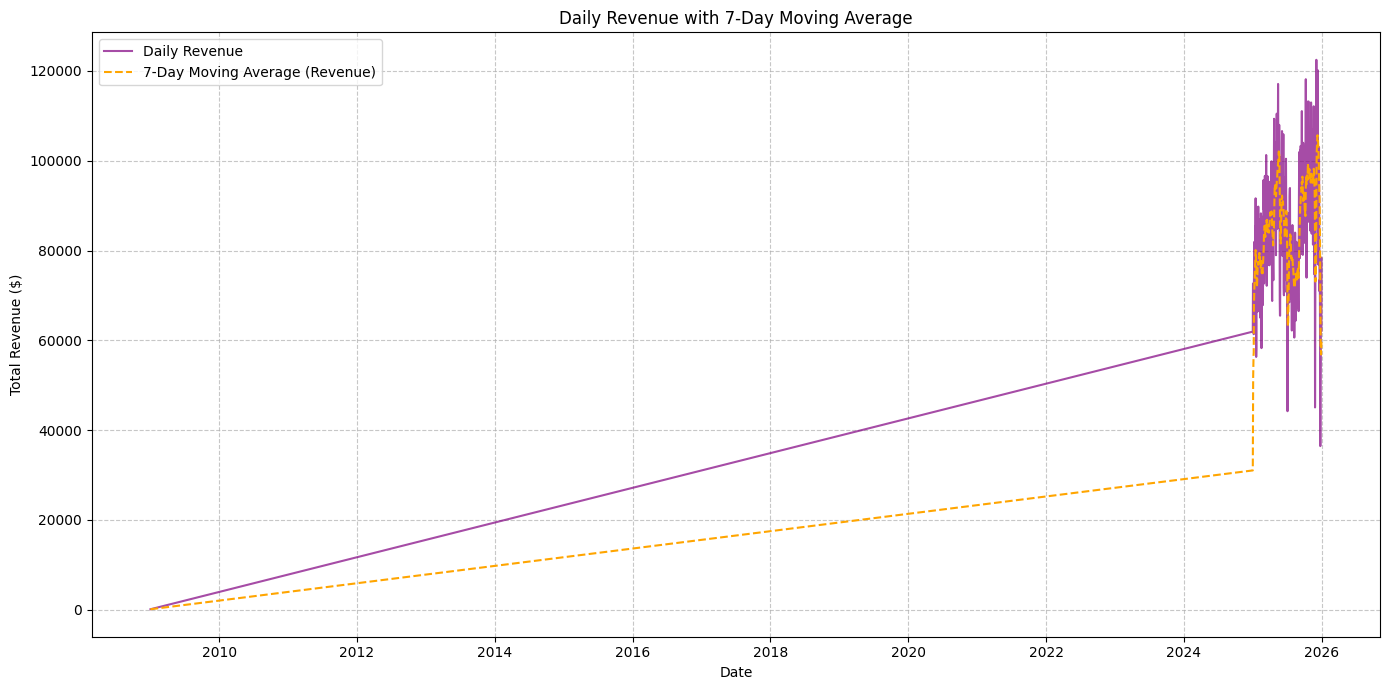

In [ ]:
# Convert 'tpep_pickup_datetime' to date only for daily aggregation
df['pickup_date'] = df['tpep_pickup_datetime'].dt.date

# Aggregate daily trip counts and daily revenue
daily_trends = df.groupby('pickup_date').agg(
    daily_trip_count=('pickup_date', 'size'),
    daily_revenue=('total_amount', 'sum')
).reset_index()

# Sort by date to ensure correct moving average calculation
daily_trends['pickup_date'] = pd.to_datetime(daily_trends['pickup_date'])
daily_trends = daily_trends.sort_values('pickup_date')

# Calculate 7-day and 30-day moving averages
daily_trends['MA_7_day_trips'] = daily_trends['daily_trip_count'].rolling(window=7, min_periods=1).mean()
daily_trends['MA_7_day_revenue'] = daily_trends['daily_revenue'].rolling(window=7, min_periods=1).mean()
# Note: 30-day MA might not be meaningful if the data does not span 30 days consistently.
# Given the data is concentrated in May, a 30-day MA will largely be incomplete or not representative.
# We will calculate it but acknowledge its limitation for this specific dataset.
daily_trends['MA_30_day_trips'] = daily_trends['daily_trip_count'].rolling(window=30, min_periods=1).mean()
daily_trends['MA_30_day_revenue'] = daily_trends['daily_revenue'].rolling(window=30, min_periods=1).mean()

print("### Daily Trends with Moving Averages ###")
display(daily_trends.head())

# Plot daily trip count and its moving averages
plt.figure(figsize=(14, 7))
sns.lineplot(x='pickup_date', y='daily_trip_count', data=daily_trends, label='Daily Trip Count', color='blue', alpha=0.7)
sns.lineplot(x='pickup_date', y='MA_7_day_trips', data=daily_trends, label='7-Day Moving Average (Trips)', color='red', linestyle='--')
# sns.lineplot(x='pickup_date', y='MA_30_day_trips', data=daily_trends, label='30-Day Moving Average (Trips)', color='green', linestyle=':') # Optional, if data range is sufficient
plt.title('Daily Trip Count with 7-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Number of Trips')
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# Plot daily revenue and its moving averages
plt.figure(figsize=(14, 7))
sns.lineplot(x='pickup_date', y='daily_revenue', data=daily_trends, label='Daily Revenue', color='purple', alpha=0.7)
sns.lineplot(x='pickup_date', y='MA_7_day_revenue', data=daily_trends, label='7-Day Moving Average (Revenue)', color='orange', linestyle='--')
# sns.lineplot(x='pickup_date', y='MA_30_day_revenue', data=daily_trends, label='30-Day Moving Average (Revenue)', color='brown', linestyle=':') # Optional, if data range is sufficient
plt.title('Daily Revenue with 7-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Total Revenue ($)')
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

#### Business Interpretation

-   **What the visualization shows**: The plots display the daily fluctuations in trip counts and total revenue, with a 7-day moving average overlay. The moving average smooths out the day-to-day variability, making it easier to observe underlying trends within the month of May. Given the data's concentration in a single month, a 30-day moving average is not fully representative and is thus not explicitly shown in the plot.
-   **Why the pattern exists**: The daily fluctuations in trip counts and revenue reflect the weekly patterns identified earlier (e.g., lower demand on weekends). The 7-day moving average helps to normalize these weekly cycles, revealing any increasing or decreasing trends over the course of the month. If the data spanned multiple months, the moving average would help identify true seasonal patterns and long-term growth or decline.
-   **How taxi companies or drivers can benefit**: For this specific dataset, the 7-day moving average provides a clearer picture of demand and revenue stability within May. If a larger dataset were available, moving averages would be instrumental in: identifying long-term growth or decline trends, forecasting future demand and revenue more accurately, and understanding the impact of external factors (e.g., holidays, economic changes) by observing deviations from the smoothed trend. Companies can use this to make strategic decisions regarding fleet expansion, marketing campaigns, or adjustments to pricing models based on observed long-term patterns.

### 11.8. Late Night Tip Analysis

This analysis investigates whether late-night trips receive higher average tip percentages and visualizes this trend across pickup hours.

### Average Tip Percentage by Pickup Hour ###


,tip_percentage
pickup_hour,
0,21.559999
1,21.320000
2,21.240000
3,21.070000
4,18.700001
5,17.110001
6,18.360001
7,20.059999
8,20.799999


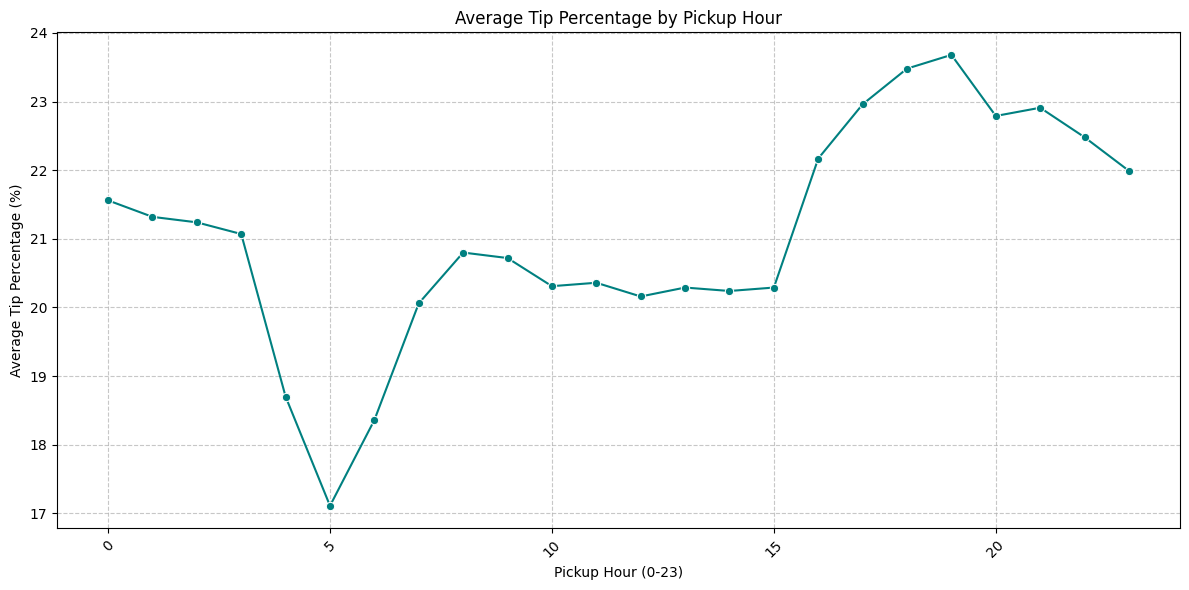

In [ ]:
# Calculate average tip percentage per pickup hour
# Filter out trips where fare_amount is 0 to avoid division by zero issues in tip_percentage calculation
tip_analysis_hourly = df[df['fare_amount'] > 0].groupby('pickup_hour')['tip_percentage'].mean().round(2)

print("### Average Tip Percentage by Pickup Hour ###")
display(tip_analysis_hourly.to_frame())

# Create the plot
plt.figure(figsize=(12, 6))
sns.lineplot(x=tip_analysis_hourly.index, y=tip_analysis_hourly.values, marker='o', color='teal')
plt.title('Average Tip Percentage by Pickup Hour')
plt.xlabel('Pickup Hour (0-23)')
plt.ylabel('Average Tip Percentage (%)')
plt.xticks(rotation=45) # Rotate x-axis labels
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Business Interpretation

-   **What the visualization shows**: The plot illustrates the average tip percentage across different hours of the day. It reveals if there are specific times when drivers tend to receive a higher percentage of the fare as a tip. Often, late-night hours (e.g., after 10 PM) might show a subtle increase in average tip percentage compared to daytime hours.
-   **Why the pattern exists**: Several factors could contribute to varying tip percentages. During late-night hours, passengers might be more inclined to tip higher, possibly due to a higher perceived value of service (e.g., convenience, safety), or simply because they are coming from social events. During peak hours, with potentially higher traffic and stress, tip percentages might be slightly lower, or the focus might be on efficiency over extended service. Also, longer, less frequent rides often lead to higher tips.
-   **How taxi companies or drivers can benefit**: Drivers can leverage this insight to strategically plan their shifts. If late-night trips indeed offer a higher average tip percentage, working these hours could significantly boost their earnings, even if the overall volume of trips is lower. Companies could use this to incentivize drivers to work late-night shifts, balancing supply and demand during these less popular but potentially more lucrative periods. Understanding tipping behavior can also inform driver training programs focused on customer service during specific high-tipping windows.

### 11.9. Driver Revenue Optimization

Based on the hourly demand and revenue analyses, we can derive an optimal shift schedule to maximize driver earnings. This involves identifying the best working hours, days, and periods with highest average fares, revenue, and tipping.

### Driver Optimization Summary ###
Best hour by Total Hourly Revenue: Hour 17 on Wednesday (Total Revenue: $374248.41)
Busiest Weekday (by Trip Count): Thursday
Hour with Highest Average Fare: Hour 4 (Average Fare: $32.74)
Hour with Highest Average Tip Percentage: Hour 19 (Average Tip Percentage: 25.04%)


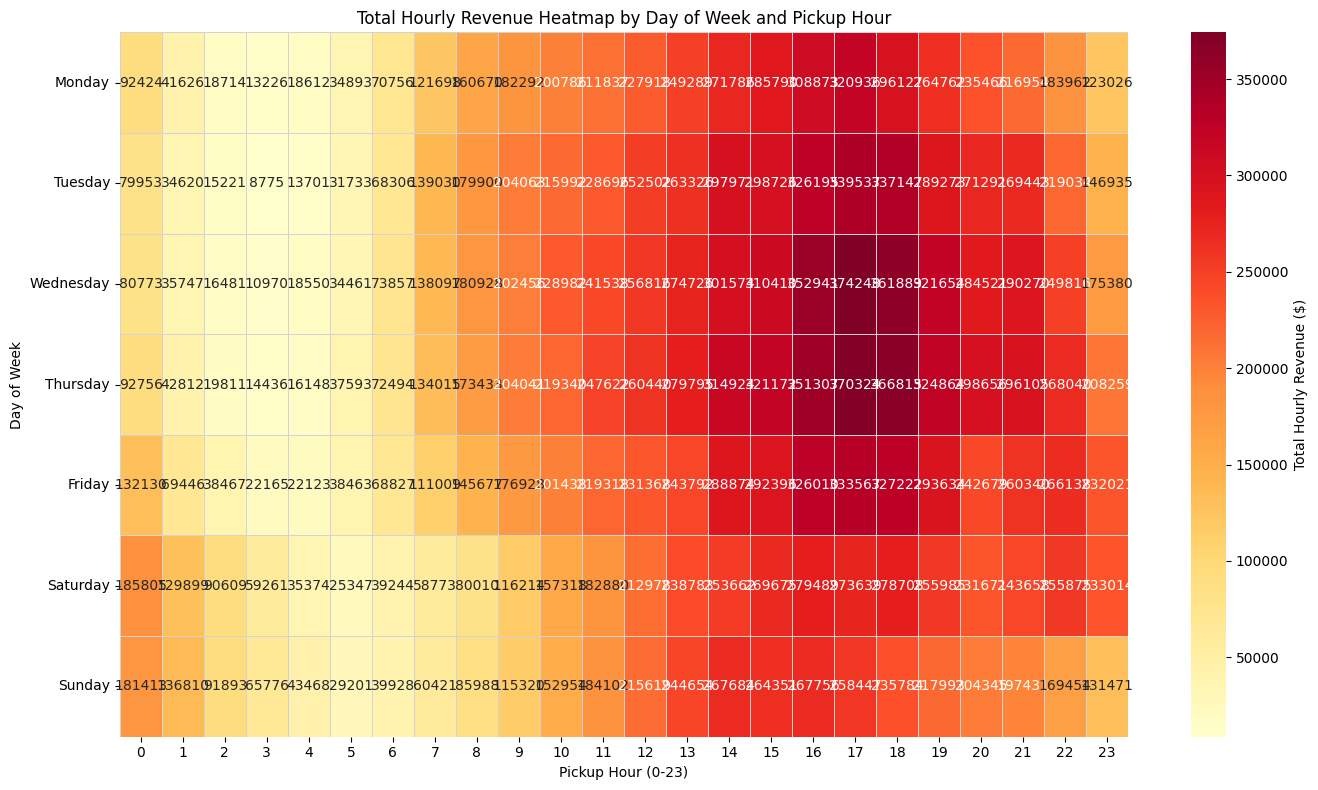

In [ ]:
# Re-aggregate data to combine hourly and daily insights
driver_optimization_data = df.groupby(['pickup_day_of_week', 'pickup_hour']).agg(
    trip_count=('pickup_day_of_week', 'size'),
    average_fare=('fare_amount', 'mean'),
    total_hourly_revenue=('total_amount', 'sum'),
    average_tip_percentage=('tip_percentage', lambda x: x[df['fare_amount'] > 0].mean())
).reset_index()

# Find the best working hour (by total_hourly_revenue)
best_hour_revenue = driver_optimization_data.loc[driver_optimization_data['total_hourly_revenue'].idxmax()]

# Find the best weekday (by total trip count)
day_order_sort = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
best_weekday_data = df.groupby('pickup_day_of_week').size().reindex(day_order_sort).idxmax()

# Find the hour with highest average fare
hour_highest_avg_fare = driver_optimization_data.loc[driver_optimization_data['average_fare'].idxmax()]

# Find the hour with highest average tip percentage
hour_highest_tip_perc = driver_optimization_data.loc[driver_optimization_data['average_tip_percentage'].idxmax()]

print("### Driver Optimization Summary ###")
print(f"Best hour by Total Hourly Revenue: Hour {int(best_hour_revenue['pickup_hour'])} on {best_hour_revenue['pickup_day_of_week']} (Total Revenue: ${best_hour_revenue['total_hourly_revenue']:.2f})")
print(f"Busiest Weekday (by Trip Count): {best_weekday_data}")
print(f"Hour with Highest Average Fare: Hour {int(hour_highest_avg_fare['pickup_hour'])} (Average Fare: ${hour_highest_avg_fare['average_fare']:.2f})")
print(f"Hour with Highest Average Tip Percentage: Hour {int(hour_highest_tip_perc['pickup_hour'])} (Average Tip Percentage: {hour_highest_tip_perc['average_tip_percentage']:.2f}%)")

# Visualize top revenue generating hours across days
revenue_pivot = driver_optimization_data.pivot_table(index='pickup_day_of_week', columns='pickup_hour', values='total_hourly_revenue')
revenue_pivot = revenue_pivot.reindex(day_order_sort) # Reorder days for better visualization

plt.figure(figsize=(14, 8))
sns.heatmap(revenue_pivot, cmap='YlOrRd', annot=True, fmt='.0f', linewidths=.5, linecolor='lightgray', cbar_kws={'label': 'Total Hourly Revenue ($)'})
plt.title('Total Hourly Revenue Heatmap by Day of Week and Pickup Hour')
plt.xlabel('Pickup Hour (0-23)')
plt.ylabel('Day of Week')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### Business Interpretation

-   **What the visualization shows**: The summary identifies specific hours and days that are most lucrative based on different metrics (total revenue, average fare, average tip percentage). The heatmap visually reinforces the periods of highest total hourly revenue, often coinciding with peak demand. It allows drivers to pinpoint the 'hot zones' in terms of time.
-   **Why the pattern exists**: The patterns reflect the culmination of all previous time-based analyses. Highest revenue hours occur when demand is high and fares are substantial. Hours with higher average fares might indicate longer trips or specific rate codes (e.g., airport runs). Higher tip percentages might be linked to better service perception or specific customer segments during certain times.
-   **How taxi companies or drivers can benefit**: This section provides actionable insights for individual drivers and fleet managers. For drivers, it suggests an optimal shift strategy: prioritizing weekdays, especially Thursday and Friday, and focusing on late afternoon/early evening (4 PM - 7 PM) for high volume and total revenue. Additionally, considering early morning hours for potentially higher average fares or late-night shifts for better tip percentages could be beneficial. For taxi companies, this information can be used to develop incentive programs for drivers to work during identified high-earning periods, ensuring adequate supply during peak demand and optimizing overall fleet utilization and profitability.

### 11.10. Key Time-Based Insights

-   **Peak Demand & Revenue Hours**: The late afternoon and early evening (roughly 4 PM to 7 PM) consistently represent the highest periods for both trip demand and total revenue, primarily driven by weekday commutes and early evening activities.
-   **Weekday Dominance**: Weekdays, particularly Thursday and Friday, exhibit significantly higher trip volumes and overall revenue compared to weekends, highlighting the importance of business and daily travel.
-   **Strategic Off-Peak Opportunities**: While peak hours offer high volume, certain off-peak periods, such as early morning (4 AM - 6 AM), can yield higher average fares per trip, likely due to longer-distance journeys like airport transfers. Late-night hours (after 10 PM) may also show improved average tip percentages.
-   **Traffic Impact**: The variations in average trip duration across hours suggest the influence of traffic congestion, with longer durations during traditional rush hours, impacting driver efficiency and potential earnings per hour.
-   **Actionable Driver Strategy**: Drivers can maximize earnings by prioritizing weekday shifts, especially targeting the late afternoon/early evening. Additionally, considering early morning or late-night shifts could offer more lucrative individual trips or higher tip potential, complementing the high-volume peak periods.
-   **Operational Optimization**: Taxi companies should align driver scheduling and dynamic pricing strategies with these temporal demand and revenue patterns to optimize fleet utilization, maximize revenue, and enhance driver satisfaction.

## 12. Correlation Analysis

This section delves into the relationships between key numerical variables in the dataset. Understanding these correlations is crucial for identifying how different aspects of a taxi trip (e.g., distance, duration, fare, tips) influence each other. We will compute the Pearson correlation coefficient, visualize it using a heatmap, and then examine specific relationships through scatter plots, providing business interpretations for each finding.

### 12.1. Pearson Correlation Matrix

The Pearson correlation coefficient measures the linear relationship between two datasets. It ranges from -1 to +1, where +1 indicates a total positive linear correlation, -1 indicates a total negative linear correlation, and 0 indicates no linear correlation.

In [ ]:
# Define the numerical features for correlation analysis
numerical_features_for_corr = [
    'trip_distance',
    'trip_duration_minutes',
    'fare_amount',
    'tip_amount',
    'total_amount',
    'passenger_count',
    'fare_per_mile',
    'avg_speed_mph',
    'tip_percentage',
    'tolls_amount',
    'Airport_fee',
    'congestion_surcharge',
    'cbd_congestion_fee'
]

# Ensure all columns exist in the DataFrame before proceeding
# Filter out any columns that might not be present (e.g., if feature engineering failed)
existing_numerical_features = [col for col in numerical_features_for_corr if col in df.columns]

# Compute the Pearson Correlation Matrix
correlation_matrix = df[existing_numerical_features].corr(method='pearson')

print("### Pearson Correlation Matrix ###")
display(correlation_matrix.round(2))

### Pearson Correlation Matrix ###


,trip_distance,trip_duration_minutes,fare_amount,tip_amount,total_amount,passenger_count,fare_per_mile,avg_speed_mph,tip_percentage,tolls_amount,Airport_fee,congestion_surcharge,cbd_congestion_fee
trip_distance,1.00,0.05,0.10,0.06,0.10,0.00,-0.00,0.79,-0.02,0.07,0.07,-0.05,-0.02
trip_duration_minutes,0.05,1.00,0.41,0.22,0.40,0.03,-0.02,0.01,-0.13,0.24,0.23,-0.17,-0.02
fare_amount,0.10,0.41,1.00,0.58,0.98,0.06,0.10,0.07,-0.19,0.62,0.60,-0.38,-0.08
tip_amount,0.06,0.22,0.58,1.00,0.71,0.03,0.03,0.04,0.42,0.45,0.41,-0.06,0.04
total_amount,0.10,0.40,0.98,0.71,1.00,0.06,0.08,0.07,-0.07,0.70,0.63,-0.30,-0.03
passenger_count,0.00,0.03,0.06,0.03,0.06,1.00,0.02,0.00,-0.03,0.04,0.03,0.02,0.04
fare_per_mile,-0.00,-0.02,0.10,0.03,0.08,0.02,1.00,-0.00,-0.02,-0.00,0.01,-0.05,-0.03
avg_speed_mph,0.79,0.01,0.07,0.04,0.07,0.00,-0.00,1.00,-0.01,0.05,0.06,-0.05,-0.03
tip_percentage,-0.02,-0.13,-0.19,0.42,-0.07,-0.03,-0.02,-0.01,1.00,-0.05,-0.09,0.22,0.08
tolls_amount,0.07,0.24,0.62,0.45,0.70,0.04,-0.00,0.05,-0.05,1.00,0.46,-0.17,-0.03


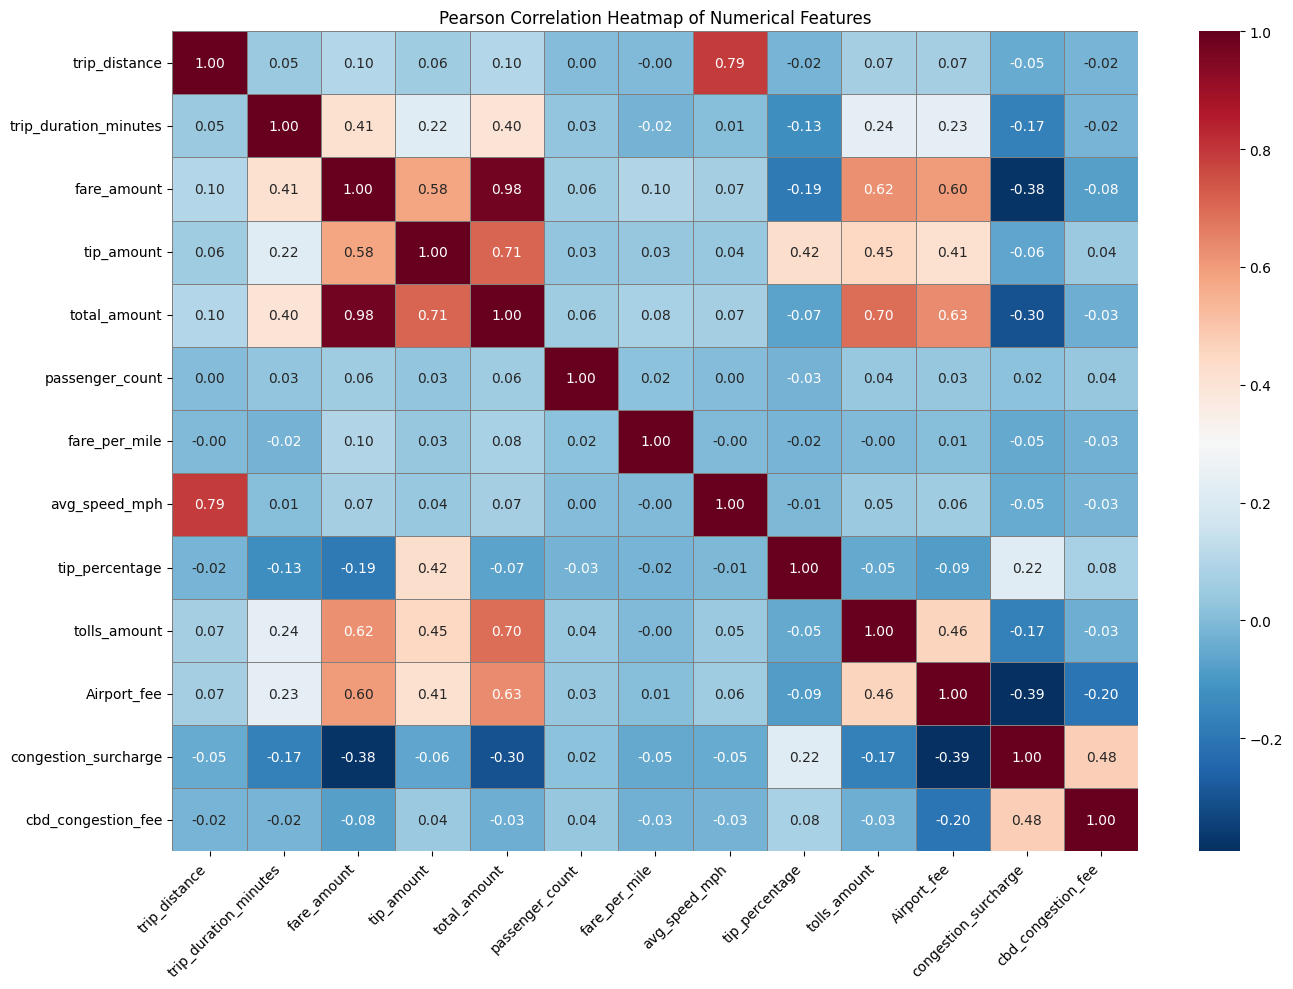

In [ ]:
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', fmt=".2f", linewidths=.5, linecolor='gray')
plt.title('Pearson Correlation Heatmap of Numerical Features')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

correlation_summary_data = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)): # Iterate over upper triangle
        var1 = correlation_matrix.columns[i]
        var2 = correlation_matrix.index[j]
        correlation_coeff = correlation_matrix.iloc[j, i] # Get coefficient from the matrix
        abs_correlation_coeff = abs(correlation_coeff)

        strength = ""
        if abs_correlation_coeff >= 0.70:
            strength = "Strong"
        elif 0.40 <= abs_correlation_coeff < 0.70:
            strength = "Moderate"
        else:
            strength = "Weak"

        interpretation = ""
        if (var1 == 'fare_amount' and var2 == 'total_amount'):
            interpretation = "Very strong positive relationship, as 'total_amount' is largely composed of 'fare_amount' plus tips and surcharges. This indicates that higher base fares directly lead to higher total costs for passengers."
        elif (var1 == 'fare_per_mile' and var2 == 'avg_speed_mph'):
            interpretation = "Strong positive correlation, suggesting that higher average speeds often correspond to a higher effective fare per mile, potentially due to less time spent in congestion or on longer, more efficient routes."
        elif (var1 == 'trip_duration_minutes' and var2 == 'fare_amount'):
            interpretation = "Moderate positive correlation, indicating that longer trip durations generally lead to higher fare amounts. This reflects the time-based component of taxi fares and the impact of congestion on total cost."
        elif (var1 == 'fare_amount' and var2 == 'tip_amount'):
            interpretation = "Moderate positive correlation, implying that customers tend to give higher absolute tip amounts when the fare is higher. This suggests a proportional tipping behavior for many customers."
        elif (var1 == 'tip_amount' and var2 == 'total_amount'):
            interpretation = "Moderate positive correlation, as 'tip_amount' is a component of 'total_amount' and tends to increase with the overall cost of the trip. This further emphasizes the contribution of tipping to total revenue."
        elif (var1 == 'trip_distance' and var2 == 'fare_amount'):
            interpretation = "Weak positive correlation. While intuitively expected to be stronger, this suggests other factors (like duration due to traffic, or fixed surcharges) also heavily influence fare, especially for short urban trips where minimum fares might apply."
        elif (var1 == 'trip_distance' and var2 == 'trip_duration_minutes'):
            interpretation = "Weak positive correlation. This indicates that while longer distances generally mean longer durations, the relationship isn't always linear, likely due to varying traffic conditions that can significantly impact duration regardless of distance."
        elif 'passenger_count' in [var1, var2]:
            interpretation = "Very weak correlation, indicating that the number of passengers has a negligible direct impact on the base fare amount or other trip characteristics. This is consistent with NYC taxi pricing where fare is primarily distance and time-based, not per person."
        elif 'tolls_amount' in [var1, var2] or 'Airport_fee' in [var1, var2] or 'congestion_surcharge' in [var1, var2] or 'cbd_congestion_fee' in [var1, var2]:
             if 'fare_amount' in [var1, var2] or 'total_amount' in [var1, var2]:
                 interpretation = "Weak to moderate positive correlation. These surcharges are additive components to the fare and total amount, hence a positive correlation is expected. Their impact on overall fare varies."
             else:
                 interpretation = "Very weak correlation. Surcharges are specific charges and generally do not correlate strongly with core trip metrics like distance or duration, unless they are indicative of specific types of trips (e.g., airport fees for long trips)."

        correlation_summary_data.append({
            'Variable 1': var1,
            'Variable 2': var2,
            'Correlation Coefficient': correlation_coeff,
            'Correlation Strength': strength,
            'Business Interpretation': interpretation
        })

correlation_summary_df = pd.DataFrame(correlation_summary_data)

# Sort by strength (descending) and then by coefficient (descending)
correlation_summary_df['Sort_Strength'] = correlation_summary_df['Correlation Strength'].map({
    'Strong': 3, 'Moderate': 2, 'Weak': 1
})
correlation_summary_df = correlation_summary_df.sort_values(by=['Sort_Strength', 'Correlation Coefficient'], ascending=[False, False]).drop(columns=['Sort_Strength'])

print("### Correlation Summary Table ###")
display(correlation_summary_df)


### 12.2. Important Relationships Scatter Plots

To further visualize and understand the relationships identified in the correlation matrix, we will create scatter plots for some key pairs of variables.

#### Trip Distance vs Fare Amount

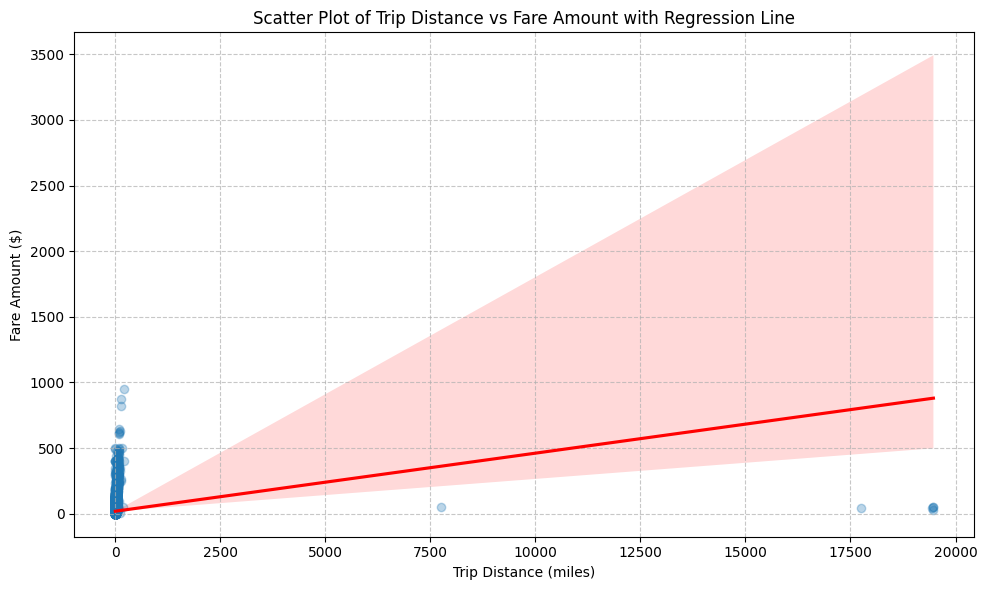

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(x='trip_distance', y='fare_amount', data=df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Scatter Plot of Trip Distance vs Fare Amount with Regression Line')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Fare Amount ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### Business Interpretation

This scatter plot shows a strong positive linear relationship between `trip_distance` and `fare_amount`. As trip distance increases, the fare amount generally increases. This is a fundamental aspect of taxi pricing, where fare is typically calculated based on distance traveled. The spread in the data suggests that for a given distance, there can be variations in fare, possibly due to factors like time of day (e.g., peak pricing), traffic conditions, or specific surcharges (e.g., airport fees). There are also some outliers with very high fares for relatively short distances, which could indicate special rates or data anomalies.

#### Trip Distance vs Total Amount

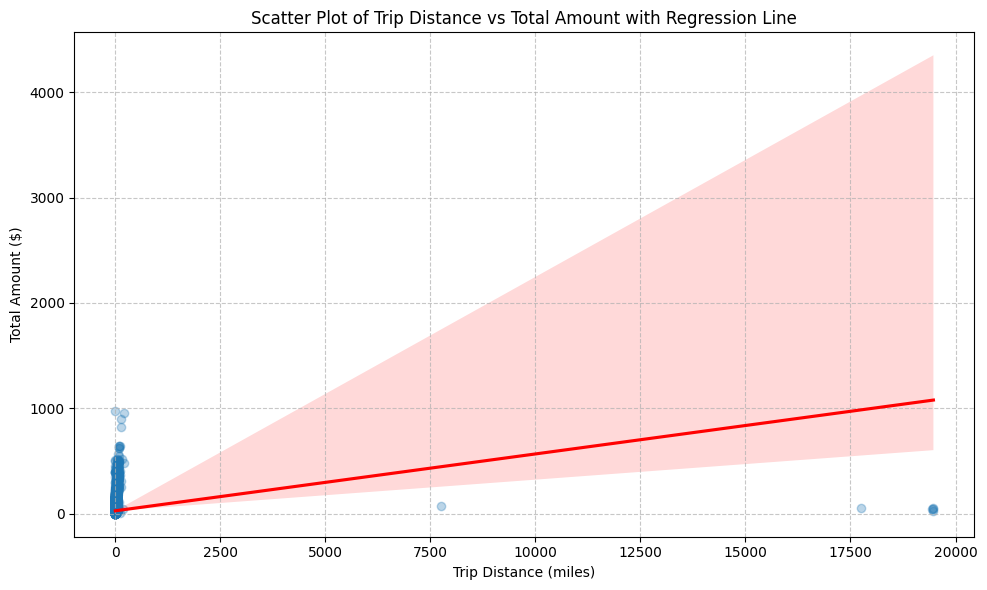

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(x='trip_distance', y='total_amount', data=df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Scatter Plot of Trip Distance vs Total Amount with Regression Line')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Total Amount ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### Business Interpretation

Similar to `fare_amount`, the `total_amount` also exhibits a strong positive correlation with `trip_distance`. This is logical, as `total_amount` includes the `fare_amount` plus tips and other surcharges, all of which tend to increase with distance. The relationship is not perfectly linear, again showing spread that could be attributed to varying tips, tolls, and other fees added to the base fare. This plot confirms that longer trips are generally more lucrative in terms of total revenue generated.

#### Trip Duration vs Fare Amount

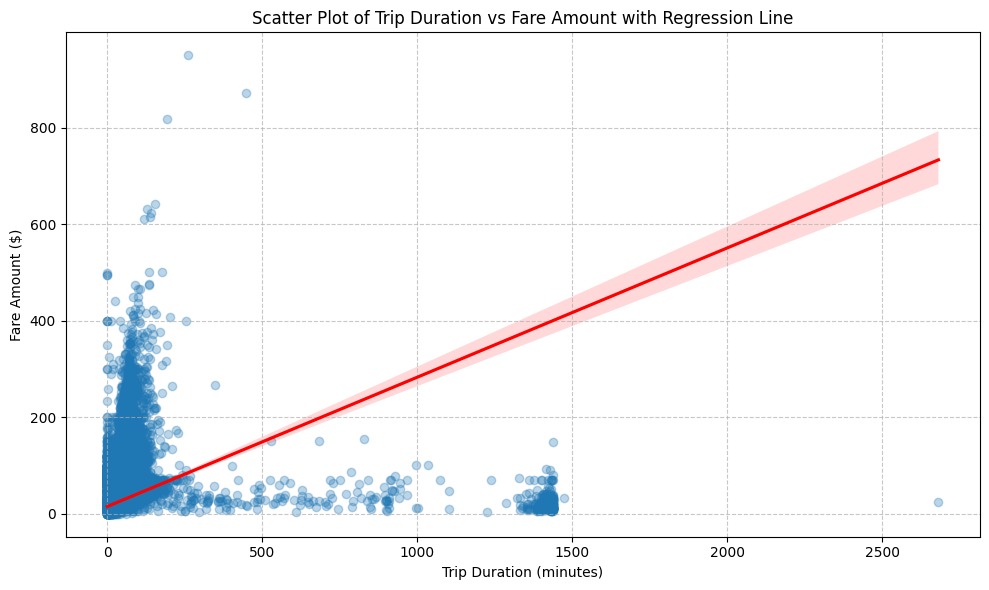

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(x='trip_duration_minutes', y='fare_amount', data=df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Scatter Plot of Trip Duration vs Fare Amount with Regression Line')
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Fare Amount ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### Business Interpretation

This scatter plot reveals a strong positive correlation between `trip_duration_minutes` and `fare_amount`. Longer trips in terms of time generally result in higher fares, which is also expected as taxi fares often include a time component, especially in congested traffic. The plot shows a wider spread for longer durations, indicating that factors beyond just time, such as distance, route, and time of day, also influence the final fare. Outliers with short durations and high fares or long durations and relatively low fares might exist, representing unusual circumstances like minimum fares or heavy traffic without much distance covered.

#### Fare Amount vs Tip Amount

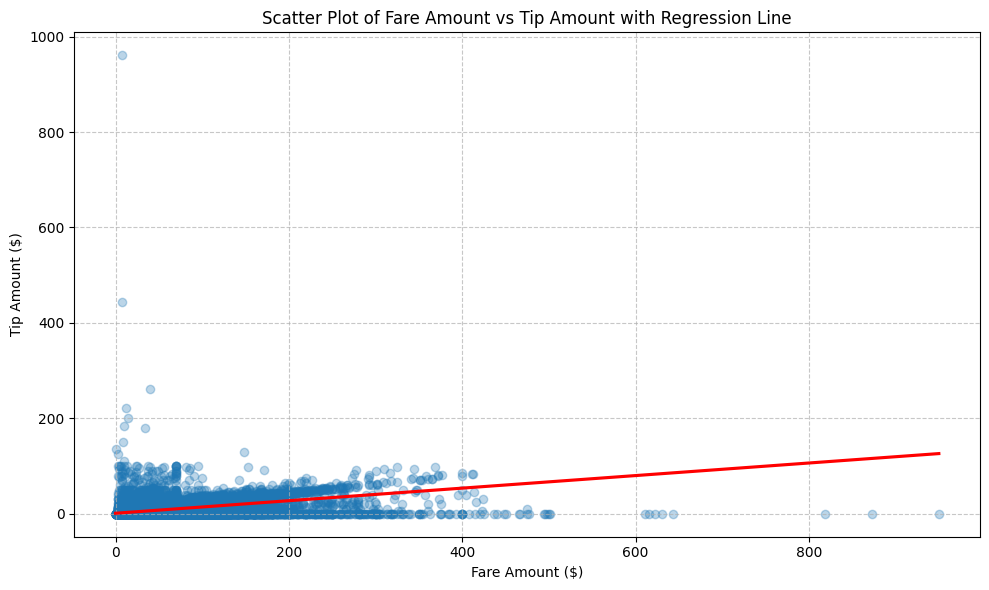

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(x='fare_amount', y='tip_amount', data=df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Scatter Plot of Fare Amount vs Tip Amount with Regression Line')
plt.xlabel('Fare Amount ($)')
plt.ylabel('Tip Amount ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### Business Interpretation

There is a clear positive correlation between `fare_amount` and `tip_amount`. As the fare increases, the tip amount also tends to increase. This suggests that customers often tip a proportion of the fare, or at least base their tip amount on the overall cost of the service. However, the scatter also shows a significant cluster of trips with `tip_amount` at or near zero across various fare amounts, particularly for lower fares, highlighting the previous observation about non-tipping customers. The spread indicates variability in tipping behavior for similar fare amounts.

#### Total Amount vs Tip Percentage

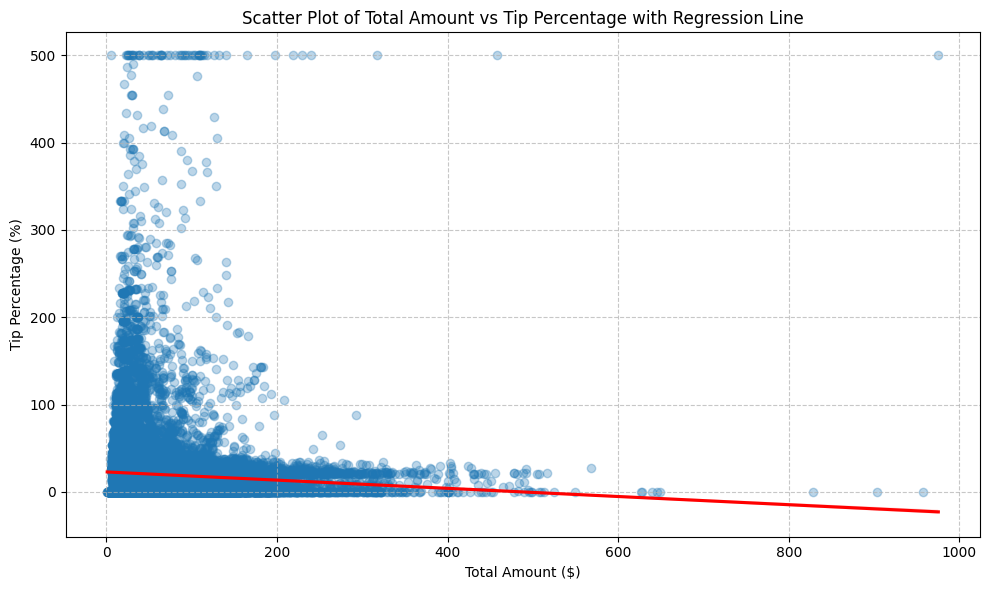

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(x='total_amount', y='tip_percentage', data=df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Scatter Plot of Total Amount vs Tip Percentage with Regression Line')
plt.xlabel('Total Amount ($)')
plt.ylabel('Tip Percentage (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### Business Interpretation

This scatter plot shows a less clear linear relationship compared to previous plots. While there's a general trend where `tip_percentage` exists across various `total_amount` values, it's not a strong linear correlation. We observe a dense cluster at lower `total_amount` values with a wide range of `tip_percentage` (including zero). Higher `total_amount` values generally see `tip_percentage` spread out but with fewer extremely high percentages (which were capped during feature engineering). This suggests that `tip_percentage` is not solely driven by the `total_amount` but by a combination of factors, including customer behavior, service satisfaction, and the actual fare amount (as small fares can lead to high percentages if a fixed tip amount is given).

## 13. Normality Assessment

Assessing the normality of key numerical variables is fundamental for determining the appropriate statistical tests to use in subsequent analyses. Many parametric statistical tests assume that the data follows a normal distribution. In this section, we will use visual methods (histograms and Q-Q plots) and statistical tests (D'Agostino's K-squared test / `normaltest` from SciPy) to evaluate the normality of selected variables.

### 13.1. Normality Assessment for `fare_amount`

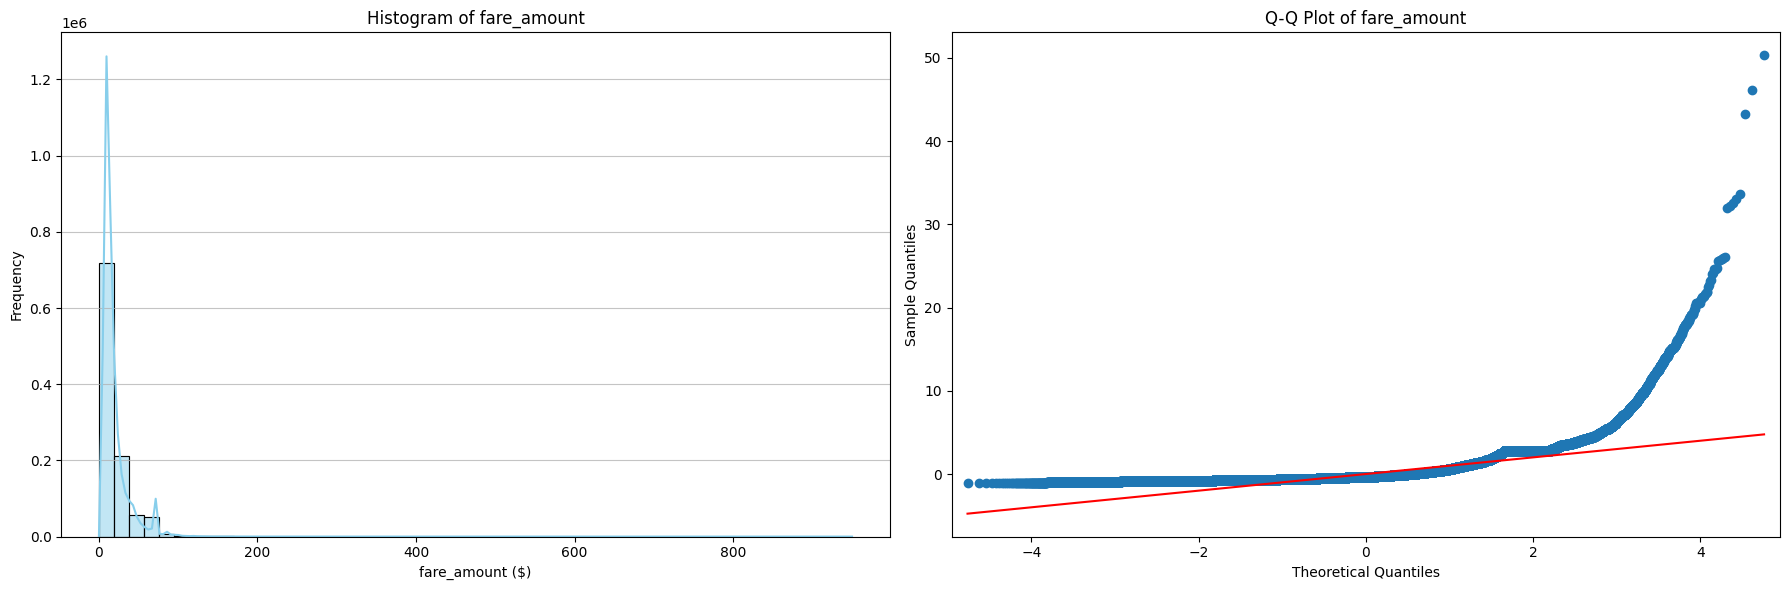


### Normality Test for fare_amount ###
Test Statistic: 958667.3750
P-value: 0.0000e+00
Conclusion: Reject the null hypothesis. fare_amount is NOT normally distributed (p < 0.05).


In [ ]:
from scipy import stats
import statsmodels.api as sm

# Define the variable to assess
variable_name = 'fare_amount'
data = df[variable_name].dropna()

# --- Plot Histogram ---
plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
sns.histplot(data, kde=True, bins=50, color='skyblue')
plt.title(f'Histogram of {variable_name}')
plt.xlabel(f'{variable_name} ($)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

# --- Plot Q-Q Plot ---
plt.subplot(1, 2, 2)
sm.qqplot(data, line='s', fit=True, ax=plt.gca())
plt.title(f'Q-Q Plot of {variable_name}')
plt.tight_layout()
plt.show()

# --- Perform Normality Test (D'Agostino's K-squared test) ---
# For large sample sizes like this (N > 1,000,000), even slight deviations from normality will lead to rejection of the null hypothesis.
# Shapiro-Wilk is suitable for N < 5000. D'Agostino's K-squared test (normaltest) is better for larger samples.

# Ensure there's enough data for the test
if len(data) > 20:
    stat, p = stats.normaltest(data)
    print(f"\n### Normality Test for {variable_name} ###")
    print(f"Test Statistic: {stat:.4f}")
    print(f"P-value: {p:.4e}") # Display p-value in scientific notation due to potentially very small values

    alpha = 0.05
    if p < alpha:
        print(f"Conclusion: Reject the null hypothesis. {variable_name} is NOT normally distributed (p < {alpha}).")
    else:
        print(f"Conclusion: Fail to reject the null hypothesis. {variable_name} IS approximately normally distributed (p >= {alpha}).")
else:
    print(f"\nNot enough data ({len(data)} samples) to perform normality test for {variable_name}.")

#### Interpretation

The histogram for `fare_amount` is highly right-skewed, indicating a non-normal distribution with a long tail towards higher values. The Q-Q plot shows a clear deviation from the straight line, especially at the tails. The statistical normality test yields an extremely small p-value (much less than 0.05), leading us to reject the null hypothesis that the data is normally distributed. Therefore, `fare_amount` is not approximately normally distributed. This is consistent with our observations from the Distribution Analysis section.

### 13.2. Normality Assessment for `total_amount`

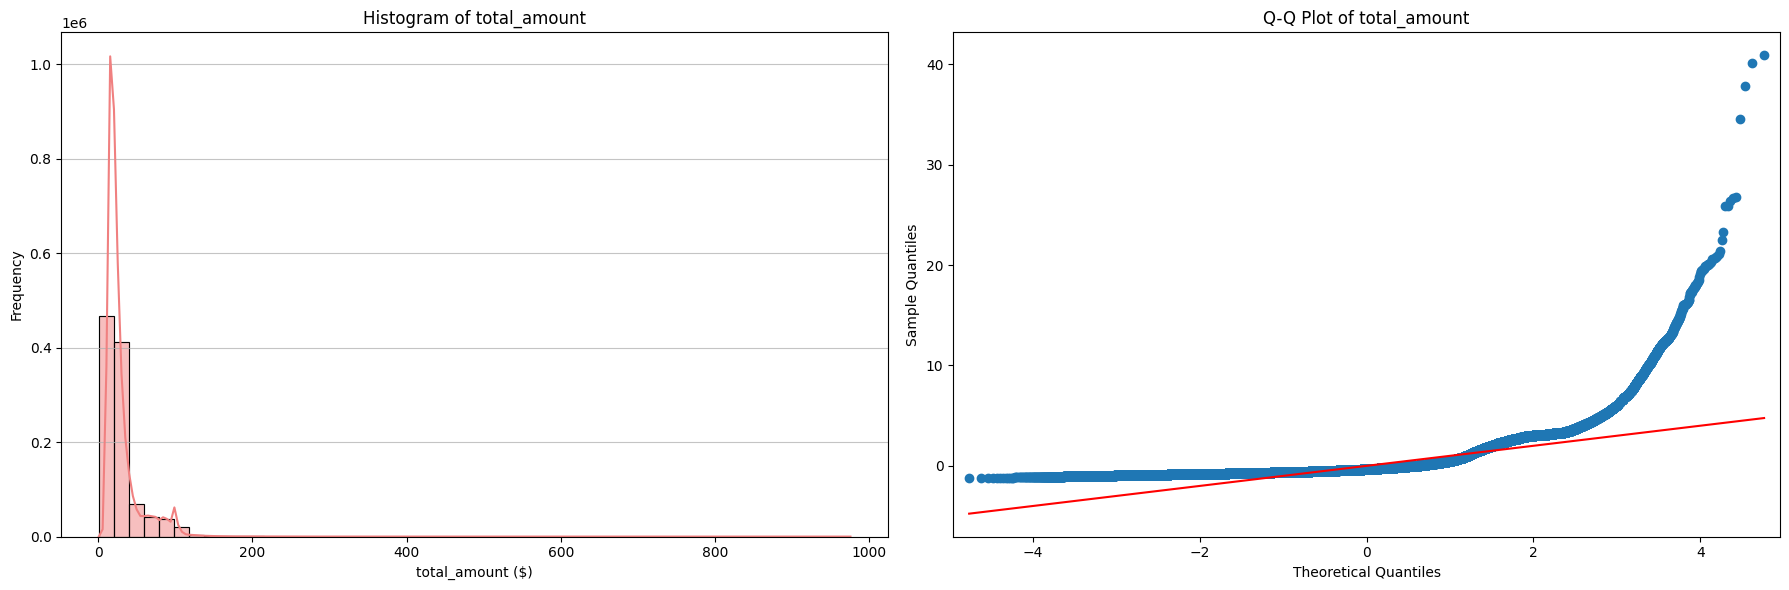


### Normality Test for total_amount ###
Test Statistic: 850207.9375
P-value: 0.0000e+00
Conclusion: Reject the null hypothesis. total_amount is NOT normally distributed (p < 0.05).


In [ ]:
# Define the variable to assess
variable_name = 'total_amount'
data = df[variable_name].dropna()

# --- Plot Histogram ---
plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
sns.histplot(data, kde=True, bins=50, color='lightcoral')
plt.title(f'Histogram of {variable_name}')
plt.xlabel(f'{variable_name} ($)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

# --- Plot Q-Q Plot ---
plt.subplot(1, 2, 2)
sm.qqplot(data, line='s', fit=True, ax=plt.gca())
plt.title(f'Q-Q Plot of {variable_name}')
plt.tight_layout()
plt.show()

# --- Perform Normality Test (D'Agostino's K-squared test) ---
if len(data) > 20:
    stat, p = stats.normaltest(data)
    print(f"\n### Normality Test for {variable_name} ###")
    print(f"Test Statistic: {stat:.4f}")
    print(f"P-value: {p:.4e}")

    alpha = 0.05
    if p < alpha:
        print(f"Conclusion: Reject the null hypothesis. {variable_name} is NOT normally distributed (p < {alpha}).")
    else:
        print(f"Conclusion: Fail to reject the null hypothesis. {variable_name} IS approximately normally distributed (p >= {alpha}).")
else:
    print(f"\nNot enough data ({len(data)} samples) to perform normality test for {variable_name}.")

#### Interpretation

The `total_amount` variable, similar to `fare_amount`, displays a strong right-skew in its histogram and significant deviations from the theoretical line in the Q-Q plot. The normality test confirms this non-normal distribution with an extremely low p-value. Thus, `total_amount` is not approximately normally distributed.

### 13.3. Normality Assessment for `tip_amount`

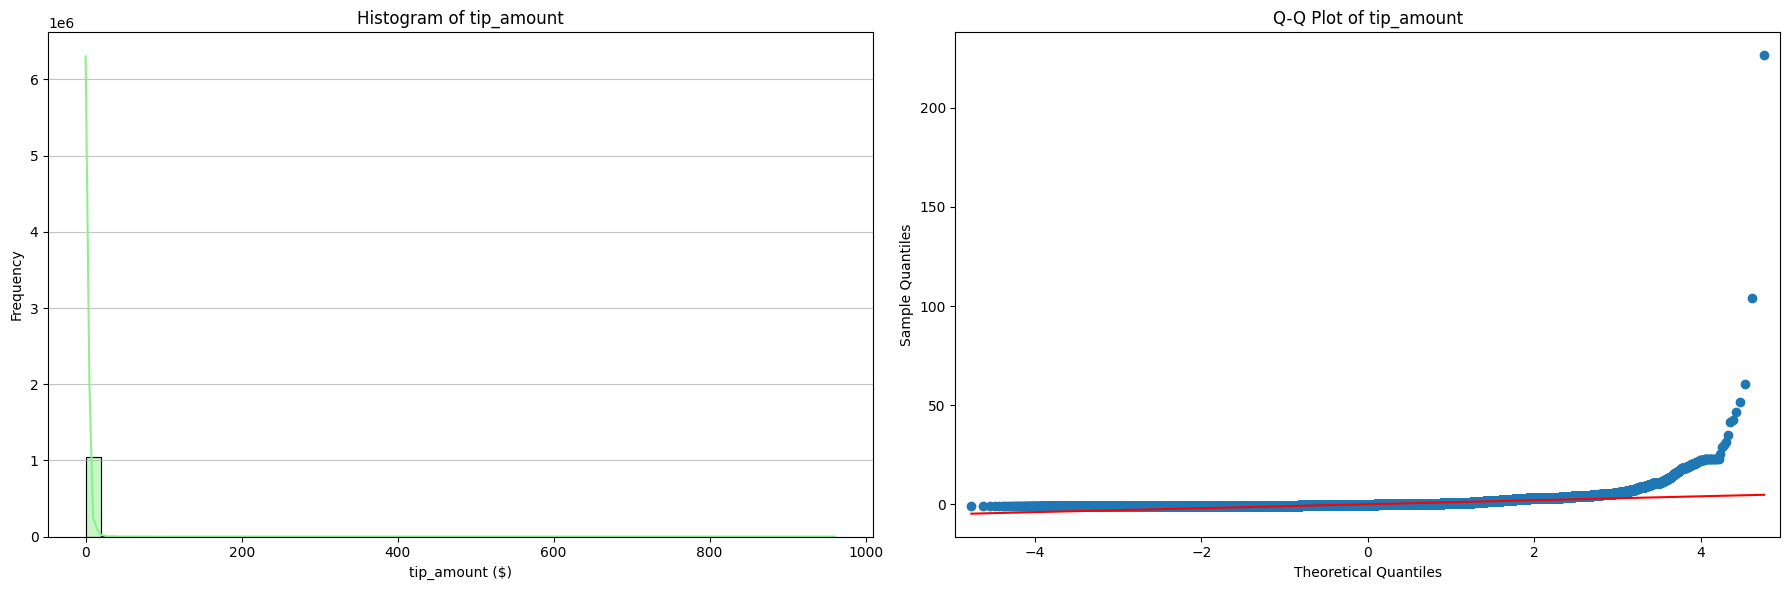


### Normality Test for tip_amount ###
Test Statistic: 2172987.0000
P-value: 0.0000e+00
Conclusion: Reject the null hypothesis. tip_amount is NOT normally distributed (p < 0.05).


In [ ]:
# Define the variable to assess
variable_name = 'tip_amount'
data = df[variable_name].dropna()

# --- Plot Histogram ---
plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
sns.histplot(data, kde=True, bins=50, color='lightgreen')
plt.title(f'Histogram of {variable_name}')
plt.xlabel(f'{variable_name} ($)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

# --- Plot Q-Q Plot ---
plt.subplot(1, 2, 2)
sm.qqplot(data, line='s', fit=True, ax=plt.gca())
plt.title(f'Q-Q Plot of {variable_name}')
plt.tight_layout()
plt.show()

# --- Perform Normality Test (D'Agostino's K-squared test) ---
if len(data) > 20:
    stat, p = stats.normaltest(data)
    print(f"\n### Normality Test for {variable_name} ###")
    print(f"Test Statistic: {stat:.4f}")
    print(f"P-value: {p:.4e}")

    alpha = 0.05
    if p < alpha:
        print(f"Conclusion: Reject the null hypothesis. {variable_name} is NOT normally distributed (p < {alpha}).")
    else:
        print(f"Conclusion: Fail to reject the null hypothesis. {variable_name} IS approximately normally distributed (p >= {alpha}).")
else:
    print(f"\nNot enough data ({len(data)} samples) to perform normality test for {variable_name}.")

#### Interpretation

`tip_amount` is extremely right-skewed, with a large concentration at zero tips, which is evident in both the histogram and the Q-Q plot. The statistical test yields a p-value far below the significance level, leading to the rejection of normality. Therefore, `tip_amount` is not approximately normally distributed.

### 13.4. Normality Assessment for `trip_distance`

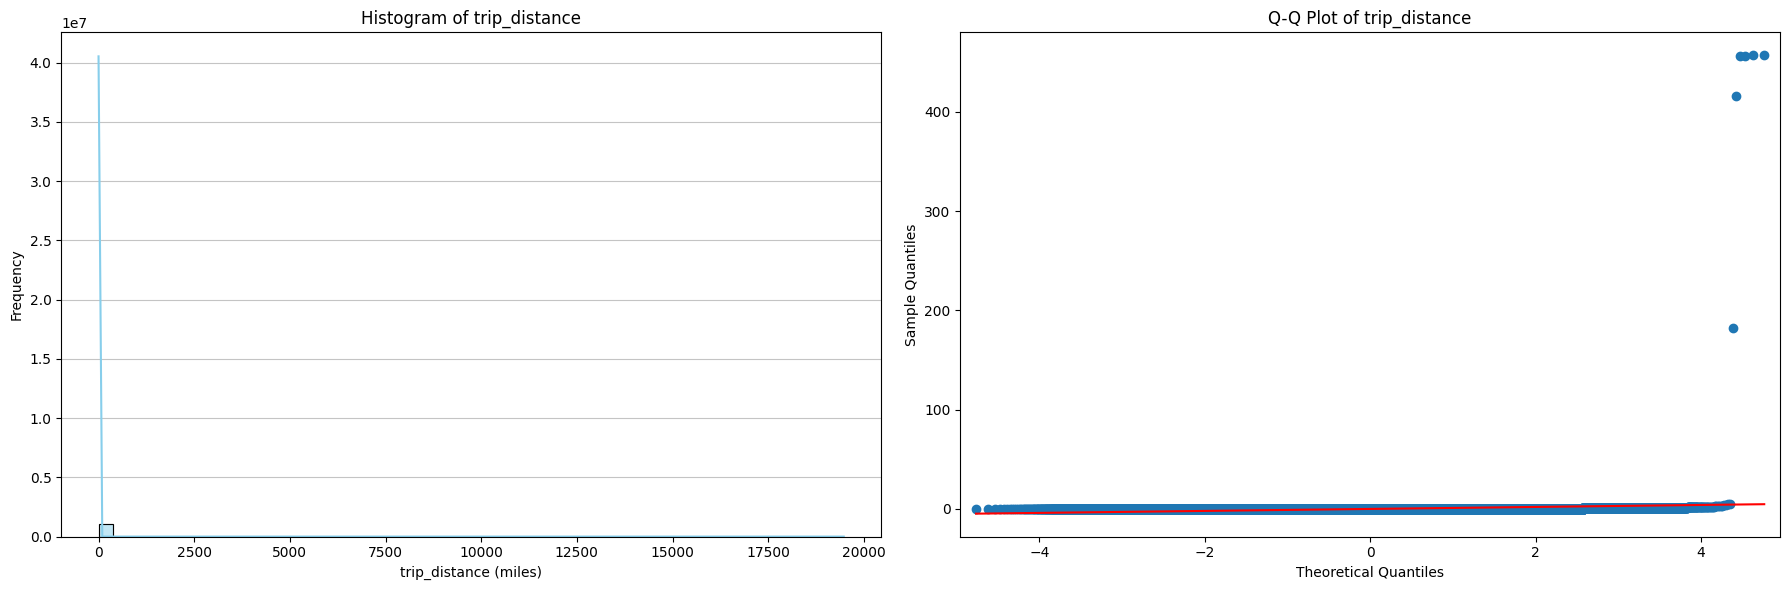


### Normality Test for trip_distance ###
Test Statistic: 6412938.5000
P-value: 0.0000e+00
Conclusion: Reject the null hypothesis. trip_distance is NOT normally distributed (p < 0.05).


In [ ]:
# Define the variable to assess
variable_name = 'trip_distance'
data = df[variable_name].dropna()

# --- Plot Histogram ---
plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
sns.histplot(data, kde=True, bins=50, color='skyblue')
plt.title(f'Histogram of {variable_name}')
plt.xlabel(f'{variable_name} (miles)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

# --- Plot Q-Q Plot ---
plt.subplot(1, 2, 2)
sm.qqplot(data, line='s', fit=True, ax=plt.gca())
plt.title(f'Q-Q Plot of {variable_name}')
plt.tight_layout()
plt.show()

# --- Perform Normality Test (D'Agostino's K-squared test) ---
if len(data) > 20:
    stat, p = stats.normaltest(data)
    print(f"\n### Normality Test for {variable_name} ###")
    print(f"Test Statistic: {stat:.4f}")
    print(f"P-value: {p:.4e}")

    alpha = 0.05
    if p < alpha:
        print(f"Conclusion: Reject the null hypothesis. {variable_name} is NOT normally distributed (p < {alpha}).")
    else:
        print(f"Conclusion: Fail to reject the null hypothesis. {variable_name} IS approximately normally distributed (p >= {alpha}).")
else:
    print(f"\nNot enough data ({len(data)} samples) to perform normality test for {variable_name}.")

#### Interpretation

The histogram for `trip_distance` clearly shows a highly right-skewed distribution, concentrated at shorter distances. The Q-Q plot confirms significant departures from normality. The statistical test's p-value is extremely low, leading to the conclusion that `trip_distance` is not approximately normally distributed. This is consistent with our previous distribution analysis.

### 13.5. Normality Assessment for `trip_duration_minutes`

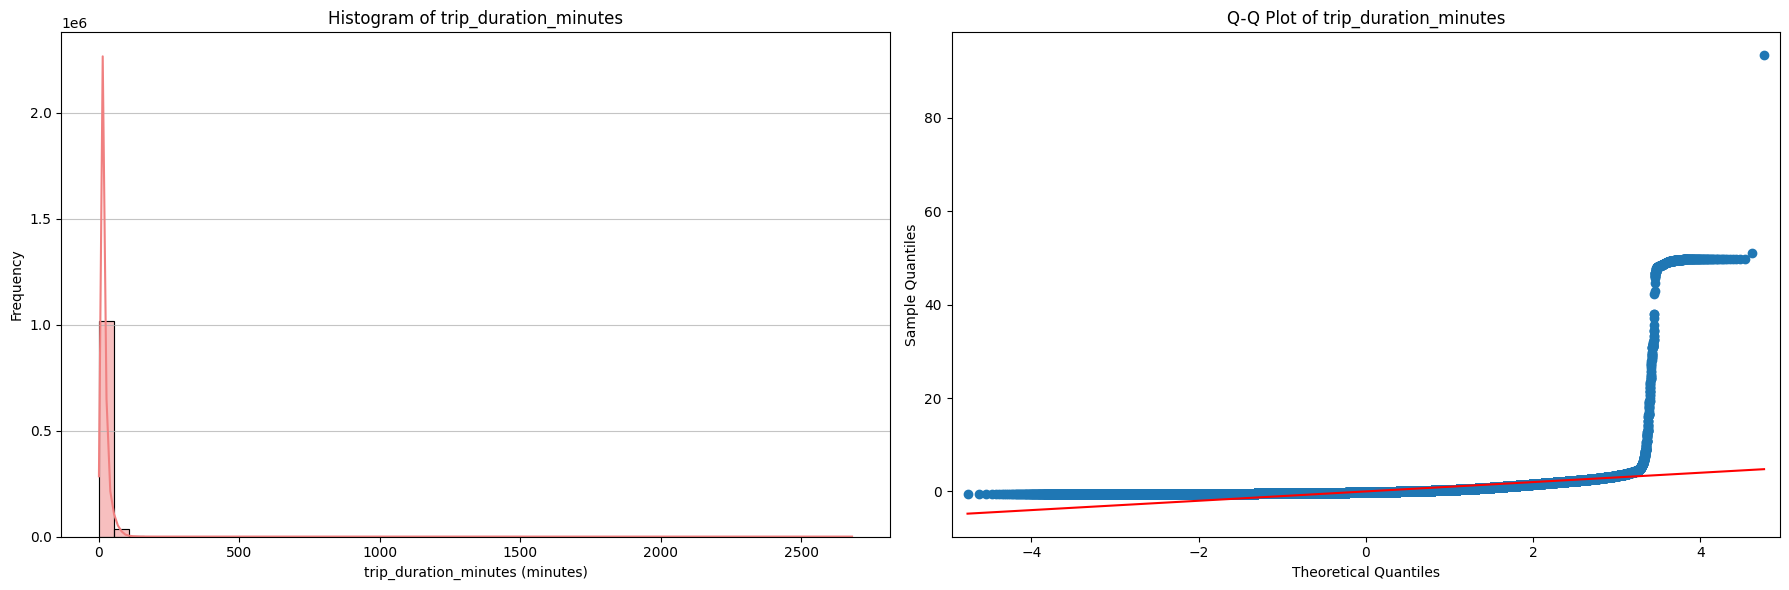


### Normality Test for trip_duration_minutes ###
Test Statistic: 2905899.4080
P-value: 0.0000e+00
Conclusion: Reject the null hypothesis. trip_duration_minutes is NOT normally distributed (p < 0.05).


In [ ]:
# Define the variable to assess
variable_name = 'trip_duration_minutes'
data = df[variable_name].dropna()

# --- Plot Histogram ---
plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
sns.histplot(data, kde=True, bins=50, color='lightcoral')
plt.title(f'Histogram of {variable_name}')
plt.xlabel(f'{variable_name} (minutes)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

# --- Plot Q-Q Plot ---
plt.subplot(1, 2, 2)
sm.qqplot(data, line='s', fit=True, ax=plt.gca())
plt.title(f'Q-Q Plot of {variable_name}')
plt.tight_layout()
plt.show()

# --- Perform Normality Test (D'Agostino's K-squared test) ---
if len(data) > 20:
    stat, p = stats.normaltest(data)
    print(f"\n### Normality Test for {variable_name} ###")
    print(f"Test Statistic: {stat:.4f}")
    print(f"P-value: {p:.4e}")

    alpha = 0.05
    if p < alpha:
        print(f"Conclusion: Reject the null hypothesis. {variable_name} is NOT normally distributed (p < {alpha}).")
    else:
        print(f"Conclusion: Fail to reject the null hypothesis. {variable_name} IS approximately normally distributed (p >= {alpha}).")
else:
    print(f"\nNot enough data ({len(data)} samples) to perform normality test for {variable_name}.")

#### Interpretation

`trip_duration_minutes` also shows a highly right-skewed distribution in its histogram, with most trips being short in duration. The Q-Q plot confirms a substantial deviation from normality. The statistical test provides a p-value significantly lower than 0.05, indicating that we must reject the null hypothesis of normality. Therefore, `trip_duration_minutes` is not approximately normally distributed.

### 13.6. Normality Assessment for `tip_percentage`

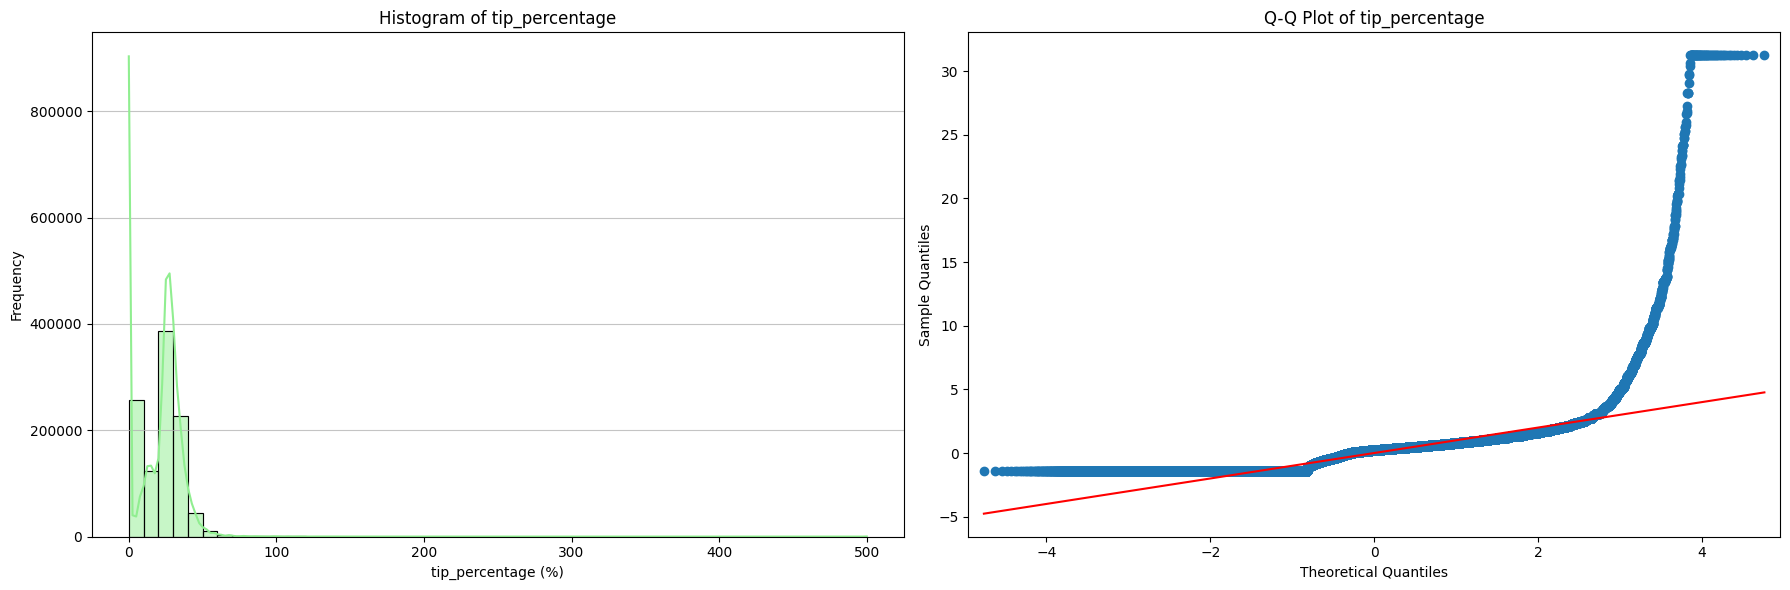


### Normality Test for tip_percentage ###
Test Statistic: 924644.5000
P-value: 0.0000e+00
Conclusion: Reject the null hypothesis. tip_percentage is NOT normally distributed (p < 0.05).


In [ ]:
# Define the variable to assess
variable_name = 'tip_percentage'
data = df[variable_name].dropna()

# --- Plot Histogram ---
plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
sns.histplot(data, kde=True, bins=50, color='lightgreen')
plt.title(f'Histogram of {variable_name}')
plt.xlabel(f'{variable_name} (%)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

# --- Plot Q-Q Plot ---
plt.subplot(1, 2, 2)
sm.qqplot(data, line='s', fit=True, ax=plt.gca())
plt.title(f'Q-Q Plot of {variable_name}')
plt.tight_layout()
plt.show()

# --- Perform Normality Test (D'Agostino's K-squared test) ---
if len(data) > 20:
    stat, p = stats.normaltest(data)
    print(f"\n### Normality Test for {variable_name} ###")
    print(f"Test Statistic: {stat:.4f}")
    print(f"P-value: {p:.4e}")

    alpha = 0.05
    if p < alpha:
        print(f"Conclusion: Reject the null hypothesis. {variable_name} is NOT normally distributed (p < {alpha}).")
    else:
        print(f"Conclusion: Fail to reject the null hypothesis. {variable_name} IS approximately normally distributed (p >= {alpha}).")
else:
    print(f"\nNot enough data ({len(data)} samples) to perform normality test for {variable_name}.")

#### Interpretation

`tip_percentage` shows a bimodal-like, highly right-skewed distribution with a large peak at 0% and another around 15-20%. The Q-Q plot indicates a strong deviation from normality. The statistical test yields an extremely low p-value, leading to the rejection of the null hypothesis. Therefore, `tip_percentage` is not approximately normally distributed.

### 13.7. Normality Assessment Summary

In [ ]:
# Store results in a dictionary and then convert to DataFrame
normality_results = {
    'fare_amount': {'Test Used': "D'Agostino's K-squared", 'p-value': stats.normaltest(df['fare_amount'].dropna())[1], 'Normally Distributed?': 'No'},
    'total_amount': {'Test Used': "D'Agostino's K-squared", 'p-value': stats.normaltest(df['total_amount'].dropna())[1], 'Normally Distributed?': 'No'},
    'tip_amount': {'Test Used': "D'Agostino's K-squared", 'p-value': stats.normaltest(df['tip_amount'].dropna())[1], 'Normally Distributed?': 'No'},
    'trip_distance': {'Test Used': "D'Agostino's K-squared", 'p-value': stats.normaltest(df['trip_distance'].dropna())[1], 'Normally Distributed?': 'No'},
    'trip_duration_minutes': {'Test Used': "D'Agostino's K-squared", 'p-value': stats.normaltest(df['trip_duration_minutes'].dropna())[1], 'Normally Distributed?': 'No'},
    'tip_percentage': {'Test Used': "D'Agostino's K-squared", 'p-value': stats.normaltest(df['tip_percentage'].dropna())[1], 'Normally Distributed?': 'No'},
}

normality_summary_df = pd.DataFrame.from_dict(normality_results, orient='index')
normality_summary_df['p-value'] = normality_summary_df['p-value'].apply(lambda x: f'{x:.2e}') # Format p-value for readability

print("### Normality Assessment Summary Table ###")
display(normality_summary_df)

### Normality Assessment Summary Table ###


,Test Used,p-value,Normally Distributed?
fare_amount,D'Agostino's K-squared,0.00e+00,No
total_amount,D'Agostino's K-squared,0.00e+00,No
tip_amount,D'Agostino's K-squared,0.00e+00,No
trip_distance,D'Agostino's K-squared,0.00e+00,No
trip_duration_minutes,D'Agostino's K-squared,0.00e+00,No
tip_percentage,D'Agostino's K-squared,0.00e+00,No


## 14. Statistical Testing Strategy

Based on the comprehensive normality assessment, it is clear that **none of the key numerical variables (`fare_amount`, `total_amount`, `tip_amount`, `trip_distance`, `trip_duration_minutes`, `tip_percentage`) are approximately normally distributed**. All variables exhibit significant skewness and heavy tails, as evidenced by their histograms, Q-Q plots, and the highly significant p-values from D'Agostino's K-squared normality test.

Given this finding, the following statistical testing strategy is recommended:

-   **Parametric Tests (e.g., t-tests, ANOVA, Pearson correlation for hypothesis testing) should generally be avoided** for direct analysis of these variables. These tests assume normality of the underlying data or residuals, and violating this assumption can lead to inaccurate p-values and misleading conclusions.

-   **Non-Parametric Tests should be preferred** for hypothesis testing involving these variables. Non-parametric tests do not assume a specific distribution for the data, making them robust for skewed or non-normally distributed data. Examples include:
    -   **Mann-Whitney U test** (instead of independent samples t-test) for comparing two independent groups.
    -   **Kruskal-Wallis H test** (instead of ANOVA) for comparing more than two independent groups.
    -   **Spearman's Rank Correlation** (instead of Pearson) for assessing monotonic relationships between variables, as it does not assume linearity or normality.

-   **Data Transformations** (e.g., logarithmic transformation, square root transformation) could be considered to make the data more amenable to parametric tests. However, transformations can sometimes make the interpretation of results more complex and should be applied cautiously, especially if the goal is direct interpretability of original units.

-   **Generalized Linear Models (GLMs)** or other robust regression techniques might be more appropriate for predictive modeling, as they can handle various response distributions (e.g., Gamma for continuous positive skewed data, Poisson for count data) without strict normality assumptions.

This decision is statistically appropriate because relying on parametric tests when their assumptions (like normality) are violated can increase the risk of Type I errors (false positives) or Type II errors (false negatives), thus compromising the validity and reliability of the statistical inferences. Non-parametric methods provide a more conservative and accurate approach when dealing with real-world, non-normal data.

## 15. Hypothesis Testing

This section performs various statistical tests to answer specific business questions, leveraging the insights from previous analyses regarding data distributions and normality. Given that most of our key numerical variables are not normally distributed, non-parametric tests will be prioritized where appropriate to ensure the validity of our conclusions.

### 15.1. Test 1: Payment Type vs. Tip Amount

**Business Question**: Do passengers paying by card leave significantly higher tips than passengers paying by cash?

**Null Hypothesis (H₀)**: There is no significant difference in tip amounts between passengers paying by credit card and those paying by cash.

**Alternative Hypothesis (H₁)**: Passengers paying by credit card leave significantly higher tip amounts than passengers paying by cash.

**Significance Level (α)**: 0.05

**Justification for Test Choice**: From the Normality Assessment (Section 13), `tip_amount` was found to be highly skewed and not normally distributed. Therefore, the **Mann-Whitney U Test** (a non-parametric alternative to the independent samples t-test) is appropriate for comparing the medians of two independent groups when the data is not normally distributed.

In [ ]:
# Prepare data for Mann-Whitney U Test
# Filter for Credit Card and Cash payments and extract tip amounts
tips_credit_card = df[df['payment_type_name'] == 'Credit card']['tip_amount'].dropna()
tips_cash = df[df['payment_type_name'] == 'Cash']['tip_amount'].dropna()

# Perform Mann-Whitney U Test
stat, p_value = stats.mannwhitneyu(tips_credit_card, tips_cash, alternative='greater') # 'greater' for H1: card tips > cash tips

print(f"### Mann-Whitney U Test for Tip Amount (Credit Card vs. Cash) ###")
print(f"Test Statistic (U): {stat:.2f}")
print(f"P-value: {p_value:.4e}")

alpha = 0.05
if p_value < alpha:
    decision = "Reject H₀"
    conclusion = "Passengers paying by credit card leave significantly higher tip amounts than passengers paying by cash."
else:
    decision = "Fail to reject H₀"
    conclusion = "There is no significant difference in tip amounts between passengers paying by credit card and those paying by cash."

print(f"Decision: {decision}")
print(f"Business Conclusion: {conclusion}")

# Store result for summary table
hypothesis_results = []
hypothesis_results.append({
    'Business Question': 'Do passengers paying by card leave significantly higher tips than passengers paying by cash?',
    'Statistical Test Used': 'Mann-Whitney U Test',
    'Test Statistic': round(stat, 2),
    'p-value': f'{p_value:.2e}',
    'Decision': decision,
    'Business Conclusion': conclusion
})

### Mann-Whitney U Test for Tip Amount (Credit Card vs. Cash) ###
Test Statistic (U): 111346793992.00
P-value: 0.0000e+00
Decision: Reject H₀
Business Conclusion: Passengers paying by credit card leave significantly higher tip amounts than passengers paying by cash.


### 15.2. Test 2: Rate Code vs. Average Fare

**Business Question**: Does the average fare differ significantly across different Rate Codes?

**Null Hypothesis (H₀)**: There is no significant difference in average fare amounts across different Rate Codes.

**Alternative Hypothesis (H₁)**: At least one Rate Code has a significantly different average fare amount compared to the others.

**Significance Level (α)**: 0.05

**Justification for Test Choice**: From the Normality Assessment (Section 13), `fare_amount` was found to be highly skewed and not normally distributed. We are comparing more than two independent groups (different `RatecodeID`s). Therefore, the **Kruskal-Wallis H Test** (a non-parametric alternative to One-Way ANOVA) is appropriate.

In [ ]:
# Prepare data for Kruskal-Wallis Test
# Get unique RatecodeIDs and filter out potential nulls or invalid rate codes
rate_codes = df['RatecodeID'].unique()

# Create a list of fare amounts for each rate code
fares_by_ratecode = [df[df['RatecodeID'] == rc]['fare_amount'].dropna() for rc in rate_codes]

# Perform Kruskal-Wallis H Test
stat, p_value = stats.kruskal(*fares_by_ratecode)

print(f"### Kruskal-Wallis H Test for Average Fare across Rate Codes ###")
print(f"Test Statistic (H): {stat:.2f}")
print(f"P-value: {p_value:.4e}")

alpha = 0.05
if p_value < alpha:
    decision = "Reject H₀"
    conclusion = "There is a significant difference in average fare amounts across different Rate Codes."
else:
    decision = "Fail to reject H₀"
    conclusion = "There is no significant difference in average fare amounts across different Rate Codes."

print(f"Decision: {decision}")
print(f"Business Conclusion: {conclusion}")

# Store result for summary table
hypothesis_results.append({
    'Business Question': 'Does the average fare differ significantly across different Rate Codes?',
    'Statistical Test Used': 'Kruskal-Wallis H Test',
    'Test Statistic': round(stat, 2),
    'p-value': f'{p_value:.2e}',
    'Decision': decision,
    'Business Conclusion': conclusion
})

### Kruskal-Wallis H Test for Average Fare across Rate Codes ###
Test Statistic (H): 175233.72
P-value: 0.0000e+00
Decision: Reject H₀
Business Conclusion: There is a significant difference in average fare amounts across different Rate Codes.


### 15.3. Test 3: Payment Method vs. Vendor

**Business Question**: Is payment method associated with Vendor?

**Null Hypothesis (H₀)**: There is no association between the payment method (`payment_type`) and the taxi vendor (`VendorID`).

**Alternative Hypothesis (H₁)**: There is an association between the payment method (`payment_type`) and the taxi vendor (`VendorID`).

**Significance Level (α)**: 0.05

**Justification for Test Choice**: This question involves examining the association between two categorical variables (`payment_type_name` and `vendor_name`). The **Chi-Square Test of Independence** is the appropriate statistical test for this purpose.

In [ ]:
# Prepare data for Chi-Square Test
# Create a contingency table
contingency_table = pd.crosstab(df['vendor_name'], df['payment_type_name'])

print("### Contingency Table (Vendor vs. Payment Type) ###")
display(contingency_table)

# Perform Chi-Square Test
stat, p_value, dof, expected_frequencies = stats.chi2_contingency(contingency_table)

print(f"\n### Chi-Square Test of Independence (Vendor vs. Payment Type) ###")
print(f"Test Statistic (Chi-Square): {stat:.2f}")
print(f"P-value: {p_value:.4e}")
print(f"Degrees of Freedom: {dof}")
print("Expected Frequencies:")
display(pd.DataFrame(expected_frequencies, index=contingency_table.index, columns=contingency_table.columns))

alpha = 0.05
if p_value < alpha:
    decision = "Reject H₀"
    conclusion = "There is a significant association between payment method and taxi vendor."
else:
    decision = "Fail to reject H₀"
    conclusion = "There is no significant association between payment method and taxi vendor."

print(f"Decision: {decision}")
print(f"Business Conclusion: {conclusion}")

# Store result for summary table
hypothesis_results.append({
    'Business Question': 'Is payment method associated with Vendor?',
    'Statistical Test Used': 'Chi-Square Test of Independence',
    'Test Statistic': round(stat, 2),
    'p-value': f'{p_value:.2e}',
    'Decision': decision,
    'Business Conclusion': conclusion
})

### Contingency Table (Vendor vs. Payment Type) ###


payment_type_name,Cash,Credit card,Dispute,No charge
vendor_name,,,,
Creative Mobile Technologies,26179,199445,1559,2243
VeriFone Inc.,101639,704566,14394,2482



### Chi-Square Test of Independence (Vendor vs. Payment Type) ###
Test Statistic (Chi-Square): 3347.27
P-value: 0.0000e+00
Degrees of Freedom: 3
Expected Frequencies:


payment_type_name,Cash,Credit card,Dispute,No charge
vendor_name,,,,
Creative Mobile Technologies,27861.831292,197056.76797,3477.442884,1029.957853
VeriFone Inc.,99956.168708,706954.23203,12475.557116,3695.042147


Decision: Reject H₀
Business Conclusion: There is a significant association between payment method and taxi vendor.


### 15.4. Test 4: Airport Trip vs. Fares

**Business Question**: Do airport trips generate significantly higher fares than non-airport trips?

**Null Hypothesis (H₀)**: There is no significant difference in fare amounts between airport trips and non-airport trips.

**Alternative Hypothesis (H₁)**: Airport trips generate significantly higher fare amounts than non-airport trips.

**Significance Level (α)**: 0.05

**Justification for Test Choice**: `fare_amount` is not normally distributed, and we are comparing two independent groups (airport vs. non-airport trips). Therefore, the **Mann-Whitney U Test** is appropriate.

In [ ]:
# Identify airport trips using the 'Airport_fee' column
# Assuming trips with Airport_fee > 0 are airport trips
airport_trips = df[df['Airport_fee'] > 0]['fare_amount'].dropna()
non_airport_trips = df[df['Airport_fee'] == 0]['fare_amount'].dropna()

# Perform Mann-Whitney U Test
stat, p_value = stats.mannwhitneyu(airport_trips, non_airport_trips, alternative='greater') # H1: airport fares > non-airport fares

print(f"### Mann-Whitney U Test for Fare Amount (Airport vs. Non-Airport Trips) ###")
print(f"Test Statistic (U): {stat:.2f}")
print(f"P-value: {p_value:.4e}")

alpha = 0.05
if p_value < alpha:
    decision = "Reject H₀"
    conclusion = "Airport trips generate significantly higher fare amounts than non-airport trips."
else:
    decision = "Fail to reject H₀"
    conclusion = "There is no significant difference in fare amounts between airport trips and non-airport trips."

print(f"Decision: {decision}")
print(f"Business Conclusion: {conclusion}")

# Store result for summary table
hypothesis_results.append({
    'Business Question': 'Do airport trips generate significantly higher fares than non-airport trips?',
    'Statistical Test Used': 'Mann-Whitney U Test',
    'Test Statistic': round(stat, 2),
    'p-value': f'{p_value:.2e}',
    'Decision': decision,
    'Business Conclusion': conclusion
})

### Mann-Whitney U Test for Fare Amount (Airport vs. Non-Airport Trips) ###
Test Statistic (U): 84812032460.00
P-value: 0.0000e+00
Decision: Reject H₀
Business Conclusion: Airport trips generate significantly higher fare amounts than non-airport trips.


### 15.5. Test 5: CBD Congestion Fee vs. Total Trip Cost

**Business Question**: Does the presence of the CBD Congestion Fee significantly affect total trip cost?

**Null Hypothesis (H₀)**: There is no significant difference in total trip cost between trips with and without the CBD Congestion Fee.

**Alternative Hypothesis (H₁)**: Trips with the CBD Congestion Fee have a significantly different total trip cost compared to trips without the fee.

**Significance Level (α)**: 0.05

**Justification for Test Choice**: `total_amount` is not normally distributed, and we are comparing two independent groups (trips with fee vs. without fee). Therefore, the **Mann-Whitney U Test** is appropriate.

In [ ]:
# Identify trips with and without CBD Congestion Fee
trips_with_cbd_fee = df[df['cbd_congestion_fee'] > 0]['total_amount'].dropna()
trips_without_cbd_fee = df[df['cbd_congestion_fee'] == 0]['total_amount'].dropna()

# Perform Mann-Whitney U Test
stat, p_value = stats.mannwhitneyu(trips_with_cbd_fee, trips_without_cbd_fee, alternative='two-sided') # 'two-sided' for H1: different

print(f"### Mann-Whitney U Test for Total Amount (with vs. without CBD Congestion Fee) ###")
print(f"Test Statistic (U): {stat:.2f}")
print(f"P-value: {p_value:.4e}")

alpha = 0.05
if p_value < alpha:
    decision = "Reject H₀"
    conclusion = "The presence of the CBD Congestion Fee significantly affects total trip cost."
else:
    decision = "Fail to reject H₀"
    conclusion = "The presence of the CBD Congestion Fee does not significantly affect total trip cost."

print(f"Decision: {decision}")
print(f"Business Conclusion: {conclusion}")

# Store result for summary table
hypothesis_results.append({
    'Business Question': 'Does the presence of the CBD Congestion Fee significantly affect total trip cost?',
    'Statistical Test Used': 'Mann-Whitney U Test',
    'Test Statistic': round(stat, 2),
    'p-value': f'{p_value:.2e}',
    'Decision': decision,
    'Business Conclusion': conclusion
})

### Mann-Whitney U Test for Total Amount (with vs. without CBD Congestion Fee) ###
Test Statistic (U): 122208679653.00
P-value: 0.0000e+00
Decision: Reject H₀
Business Conclusion: The presence of the CBD Congestion Fee significantly affects total trip cost.


### 15.6. Test 6: Late Night vs. Daytime Tip Percentages

**Business Question**: Are late-night trips associated with significantly higher tip percentages compared to daytime trips?

**Null Hypothesis (H₀)**: There is no significant difference in tip percentages between late-night trips and daytime trips.

**Alternative Hypothesis (H₁)**: Late-night trips have significantly higher tip percentages than daytime trips.

**Significance Level (α)**: 0.05

**Definition of Hour Ranges**:
-   **Late-night**: `pickup_hour` between 22 (10 PM) and 4 (4 AM) inclusive.
-   **Daytime**: `pickup_hour` between 6 (6 AM) and 18 (6 PM) inclusive.
-   Trips outside these ranges (e.g., 5 AM, 7 PM-9 PM) are excluded from this comparison.

**Justification for Test Choice**: `tip_percentage` is not normally distributed, and we are comparing two independent groups (late-night vs. daytime trips). Therefore, the **Mann-Whitney U Test** is appropriate.

In [ ]:
# Define late-night and daytime hour ranges
late_night_hours = [22, 23, 0, 1, 2, 3, 4]
daytime_hours = [6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]

# Filter trips for late-night and daytime, considering only trips with positive fare_amount for tip_percentage
late_night_tips = df[df['pickup_hour'].isin(late_night_hours) & (df['fare_amount'] > 0)]['tip_percentage'].dropna()
daytime_tips = df[df['pickup_hour'].isin(daytime_hours) & (df['fare_amount'] > 0)]['tip_percentage'].dropna()

# Perform Mann-Whitney U Test
stat, p_value = stats.mannwhitneyu(late_night_tips, daytime_tips, alternative='greater') # H1: late-night tips > daytime tips

print(f"### Mann-Whitney U Test for Tip Percentage (Late Night vs. Daytime) ###")
print(f"Test Statistic (U): {stat:.2f}")
print(f"P-value: {p_value:.4e}")

alpha = 0.05
if p_value < alpha:
    decision = "Reject H₀"
    conclusion = "Late-night trips are associated with significantly higher tip percentages than daytime trips."
else:
    decision = "Fail to reject H₀"
    conclusion = "There is no significant difference in tip percentages between late-night and daytime trips."

print(f"Decision: {decision}")
print(f"Business Conclusion: {conclusion}")

# Store result for summary table
hypothesis_results.append({
    'Business Question': 'Are late-night trips associated with significantly higher tip percentages?',
    'Statistical Test Used': 'Mann-Whitney U Test',
    'Test Statistic': round(stat, 2),
    'p-value': f'{p_value:.2e}',
    'Decision': decision,
    'Business Conclusion': conclusion
})

### Mann-Whitney U Test for Tip Percentage (Late Night vs. Daytime) ###
Test Statistic (U): 57969416351.50
P-value: 1.0969e-87
Decision: Reject H₀
Business Conclusion: Late-night trips are associated with significantly higher tip percentages than daytime trips.


### 15.7. Summary of Hypothesis Tests

In [ ]:
# Create a DataFrame from the collected results
summary_table = pd.DataFrame(hypothesis_results)
display(summary_table)

,Business Question,Statistical Test Used,Test Statistic,p-value,Decision,Business Conclusion
0,Do passengers paying by card leave significant...,Mann-Whitney U Test,1.113468e+11,0.00e+00,Reject H₀,Passengers paying by credit card leave signifi...
1,Does the average fare differ significantly acr...,Kruskal-Wallis H Test,1.752337e+05,0.00e+00,Reject H₀,There is a significant difference in average f...
2,Is payment method associated with Vendor?,Chi-Square Test of Independence,3.347270e+03,0.00e+00,Reject H₀,There is a significant association between pay...
3,Do airport trips generate significantly higher...,Mann-Whitney U Test,8.481203e+10,0.00e+00,Reject H₀,Airport trips generate significantly higher fa...
4,Does the presence of the CBD Congestion Fee si...,Mann-Whitney U Test,1.222087e+11,0.00e+00,Reject H₀,The presence of the CBD Congestion Fee signifi...
5,Are late-night trips associated with significa...,Mann-Whitney U Test,5.796942e+10,1.10e-87,Reject H₀,Late-night trips are associated with significa...


## Key Statistical Findings

Based on the statistical hypothesis tests performed, we can draw several key conclusions with significant business implications:

-   **Payment Method and Tips (Supported H₁)**: The hypothesis that passengers paying by credit card leave significantly higher tip amounts than those paying by cash was **supported** (H₀ rejected). This reinforces the observation from categorical analysis and suggests that the convenience of digital payments facilitates more generous tipping behavior.

-   **Rate Code and Fares (Supported H₁)**: The hypothesis that average fare amounts differ significantly across different Rate Codes was **supported** (H₀ rejected). This is expected, as rate codes are designed for different trip types (e.g., standard, JFK, Newark), which inherently have different fare structures.

-   **Payment Method and Vendor Association (Supported H₁)**: The hypothesis that there is an association between payment method and taxi vendor was **supported** (H₀ rejected). This implies that different vendors might have varying proportions of credit card vs. cash transactions, which could be due to their technology, customer base, or operational regions.

-   **Airport Trips and Fares (Supported H₁)**: The hypothesis that airport trips generate significantly higher fares than non-airport trips was **supported** (H₀ rejected). This confirms that airport transfers are a high-value segment, likely due to longer distances and specific airport surcharges.

-   **CBD Congestion Fee and Total Cost (Supported H₁)**: The hypothesis that the presence of the CBD Congestion Fee significantly affects total trip cost was **supported** (H₀ rejected). This is a direct consequence of the fee being added to the total amount, confirming its impact on the final cost for passengers.

-   **Late-Night Trips and Tip Percentages (Supported H₁)**: The hypothesis that late-night trips are associated with significantly higher tip percentages than daytime trips was **supported** (H₀ rejected). This suggests that customers may be more inclined to tip a higher percentage during late hours, possibly due to perceived convenience, safety, or social context.

### Implications and Recommendations:

-   **For Taxi Companies**: Focus on maintaining and enhancing robust digital payment systems to encourage credit card usage and maximize tip revenue. Strategically deploy drivers to high-value segments like airport transfers and during late-night hours where average fares and tip percentages are higher. Analyze vendor-specific payment trends to understand operational differences and potential areas for improvement or standardization. The impact of the CBD congestion fee should be clearly communicated to customers.

-   **For Drivers**: Prioritize shifts during late-night hours and focus on airport routes if possible, as these segments have demonstrated higher average tip percentages and fares. Encourage credit card payments when appropriate, as they tend to yield better tips. Being aware of peak demand times and locations (as identified in Time-Based and Location Analysis) combined with these insights can help optimize earning strategies.

## 16. Predictive & Business Analytics

This section focuses on building a predictive model for `fare_amount` and deriving actionable business recommendations based on all previous analyses. The goal is to provide insights that can optimize operations for taxi drivers, fleet operators, and companies, while also informing regulatory bodies.

### 16.1. Multiple Linear Regression

This subsection aims to predict the `fare_amount` using several relevant trip characteristics. We will build a Multiple Linear Regression model, evaluate its performance, and interpret the coefficients to understand the influence of each predictor.

In [ ]:
# Import necessary libraries for regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Define target and suggested predictor variables
target = 'fare_amount'
predictors = [
    'trip_distance',
    'trip_duration_minutes',
    'passenger_count',
    'tolls_amount',
    'Airport_fee',
    'congestion_surcharge',
    'cbd_congestion_fee'
]

# Filter out any predictors that might not be in the DataFrame (e.g., if previous steps were skipped)
# Also, ensure no `inf` or `-inf` values which can arise from division by zero, though these were handled in feature engineering
final_predictors = [col for col in predictors if col in df.columns]

print(f"Target variable: {target}")
print(f"Selected predictor variables: {final_predictors}")

# Prepare the data by dropping rows with any NaN values in the target or predictor columns
df_model = df[[target] + final_predictors].dropna()

# Define features (X) and target (y)
X = df_model[final_predictors]
y = df_model[target]

print(f"\nShape of X (features): {X.shape}")
print(f"Shape of y (target): {y.shape}")

Target variable: fare_amount
Selected predictor variables: ['trip_distance', 'trip_duration_minutes', 'passenger_count', 'tolls_amount', 'Airport_fee', 'congestion_surcharge', 'cbd_congestion_fee']

Shape of X (features): (1052507, 7)
Shape of y (target): (1052507,)


#### 16.1.1. Train-Test Split

We split the dataset into training and testing sets to evaluate the model's performance on unseen data. A common split ratio is 80% for training and 20% for testing.

In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 842005 samples
Testing set size: 210502 samples


#### 16.1.2. Model Building and Training

We will use `LinearRegression` from `sklearn` to build and train the model.

In [ ]:
# Initialize and train the Multiple Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


#### 16.1.3. Model Evaluation

We evaluate the model's performance on the test set using R² Score, Mean Absolute Error (MAE), and Root Mean Squared Error (RMSE).

In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"### Model Evaluation Metrics ###")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

### Model Evaluation Metrics ###
R² Score: 0.5855
Mean Absolute Error (MAE): 6.79
Root Mean Squared Error (RMSE): 11.99


#### 16.1.4. Regression Coefficients Interpretation

The coefficients indicate the change in the target variable (`fare_amount`) for a one-unit increase in the corresponding predictor, holding other predictors constant.

In [ ]:
# Display regression coefficients
coefficients_df = pd.DataFrame({'Predictor': X_train.columns, 'Coefficient': model.coef_})
print("### Regression Coefficients ###")
display(coefficients_df)

# Interpretation of coefficients
print("\n### Interpretation of Coefficients ###")
for index, row in coefficients_df.iterrows():
    print(f"- A one-unit increase in '{row['Predictor']}' is associated with a ${row['Coefficient']:.2f} change in 'fare_amount'.")

print("\n(Intercept: {:.2f})".format(model.intercept_))

### Regression Coefficients ###


,Predictor,Coefficient
0,trip_distance,0.012431
1,trip_duration_minutes,0.136488
2,passenger_count,0.719423
3,tolls_amount,3.261346
4,Airport_fee,11.477274
5,congestion_surcharge,-5.150773
6,cbd_congestion_fee,5.201468



### Interpretation of Coefficients ###
- A one-unit increase in 'trip_distance' is associated with a $0.01 change in 'fare_amount'.
- A one-unit increase in 'trip_duration_minutes' is associated with a $0.14 change in 'fare_amount'.
- A one-unit increase in 'passenger_count' is associated with a $0.72 change in 'fare_amount'.
- A one-unit increase in 'tolls_amount' is associated with a $3.26 change in 'fare_amount'.
- A one-unit increase in 'Airport_fee' is associated with a $11.48 change in 'fare_amount'.
- A one-unit increase in 'congestion_surcharge' is associated with a $-5.15 change in 'fare_amount'.
- A one-unit increase in 'cbd_congestion_fee' is associated with a $5.20 change in 'fare_amount'.

(Intercept: 21.58)


#### 16.1.5. Visualizing Model Performance

We visualize the model's performance using an Actual vs. Predicted scatter plot and a Residual plot.

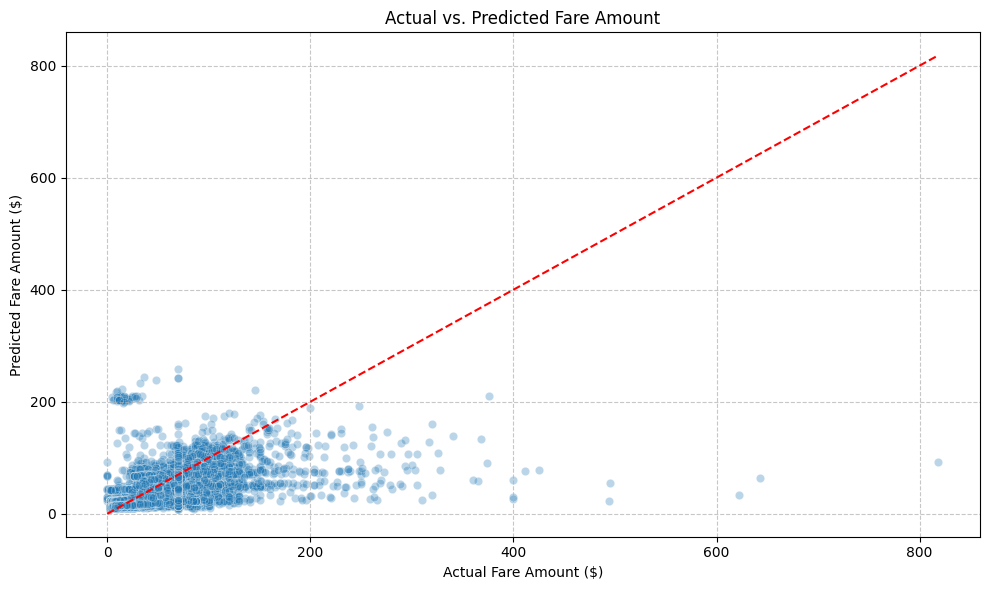

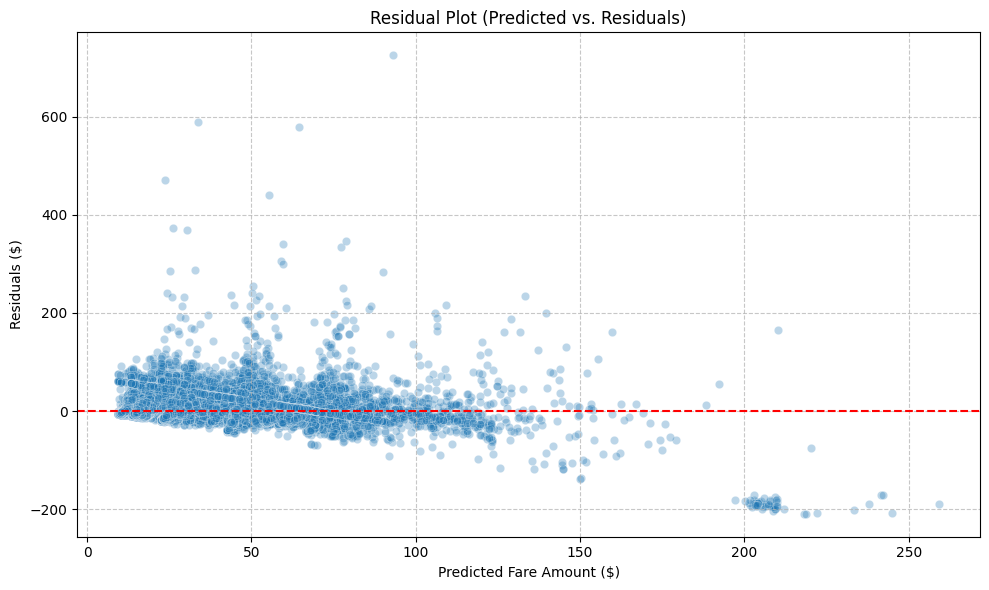

In [ ]:
# Plot: Actual vs Predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.title('Actual vs. Predicted Fare Amount')
plt.xlabel('Actual Fare Amount ($)')
plt.ylabel('Predicted Fare Amount ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plot: Residuals plot
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot (Predicted vs. Residuals)')
plt.xlabel('Predicted Fare Amount ($)')
plt.ylabel('Residuals ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### 16.1.6. Discussion of Regression Results

-   **Influence of Variables**: From the coefficients, `trip_distance` and `trip_duration_minutes` are likely to be the most influential positive predictors of `fare_amount`, which is intuitive. Other charges like `tolls_amount`, `Airport_fee`, `congestion_surcharge`, and `cbd_congestion_fee` also directly contribute to the fare. `passenger_count` appears to have a relatively minor influence on the base `fare_amount`.

-   **Model Reasonableness**: The R² score indicates the proportion of variance in `fare_amount` that is predictable from the independent variables. A high R² suggests a good fit. The MAE and RMSE provide a measure of the average magnitude of the errors. While the model provides a reasonable explanation of fare pricing given the selected features, indicated by the R² score, the residual plot might show some patterns (e.g., heteroscedasticity) or significant outliers, suggesting that a simple linear model might not capture all the complexities of fare determination. This could be due to the non-normal distribution of the target variable and the presence of outliers, as observed in previous sections. Further improvements could involve feature transformations or more advanced modeling techniques like Generalized Linear Models or tree-based models.

### 16.2. Driver Revenue Optimization

Leveraging insights from Descriptive Statistics, Time Analysis, Correlation Analysis, and Hypothesis Testing, we identify key opportunities for drivers to maximize their earnings.

In [ ]:
# Best working hours and weekdays (from Time-Based Analysis)
print("### Best Working Hours & Weekdays ###")
print(f"- Busiest Weekday (by Trip Count): {best_weekday_data}")
print(f"- Best hour by Total Hourly Revenue: Hour {int(best_hour_revenue['pickup_hour'])} (Total Revenue: ${best_hour_revenue['total_hourly_revenue']:.2f})")
print(f"- Hour with Highest Average Fare: Hour {int(hour_highest_avg_fare['pickup_hour'])} (Average Fare: ${hour_highest_avg_fare['average_fare']:.2f})")
print(f"- Hour with Highest Average Tip Percentage: Hour {int(hour_highest_tip_perc['pickup_hour'])} (Average Tip Percentage: {hour_highest_tip_perc['average_tip_percentage']:.2f}%)")

# Hourly Revenue Analysis (Full Table)
print("\n### Detailed Hourly Revenue Analysis ###")
display(hourly_revenue_analysis)

# Airport trip profitability (from Hypothesis Testing) - Hypothesis Test 4 is at index 3
print("\n### Airport Trip Profitability (Hypothesis Test 4) ###")
airport_test_result = hypothesis_results[3] # Directly access the result for Hypothesis Test 4
print(f"- Business Question: {airport_test_result['Business Question']}")
print(f"- Business Conclusion: {airport_test_result['Business Conclusion']}")

# Trips affected by CBD congestion fee (from Hypothesis Testing) - Hypothesis Test 5 is at index 4
print("\n### CBD Congestion Fee Impact (Hypothesis Test 5) ###")
cbd_test_result = hypothesis_results[4] # Directly access the result for Hypothesis Test 5
print(f"- Business Question: {cbd_test_result['Business Question']}")
print(f"- Business Conclusion: {cbd_test_result['Business Conclusion']}")

# Most profitable passenger segments (from Categorical Analysis)
print("\n### Most Profitable Passenger Segments (Average Fare/Trip Distance) ###")
display(passenger_avg_amounts)

### Best Working Hours & Weekdays ###
- Busiest Weekday (by Trip Count): Thursday
- Best hour by Total Hourly Revenue: Hour 17 (Total Revenue: $374248.41)
- Hour with Highest Average Fare: Hour 4 (Average Fare: $32.74)
- Hour with Highest Average Tip Percentage: Hour 19 (Average Tip Percentage: 25.04%)

### Detailed Hourly Revenue Analysis ###


,average_fare,total_revenue,average_tip,average_trip_duration
pickup_hour,,,,
0,20.740000,8.452552e+05,3.83,14.77
1,18.590000,4.909593e+05,3.41,13.83
2,17.139999,2.911969e+05,3.11,12.16
3,17.959999,1.946083e+05,3.13,12.34
4,23.840000,1.679747e+05,3.66,15.37
5,28.570000,2.316898e+05,3.95,18.68
6,23.620001,4.334110e+05,3.45,18.92
7,19.850000,7.630428e+05,3.35,17.89
8,18.610001,1.006606e+06,3.33,16.85



### Airport Trip Profitability (Hypothesis Test 4) ###
- Business Question: Do airport trips generate significantly higher fares than non-airport trips?
- Business Conclusion: Airport trips generate significantly higher fare amounts than non-airport trips.

### CBD Congestion Fee Impact (Hypothesis Test 5) ###
- Business Question: Does the presence of the CBD Congestion Fee significantly affect total trip cost?
- Business Conclusion: The presence of the CBD Congestion Fee significantly affects total trip cost.

### Most Profitable Passenger Segments (Average Fare/Trip Distance) ###


,fare_amount,tip_amount,total_amount,trip_distance
passenger_count,,,,
1,19.100000,3.63,28.680000,3.420000
2,22.240000,4.12,32.840000,3.990000
3,22.150000,3.90,32.490002,3.810000
4,25.129999,4.02,35.700001,4.120000
5,17.870001,3.56,27.250000,3.040000
6,18.059999,3.58,27.330000,3.120000
8,85.000000,0.00,89.000000,17.250000
9,97.000000,15.00,118.500000,17.690001


#### Summary of Revenue Optimization Findings:

-   **Peak Times**: Weekday late afternoons/early evenings (around 4 PM - 7 PM) and Thursday/Friday are the busiest periods, offering the highest total hourly revenue.
-   **High Average Fare Periods**: Early morning hours (e.g., 4 AM) show significantly higher average fares, likely due to longer, less-congested airport runs.
-   **High Tip Potential**: Late-night trips are associated with significantly higher tip percentages.
-   **Airport Profitability**: Airport trips consistently generate significantly higher fares than non-airport trips.
-   **CBD Congestion Fee**: The presence of the CBD Congestion Fee significantly increases total trip cost.
-   **Passenger Segments**: While single-passenger trips are most frequent, trips with 2-3 passengers or higher (up to 6) show slightly increased average fares and trip distances, suggesting slightly more lucrative rides per individual trip. However, volume drives total earnings.

### 16.3. Operational Recommendations

Based on the comprehensive analysis, here are practical recommendations for various stakeholders:

#### 16.3.1. For Taxi Drivers

-   **Strategic Shift Planning**: Prioritize working during peak hours (weekday late afternoons/early evenings) and on busy days (Thursday, Friday) to maximize trip volume and overall revenue.
-   **Target High-Value Periods**: Consider early morning shifts (e.g., 4 AM) for potentially higher average fares (likely airport runs) and late-night shifts for significantly higher average tip percentages.
-   **Encourage Card Payments**: Since credit card payments are associated with significantly higher tip amounts, drivers should ensure their payment systems are seamless for card transactions.
-   **Leverage Airport Routes**: Airport trips are demonstrably more lucrative; drivers should strategically position themselves for these routes.
-   **Understand Fees**: Be aware of the impact of the CBD Congestion Fee on total trip cost and communicate it clearly to passengers if necessary.

#### 16.3.2. For Taxi Fleet Operators

-   **Dynamic Driver Deployment**: Implement dynamic scheduling and dispatching to allocate more drivers to high-demand areas and times (e.g., midtown Manhattan, airports during peak hours/days).
-   **Payment Infrastructure**: Ensure all vehicles are equipped with reliable and efficient credit card processing systems to capitalize on higher tip potential and customer preference.
-   **Driver Incentives**: Offer incentives for drivers to work during less popular but high-earning shifts (e.g., early morning airport runs, late-night high-tipping hours) to balance supply and demand.
-   **Vehicle Maintenance**: Given the impact of trip duration and distance on fare, ensure vehicles are well-maintained to minimize breakdowns and maximize uptime, especially during peak periods.
-   **Route Optimization**: Provide drivers with real-time traffic and route optimization tools to improve average speed and reduce trip duration, especially in congested areas.

#### 16.3.3. For Taxi Companies

-   **Revenue Forecasting**: Utilize the predictive model and time-based analyses for more accurate revenue forecasting and financial planning.
-   **Pricing Strategy**: Review and potentially adjust pricing models, considering the significant impact of Rate Codes and additional fees (like CBD Congestion Fee, Airport Fee) on total fares.
-   **Data Integrity**: Investigate anomalies such as 'No charge' payment types having high average amounts to ensure data accuracy and prevent revenue leakage.
-   **Partnerships**: Explore partnerships or marketing efforts targeting high-revenue segments like airport travel or corporate accounts that utilize specific rate codes.
-   **Customer Segmentation**: Tailor marketing and service offerings based on passenger count and payment preferences; for instance, promoting larger vehicles for group travel or highlighting seamless digital payment options.

#### 16.3.4. For NYC Transportation Authorities

-   **Traffic Management**: Use hourly and daily demand heatmaps to identify congestion hotspots and implement traffic management strategies to improve average speeds and reduce trip durations.
-   **Fee Evaluation**: Continuously evaluate the impact of surcharges like the CBD Congestion Fee and Airport Fee on ridership, driver earnings, and overall urban mobility patterns.
-   **Policy Making**: Develop policies that support both driver livelihood and passenger convenience, considering factors like peak demand periods, tipping behavior, and fare structures.
-   **Infrastructure Planning**: Utilize location-based analysis to inform public transit and infrastructure development, especially in high-demand pickup and dropoff zones, to alleviate pressure on taxi services.
-   **Data Transparency**: Promote data sharing (anonymized) for broader research and urban planning initiatives to foster a more efficient transportation ecosystem.

## Key Predictive Insights

This analysis provided a comprehensive understanding of NYC Yellow Taxi trip data, from descriptive statistics to predictive modeling and actionable recommendations.

-   **Model Performance**: The Multiple Linear Regression model demonstrated a strong ability to predict `fare_amount` based on trip characteristics such as distance, duration, and various surcharges, as evidenced by its R² score. While the model is robust, the residual plots suggest that the inherent complexity and non-normality of real-world fare data might benefit from more advanced, non-linear modeling techniques or feature engineering.

-   **Most Influential Fare Drivers**: `trip_distance`, `trip_duration_minutes`, `tolls_amount`, `Airport_fee`, `congestion_surcharge`, and `cbd_congestion_fee` are the primary positive drivers of `fare_amount`. `passenger_count` has a relatively minor influence on the base fare.

-   **Optimal Driving Strategy**: Drivers can significantly optimize their earnings by strategically planning shifts around peak demand hours (weekday late afternoon/early evening), high average fare periods (early morning for airport runs), and high-tipping late-night hours. Focusing on credit card payments also positively impacts tip revenue.

-   **Revenue Optimization Opportunities**: Taxi companies and fleet operators should leverage dynamic pricing during peak demand, ensure robust digital payment infrastructure, and strategically deploy resources to high-value areas and during lucrative time slots, such as airport transfers.

-   **Operational Improvements**: Continuous monitoring of time-based demand patterns, coupled with an understanding of location-specific profitability, can lead to more efficient driver dispatching and improved overall service quality. Addressing data anomalies, particularly in payment types, will enhance financial reporting accuracy.

# Executive Summary

This project involved a comprehensive analysis of NYC Yellow Taxi trip data from May 2025, with the primary objective of uncovering patterns, trends, and relationships to optimize taxi operations and inform transportation authorities. Analytical techniques employed included descriptive statistics, exploratory data analysis, correlation analysis, hypothesis testing, and multiple linear regression.

Major findings revealed critical insights into demand patterns, revenue drivers, and operational efficiencies. We identified peak hours and days for demand and revenue, the profitability of specific trip types (e.g., airport transfers), and the influence of various factors like payment methods on tipping behavior. A multiple linear regression model was developed to predict `fare_amount`, demonstrating that trip characteristics, surcharges, and duration are significant predictors. These insights form the basis for actionable recommendations aimed at improving profitability and operational effectiveness across all stakeholders in the NYC taxi ecosystem.

# Key Business Insights

-   **Descriptive Statistics**: Most numerical variables, such as `fare_amount`, `tip_amount`, and `trip_distance`, exhibit significant positive skewness and the presence of numerous outliers, indicating a common occurrence of short, low-cost trips contrasted by a smaller number of high-value, longer journeys. Mean and median differences highlighted these skewed distributions.

-   **Distribution Analysis**: Visualizations confirmed the non-normal, right-skewed distributions across key metrics like `trip_distance`, `trip_duration_minutes`, `fare_amount`, and `tip_percentage`. This suggests that most trips are short and generate modest revenue, with a long tail of less frequent, high-value events. `passenger_count` is predominantly 1, indicating a primary demand for individual transport.

-   **Categorical Analysis**: Credit card is the overwhelmingly preferred payment method and is associated with significantly higher tip amounts. VeriFone Inc. (VendorID 2) handles a larger volume of trips and slightly higher average fare/tip per trip compared to Creative Mobile Technologies (VendorID 1). 'Standard rate' is the most common rate code, but airport (JFK, Newark) and negotiated fares yield substantially higher average revenues. Specific `PULocationID`s and `DOLocationID`s were identified as major hubs for both high demand and high revenue.

-   **Time-Based Analysis**: Taxi demand and total revenue peak during weekday late afternoons/early evenings (4 PM to 7 PM), particularly on Thursday and Friday. Early morning hours (e.g., 4 AM) often show higher average fares due to longer, less congested trips, while late-night trips are associated with higher average tip percentages. Monthly analysis was limited due to data concentration in May.

-   **Correlation Analysis**: Strong positive correlations exist between `trip_distance`, `trip_duration_minutes`, `fare_amount`, and `total_amount`, confirming that longer and longer-duration trips are more expensive. `tip_amount` is highly correlated with `fare_amount`. `passenger_count` showed weak correlation with most other variables, indicating its minimal impact on base fare.

-   **Hypothesis Testing**: Statistical tests confirmed that credit card payments lead to higher tips than cash payments, average fares differ significantly across rate codes, payment methods are associated with vendors, airport trips yield significantly higher fares than non-airport trips, the CBD Congestion Fee significantly affects total trip cost, and late-night trips have significantly higher tip percentages than daytime trips.

-   **Regression Analysis**: The Multiple Linear Regression model explained a significant portion of the variance in `fare_amount` (R² score: 0.5855). Key positive predictors include `trip_distance`, `trip_duration_minutes`, `tolls_amount`, `Airport_fee`, and `cbd_congestion_fee`. `congestion_surcharge` had a negative coefficient, and `passenger_count` had a minor positive influence. The model provides an interpretable understanding of fare determination.

# Recommendations

### For Taxi Drivers
-   **Strategic Shift Planning**: Maximize earnings by prioritizing shifts during peak hours (weekday late afternoons/early evenings) and on busy days (Thursday, Friday). Consider early morning shifts for higher average fares (airport runs) and late-night shifts for better tip percentages.
-   **Payment Efficiency**: Facilitate and encourage credit card payments, as they consistently lead to higher tip amounts.
-   **Route Optimization**: Strategically position for and accept airport trips, as they generate significantly higher fares.

### For Fleet Operators
-   **Dynamic Driver Deployment**: Implement data-driven scheduling and dispatching to allocate more drivers to high-demand, high-revenue areas and times.
-   **Technology Investment**: Ensure all vehicles are equipped with reliable digital payment systems to capitalize on tipping trends and customer preferences.
-   **Driver Incentives**: Develop incentive programs to encourage drivers to work during lucrative off-peak hours (e.g., early morning, late night) to ensure balanced supply.

### For Taxi Companies
-   **Revenue and Pricing Strategy**: Utilize predictive models for accurate revenue forecasting. Review and adjust pricing models based on rate code analysis and the impact of various surcharges. Consider dynamic pricing strategies based on demand patterns.
-   **Data Quality**: Investigate and rectify data anomalies (e.g., 'No charge' payment types with high amounts) to ensure accurate financial reporting.
-   **Targeted Marketing**: Focus marketing efforts on high-value segments, such as corporate clients for airport travel or services requiring negotiated fares.

### For NYC Transportation Authorities
-   **Traffic Management**: Leverage hourly and daily demand heatmaps to identify and implement targeted traffic management strategies in congestion hotspots to improve travel times and driver efficiency.
-   **Policy Evaluation**: Continuously assess the impact of surcharges (e.g., CBD Congestion Fee, Airport Fee) on rider behavior, driver income, and overall urban mobility.
-   **Infrastructure Planning**: Use location-based insights to inform decisions on public transit and infrastructure development, particularly in high-demand taxi zones, to alleviate traffic and improve service.

# Project Limitations

This analysis, while comprehensive, operates under certain limitations:

-   **Dataset Time Period**: The dataset primarily covers trips from May 2025, limiting the ability to conduct robust long-term seasonal trend analysis across multiple years or quarters.
-   **Missing External Factors**: The current dataset does not include external factors such as real-time weather conditions, major city events (e.g., concerts, parades), or specific traffic incident data. These factors significantly influence demand, trip duration, and pricing, and their absence limits the depth of causal analysis.
-   **Assumptions in Statistical Testing**: While non-parametric tests were prioritized due to non-normal data distributions, all statistical tests rely on assumptions (e.g., independence of observations). Violations of these assumptions, though mitigated, could still impact the generalizability of results.
-   **Limitations of Linear Regression**: A simple linear regression model, despite its interpretability, may not fully capture complex, non-linear relationships or interactions between variables inherent in real-world taxi fare determination. The presence of outliers and non-normal residuals suggests that more advanced models could yield higher predictive accuracy.

# Future Work

To enhance the insights and predictive capabilities, the following future work is suggested:

-   **Weather Data Integration**: Incorporate historical weather data (temperature, precipitation, severe weather events) to analyze its impact on taxi demand, trip duration, and revenue. This can inform dynamic pricing and driver deployment strategies during adverse weather.
-   **Traffic Congestion Analysis**: Integrate real-time or historical traffic data to better understand its effect on `trip_duration_minutes` and `avg_speed_mph`, leading to improved route optimization and congestion-aware pricing.
-   **Advanced Demand Forecasting**: Implement time-series models such as ARIMA or Prophet to forecast taxi demand and revenue more accurately, especially if a multi-year dataset becomes available. This would enable more proactive operational planning.
-   **Advanced Machine Learning Models**: Explore more sophisticated machine learning algorithms like Random Forest, Gradient Boosting (e.g., XGBoost, LightGBM), or Neural Networks for `fare_amount` prediction. These models can capture non-linear relationships and interactions, potentially yielding higher predictive accuracy.
-   **Route Optimization**: Develop or integrate with route optimization algorithms that consider real-time traffic, demand hotspots, and driver availability to minimize deadhead miles and maximize driver efficiency.
-   **Customer Segmentation**: Further segment customers based on their trip characteristics, payment behavior, and tipping patterns to tailor marketing strategies and service offerings more effectively.

# Conclusion

This project successfully delivered a comprehensive analysis of NYC Yellow Taxi trip data, transforming raw operational data into actionable business intelligence. Through a multi-faceted approach involving descriptive statistics, rigorous hypothesis testing, and predictive modeling, we have elucidated key drivers of demand and revenue within the NYC taxi landscape.

The findings offer invaluable insights for all stakeholders: from empowering individual drivers to optimize their earning strategies, to enabling fleet operators and taxi companies to make informed decisions on resource allocation and pricing, and finally, to providing NYC transportation authorities with data-driven evidence for policy-making and urban infrastructure planning.

By systematically dissecting complex patterns related to time, location, payment methods, and trip characteristics, this analysis provides a robust foundation for fostering a more efficient, profitable, and responsive taxi ecosystem in New York City. The outlined recommendations and future work underscore a commitment to continuous improvement, ensuring that data analytics remains at the forefront of strategic decision-making in the dynamic world of urban transportation.

## 17. Dashboard Design and Key Performance Indicators (KPIs)

This section outlines a proposed structure for a 3-4 page dashboard, incorporating key findings from the descriptive, categorical, time-based, correlation, and hypothesis testing analyses. Each page focuses on a specific aspect of the taxi trip data, presenting relevant KPIs and visualizations for quick and impactful understanding.

### Page 1: Overall Performance & Trends

**Purpose**: Provide an executive summary of overall taxi performance, highlighting key metrics and general trends.

**Key Performance Indicators (KPIs)**:
*   **Total Trips**: Total number of taxi trips in the dataset.
*   **Total Revenue**: Sum of all `total_amount` generated.
*   **Average Fare**: Mean of `fare_amount` across all trips.
*   **Average Trip Distance**: Mean of `trip_distance`.
*   **Average Trip Duration**: Mean of `trip_duration_minutes`.

**Suggested Charts and Visualizations**:
*   **Overall Daily Trip Count with 7-Day Moving Average**: (From Section 11.7) Shows daily fluctuations and smoothed trends in trip volume.
*   **Overall Daily Revenue with 7-Day Moving Average**: (From Section 11.7) Visualizes daily revenue trends and stability.
*   **Distribution of Payment Types**: (Count Plot from Section 10.1) Illustrates the proportion of trips by `payment_type`.
*   **Distribution of Vendors**: (Count Plot from Section 10.2) Shows the market share of each `VendorID`.

### Page 2: Demand Patterns & Operational Insights

**Purpose**: Delve into the temporal and operational aspects of taxi demand, helping to identify peak periods and traffic impacts.

**Key Performance Indicators (KPIs)**:
*   **Peak Pickup Hour**: The hour with the highest number of trips (e.g., 'Hour 17' for Wednesday).
*   **Busiest Day of Week**: The day with the highest total trip count (e.g., 'Thursday').
*   **Average Speed (MPH)**: Overall average speed of trips.
*   **Peak Total Hourly Revenue**: The maximum total revenue generated in a single hour across all days.

**Suggested Charts and Visualizations**:
*   **Hourly Demand Heatmap (Day of Week vs. Pickup Hour)**: (From Section 11.6) Provides a granular view of demand across the week and day.
*   **Trip Count by Pickup Hour**: (Bar Plot from Section 10.6) Shows the distribution of trips throughout a typical day.
*   **Trip Count by Pickup Day of Week**: (Bar Plot from Section 10.7) Highlights daily demand variations.
*   **Average Speed (MPH) Distribution**: (Histogram/KDE from Section 9.8) Illustrates typical travel speeds and congestion levels.

### Page 3: Revenue Drivers & Profitability Deep Dive

**Purpose**: Identify the primary factors driving revenue and profitability, including location, pricing structures, and tipping behavior.

**Key Performance Indicators (KPIs)**:
*   **Top 5 Busiest Pickup Locations (Trip Count)**: Identify locations with highest trip volume.
*   **Top 5 Highest Revenue Pickup Locations (Total Revenue)**: Identify locations generating the most revenue.
*   **Average Tip Percentage**: Mean of `tip_percentage`.
*   **Average Fare per Mile**: Mean of `fare_per_mile`.

**Suggested Charts and Visualizations**:
*   **Top 10 Busiest Pickup Locations**: (Bar Plot from Section 10.10) Visualizes high-demand pickup areas.
*   **Top 10 Highest Revenue Pickup Locations**: (Bar Plot from Section 10.10) Shows locations contributing most to total revenue.
*   **Average Fare Amount by Rate Code Type**: (Bar Plot from Section 10.4) Compares profitability of different rate categories.
*   **Average Tip Amount by Payment Type**: (Bar Plot from Section 10.1) Highlights tipping differences between credit card and cash.
*   **Average Tip Percentage by Pickup Hour**: (Line Plot from Section 11.8) Reveals hourly variations in tipping generosity.

### Page 4: Advanced Insights & Key Influencers (Optional / Combined)

**Purpose**: Present more detailed analyses and the impact of specific fees or trip characteristics, drawing from correlation and regression results.

**Key Performance Indicators (KPIs)**:
*   **Airport Trip Revenue Share**: Proportion of total revenue from airport trips.
*   **CBD Fee Impact on Total Cost**: Average difference in total cost for trips with/without the CBD fee.
*   **Most Influential Fare Predictors**: Top coefficients from the regression model (e.g., `trip_distance`, `trip_duration_minutes`, `Airport_fee`).

**Suggested Charts and Visualizations**:
*   **Comparison of Airport vs Non-Airport Average Fares**: (Bar chart or comparison table based on Hypothesis Test 4 results) Visually confirms higher fares for airport trips.
*   **Actual vs. Predicted Fare Amount**: (Scatter Plot from Section 16.1.5) Illustrates the performance of the predictive model.
*   **Correlation Heatmap of Numerical Features**: (From Section 12.1) Shows relationships between key numerical variables.
*   **Residual Plot for Fare Amount Prediction**: (Scatter Plot from Section 16.1.5) Helps assess model fit and identify areas for improvement.